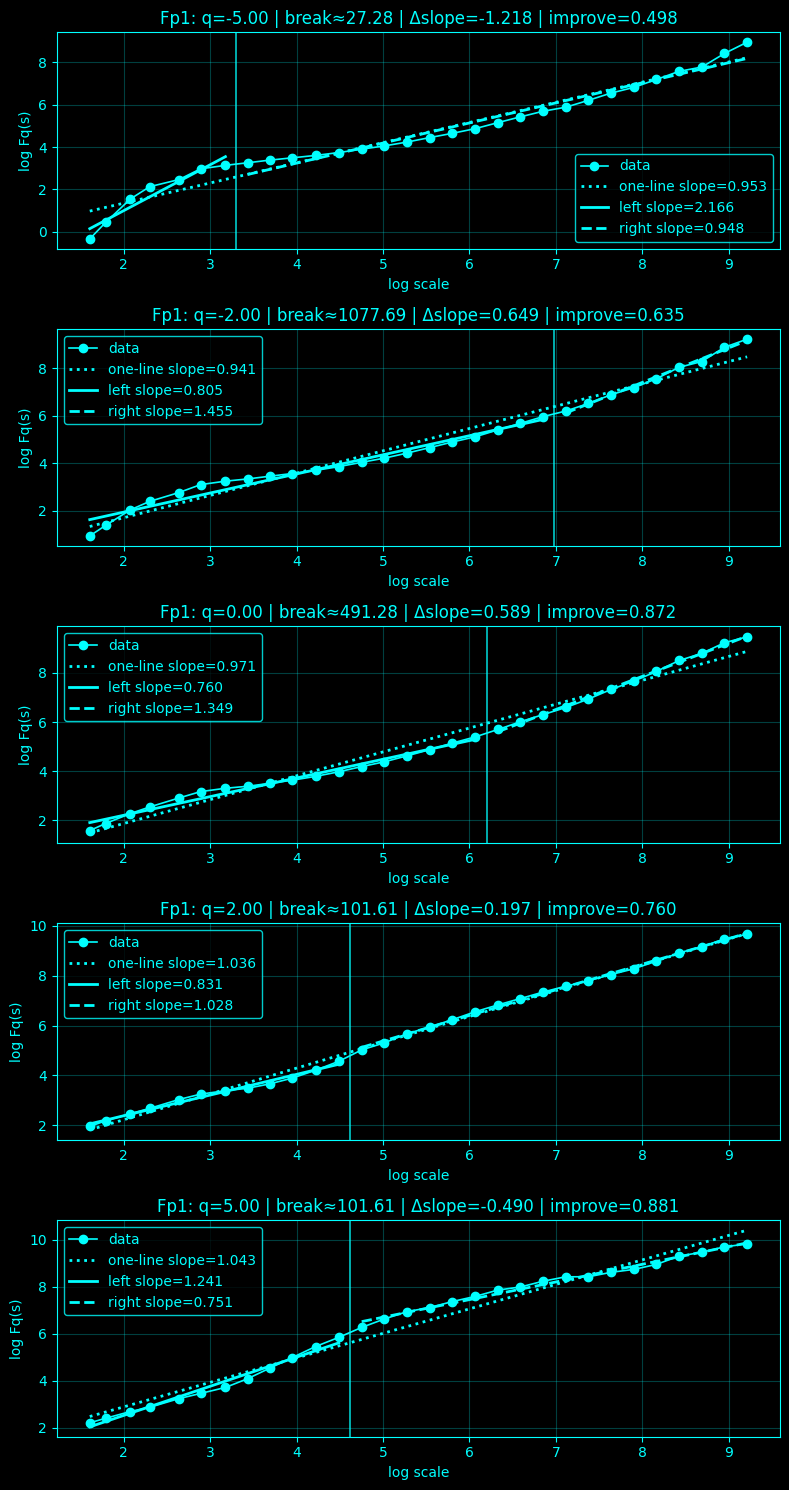

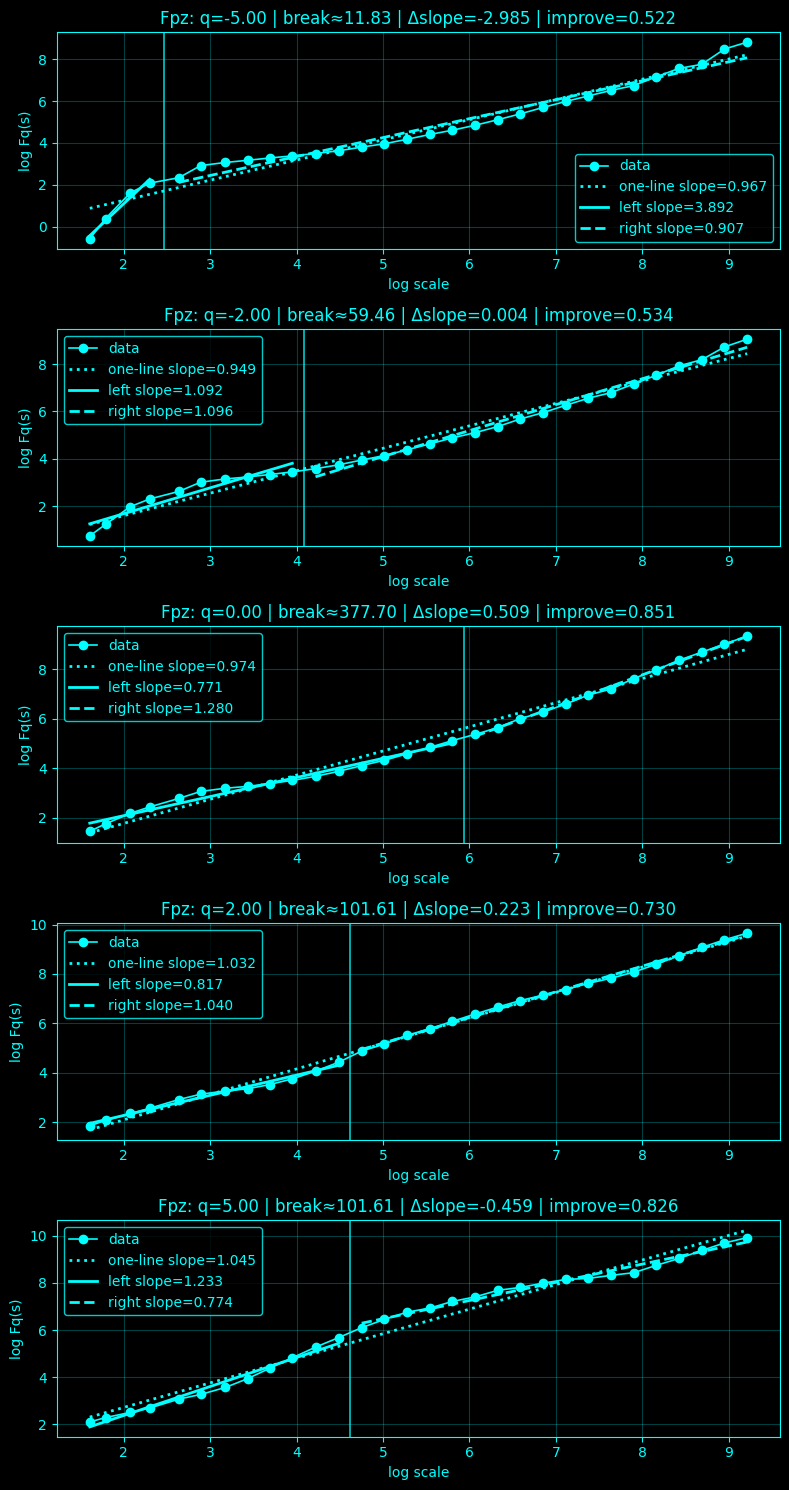

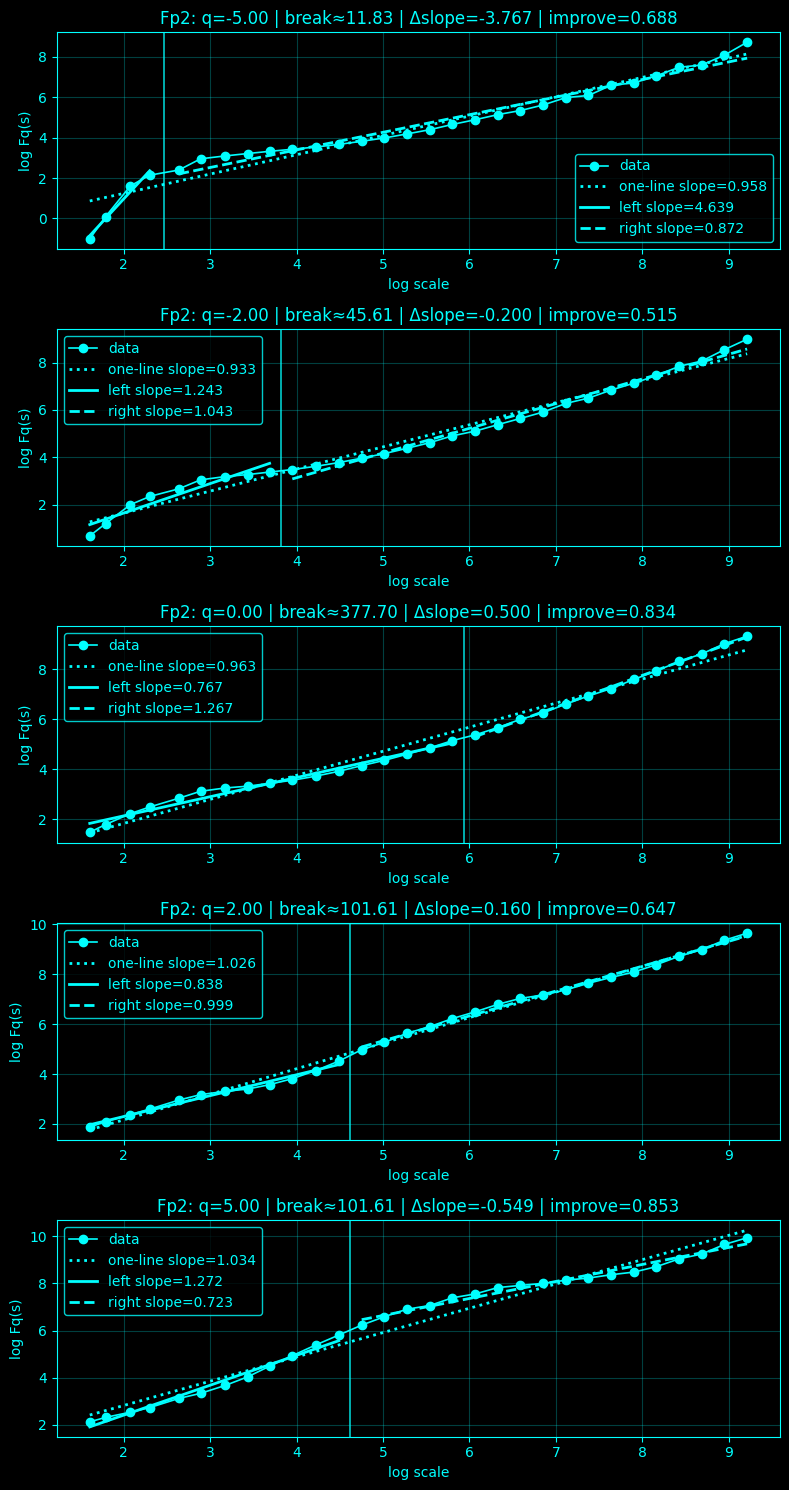

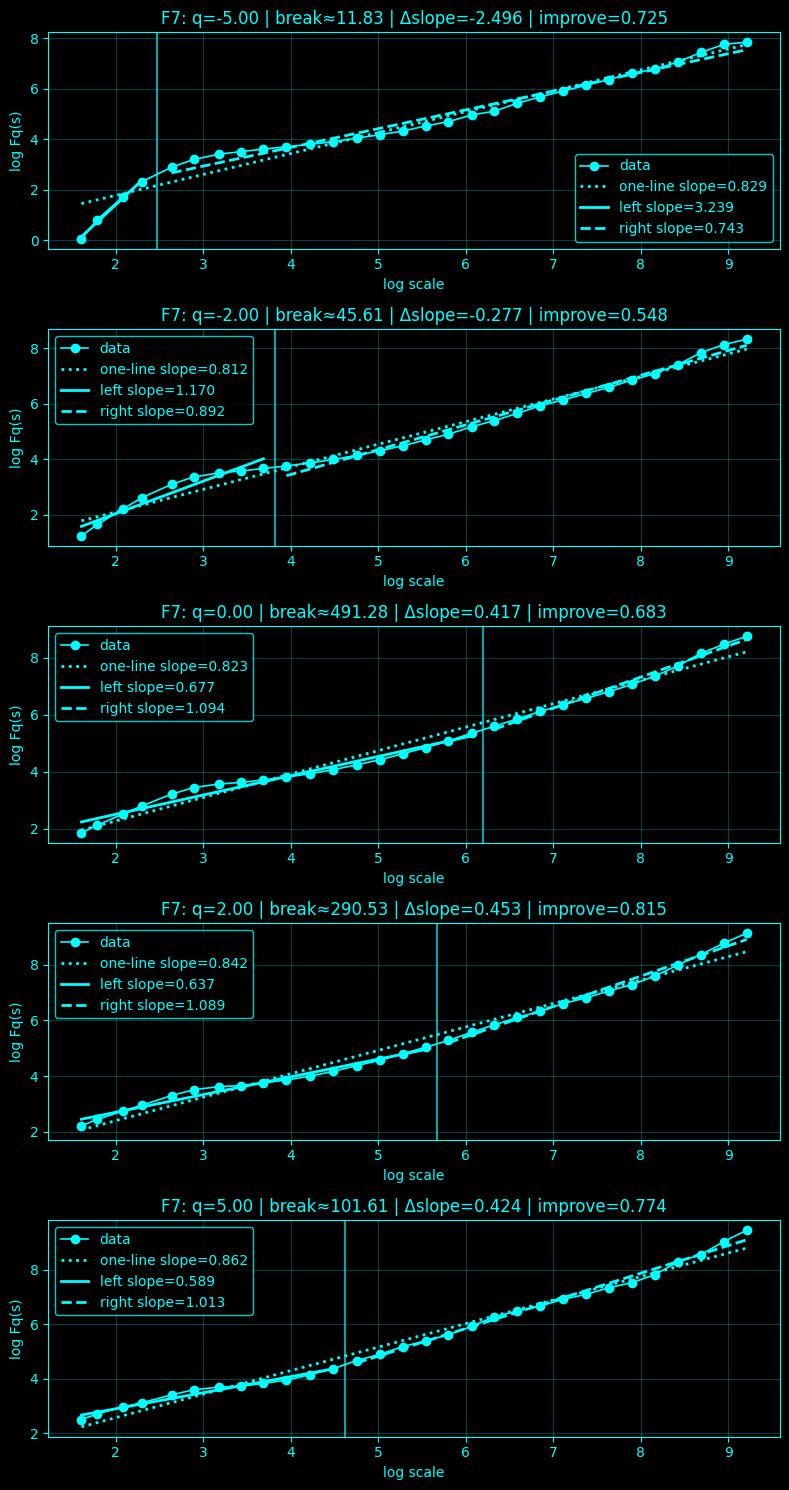

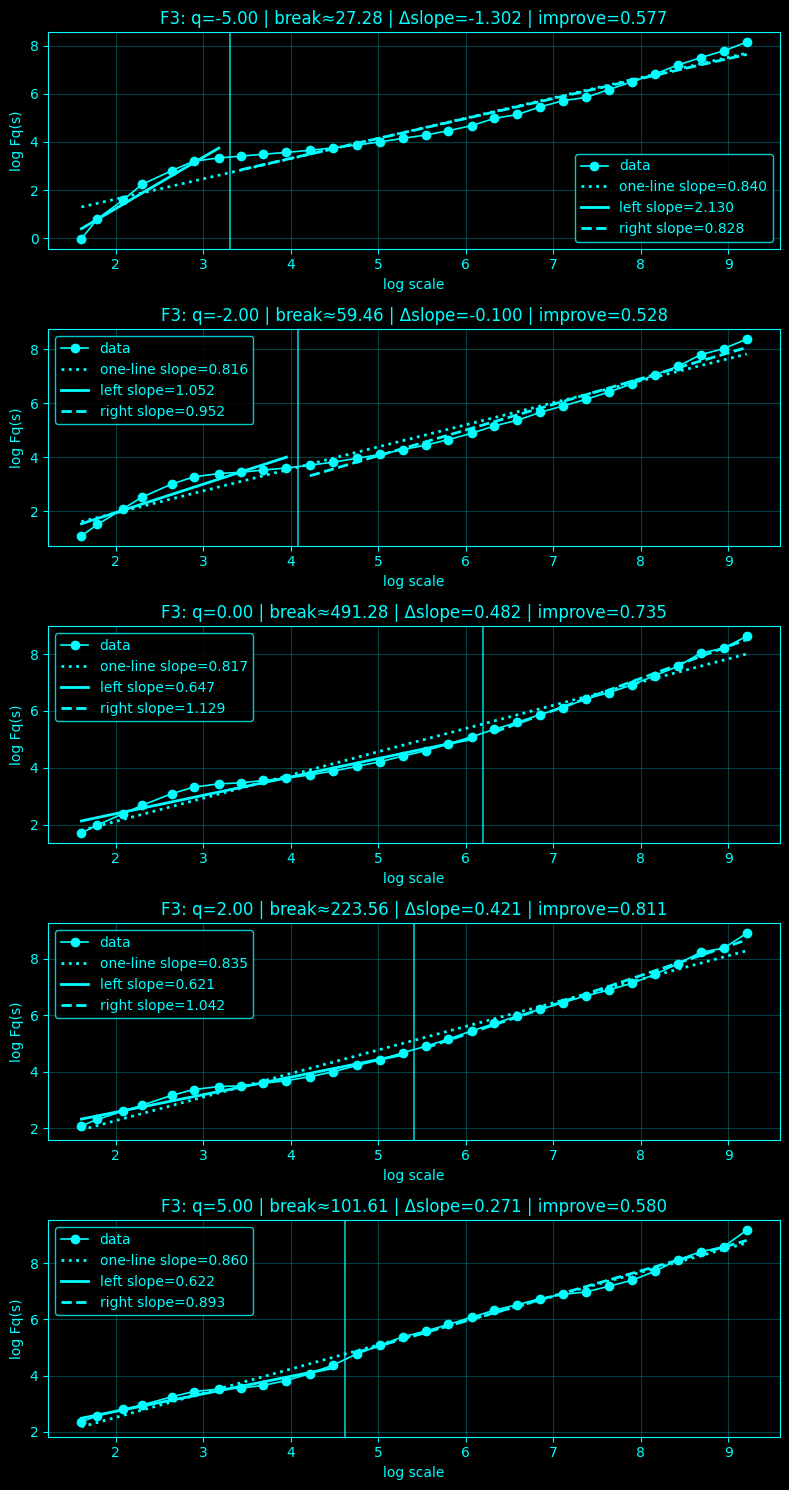

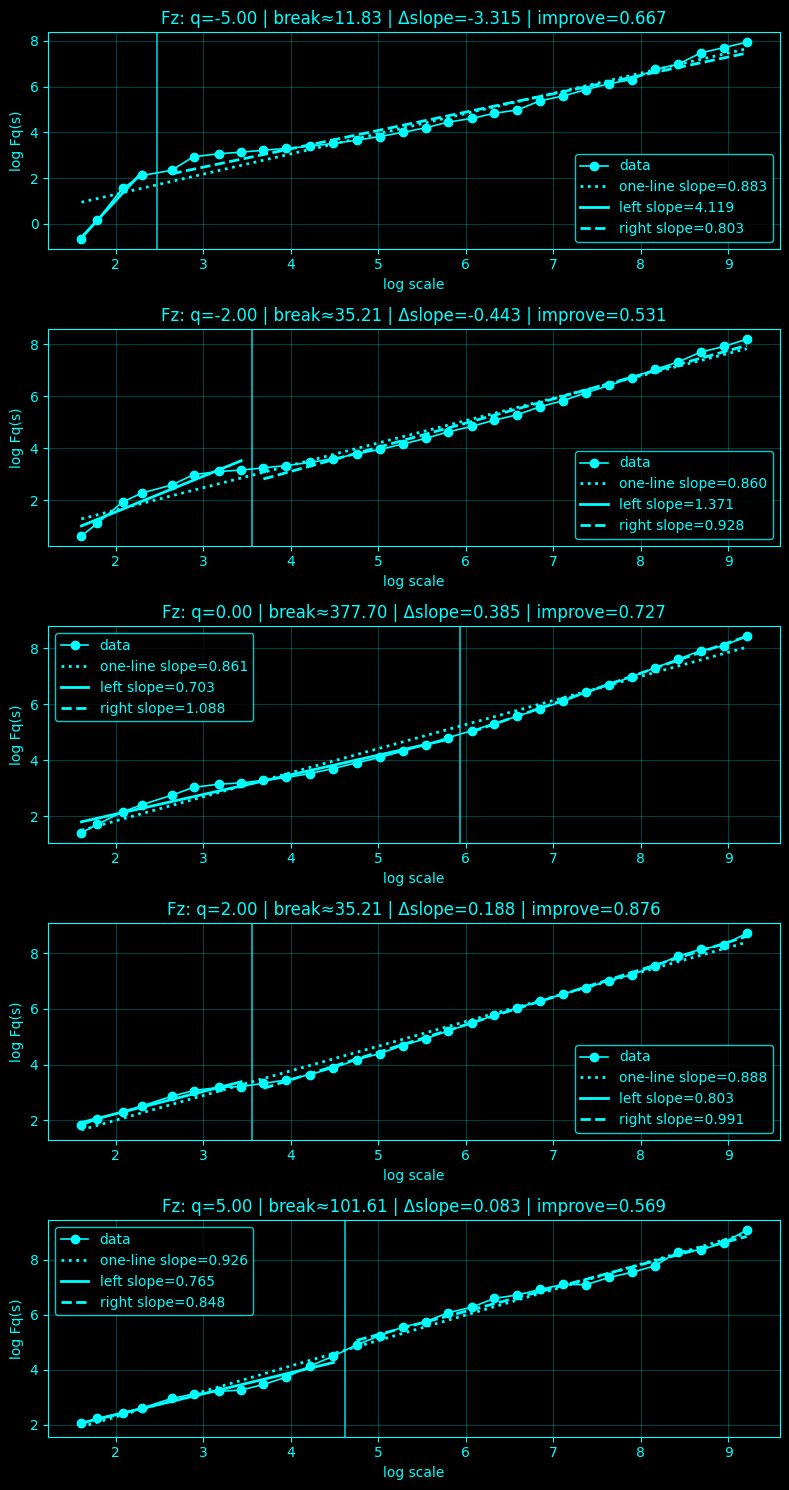

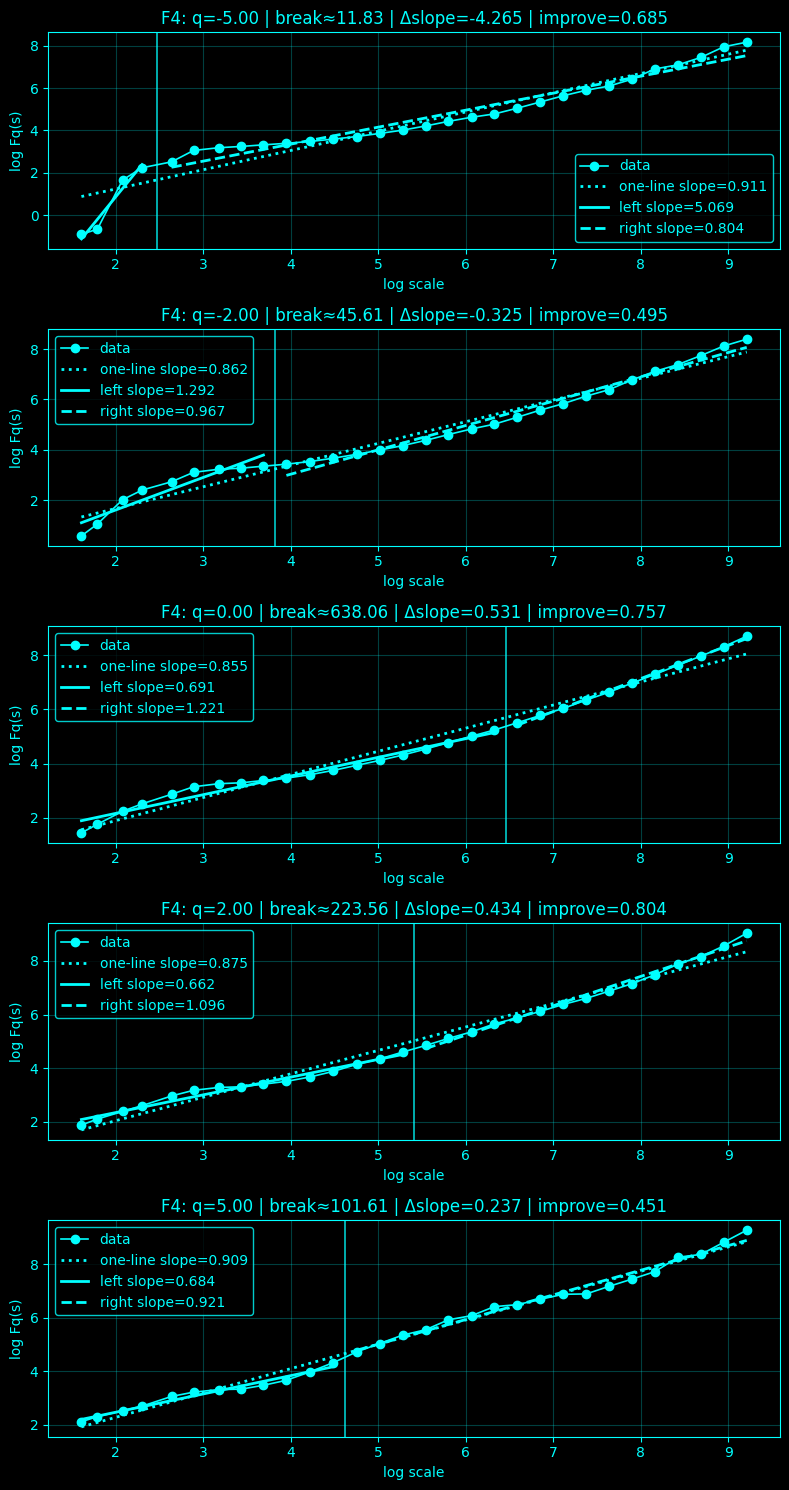

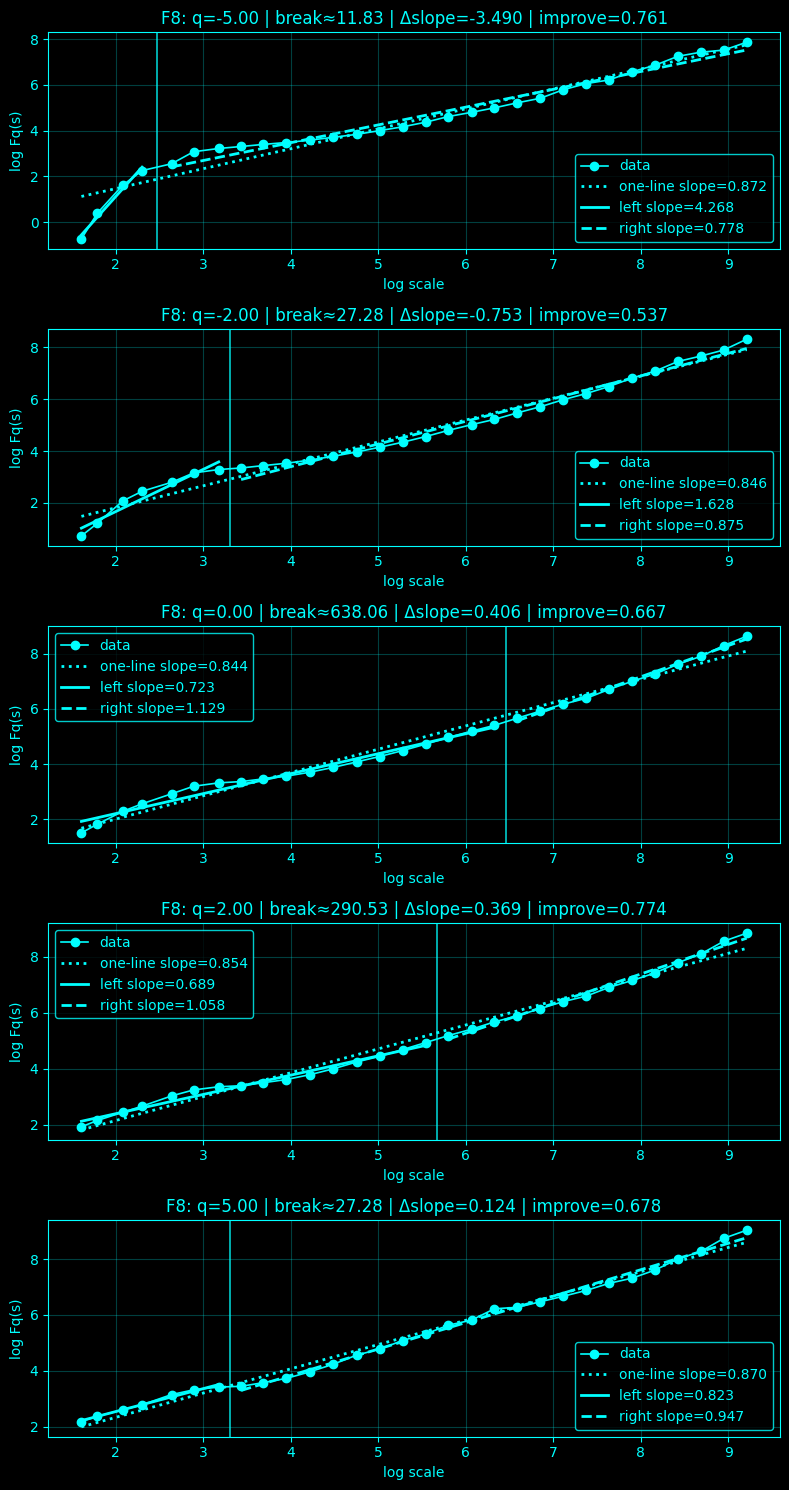

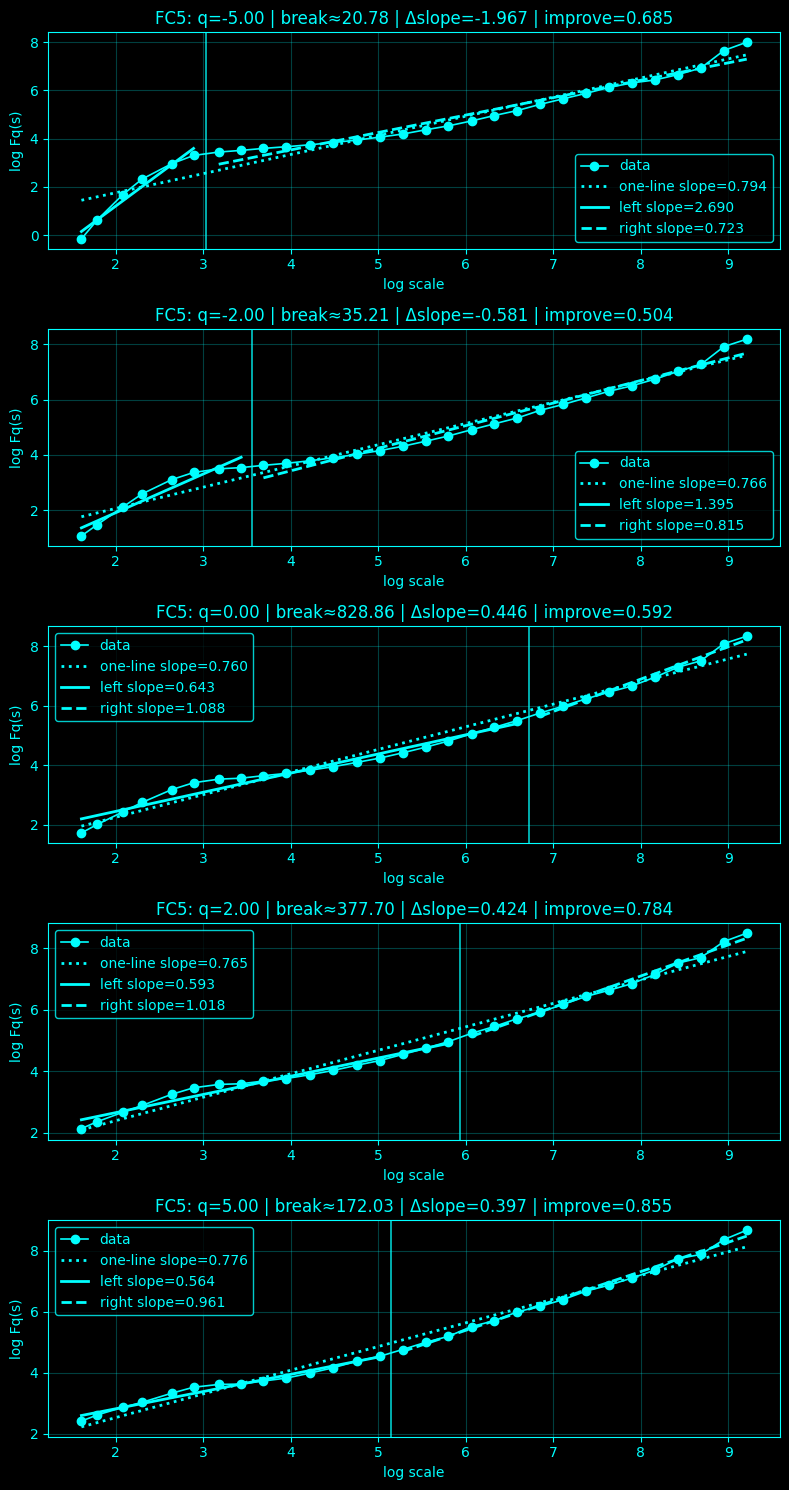

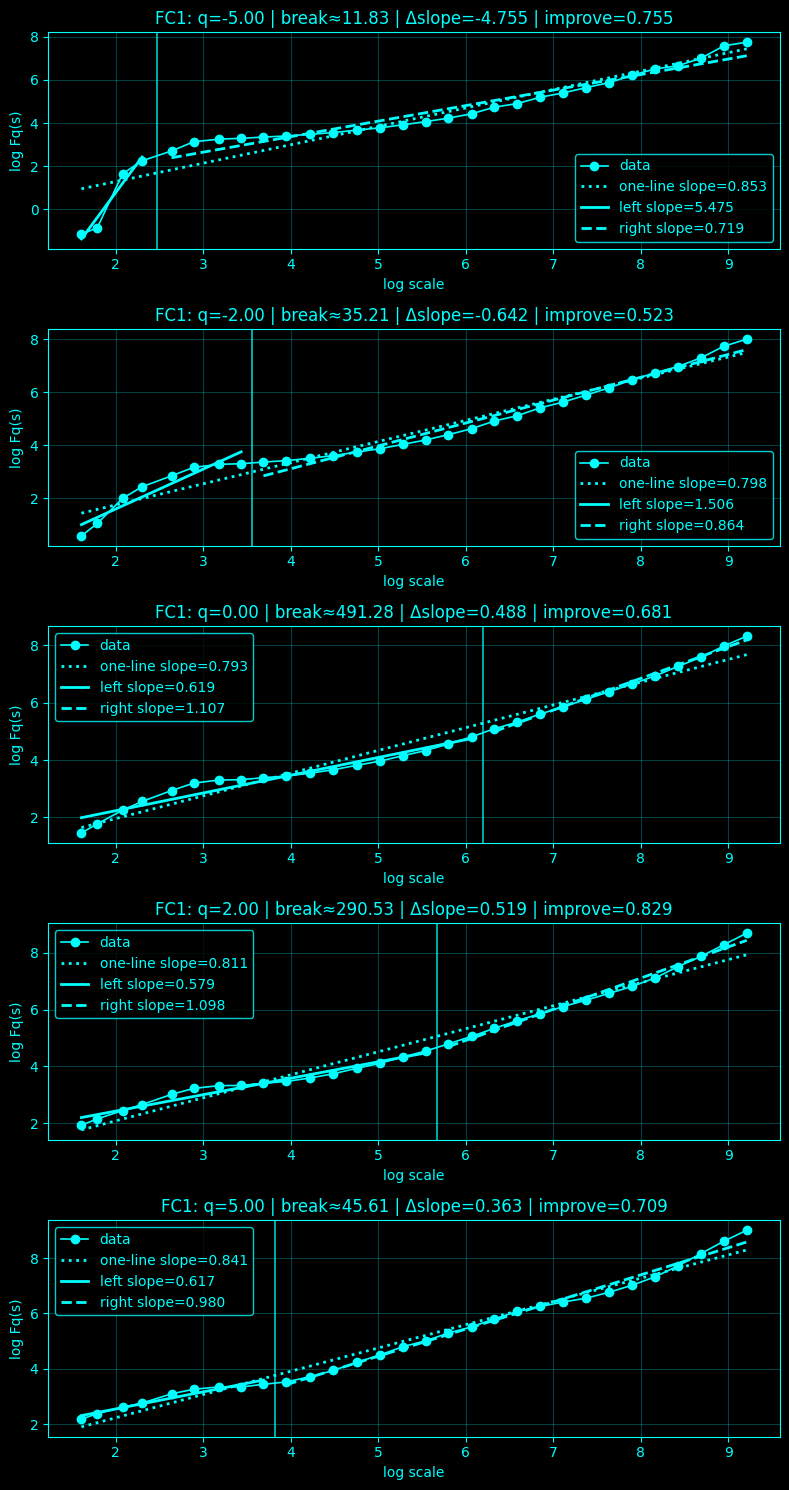

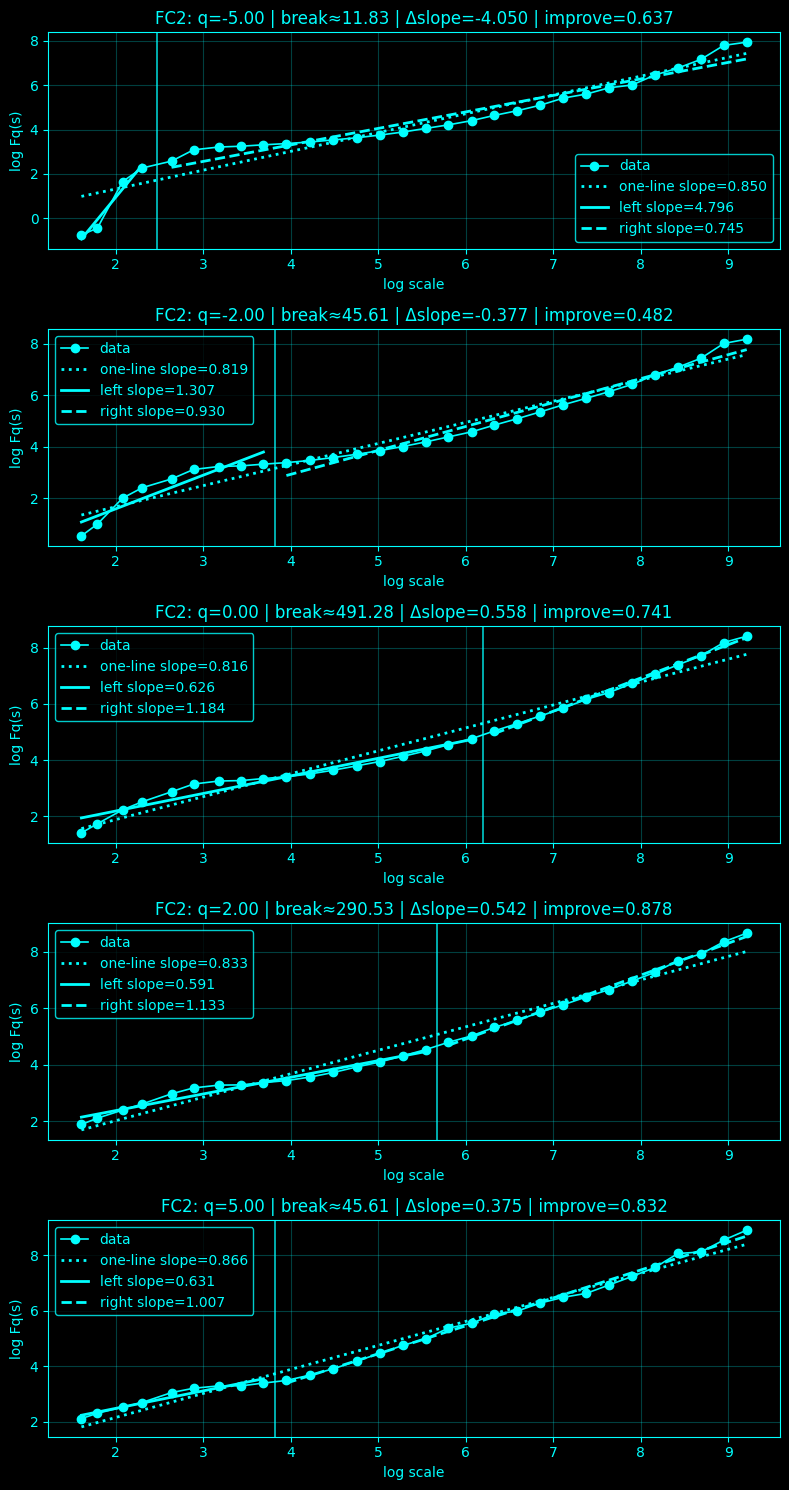

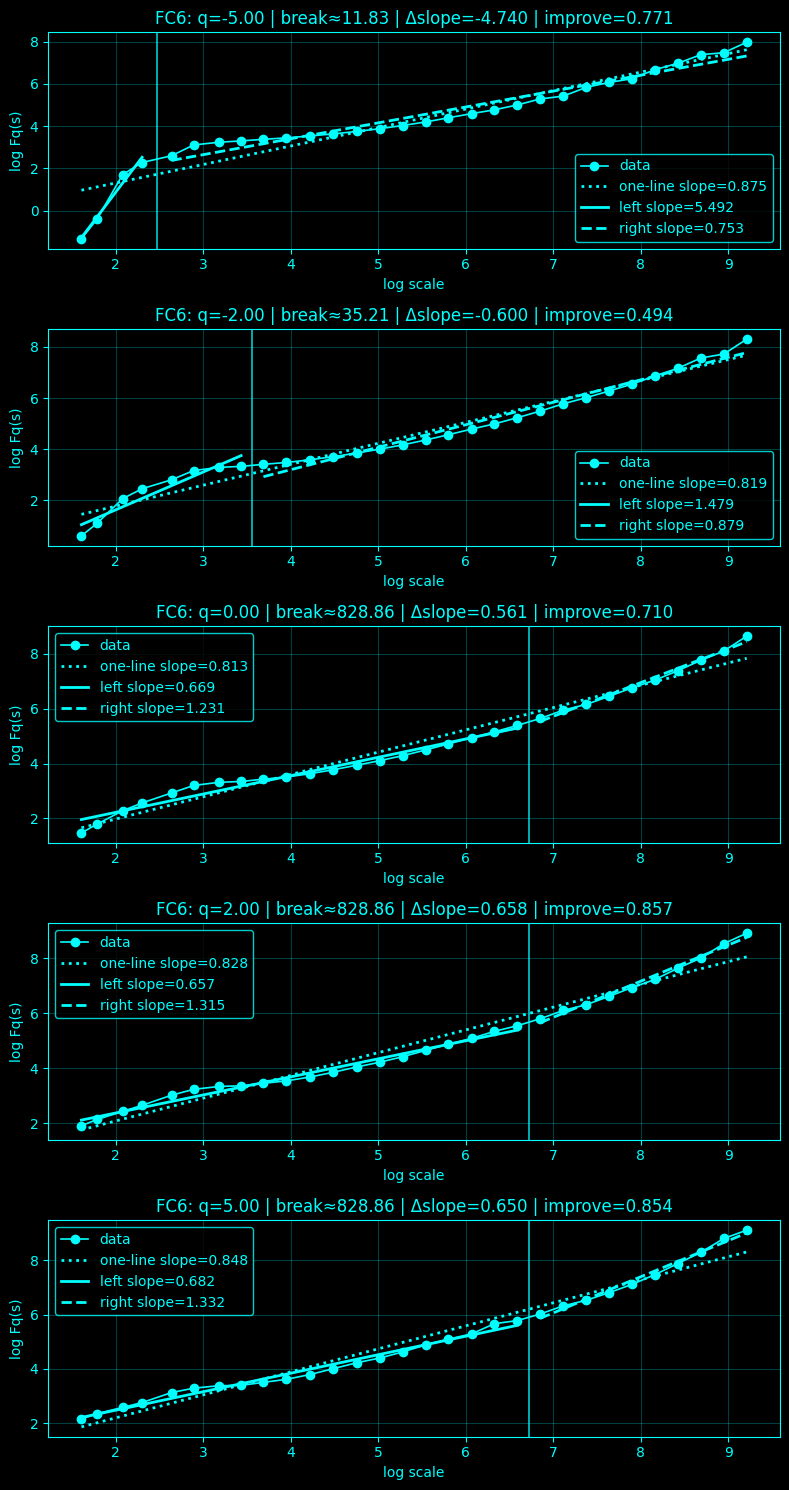

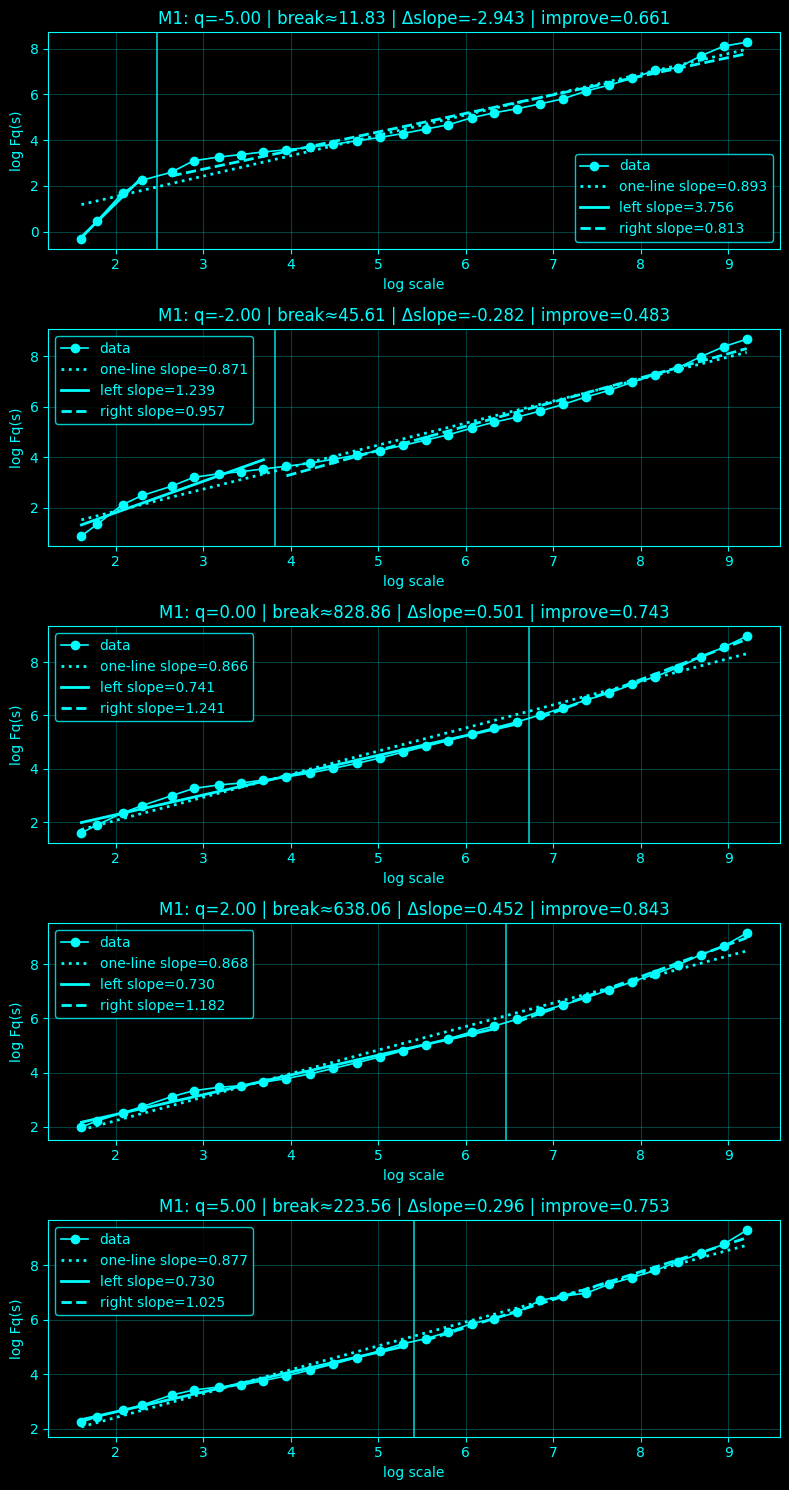

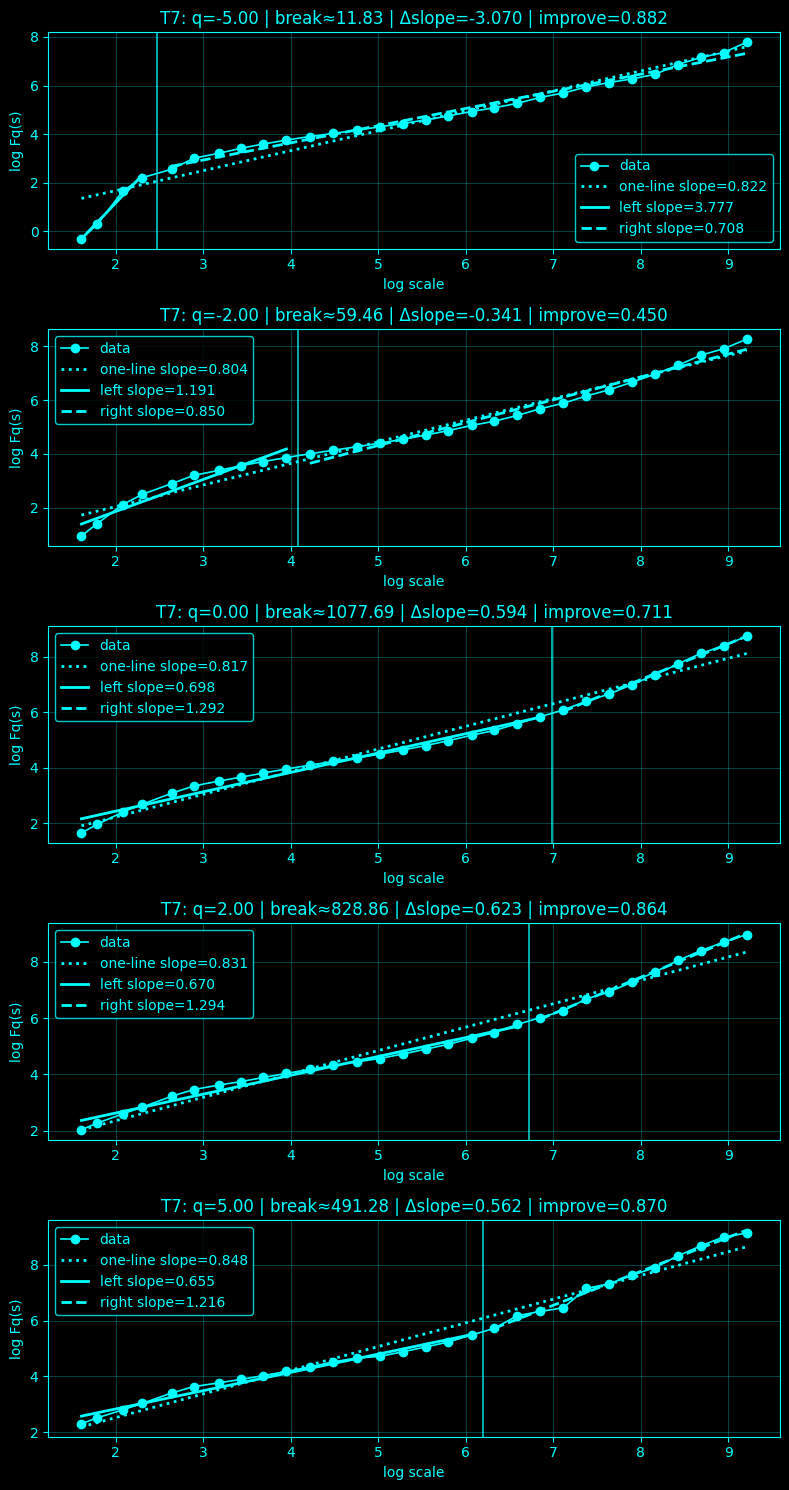

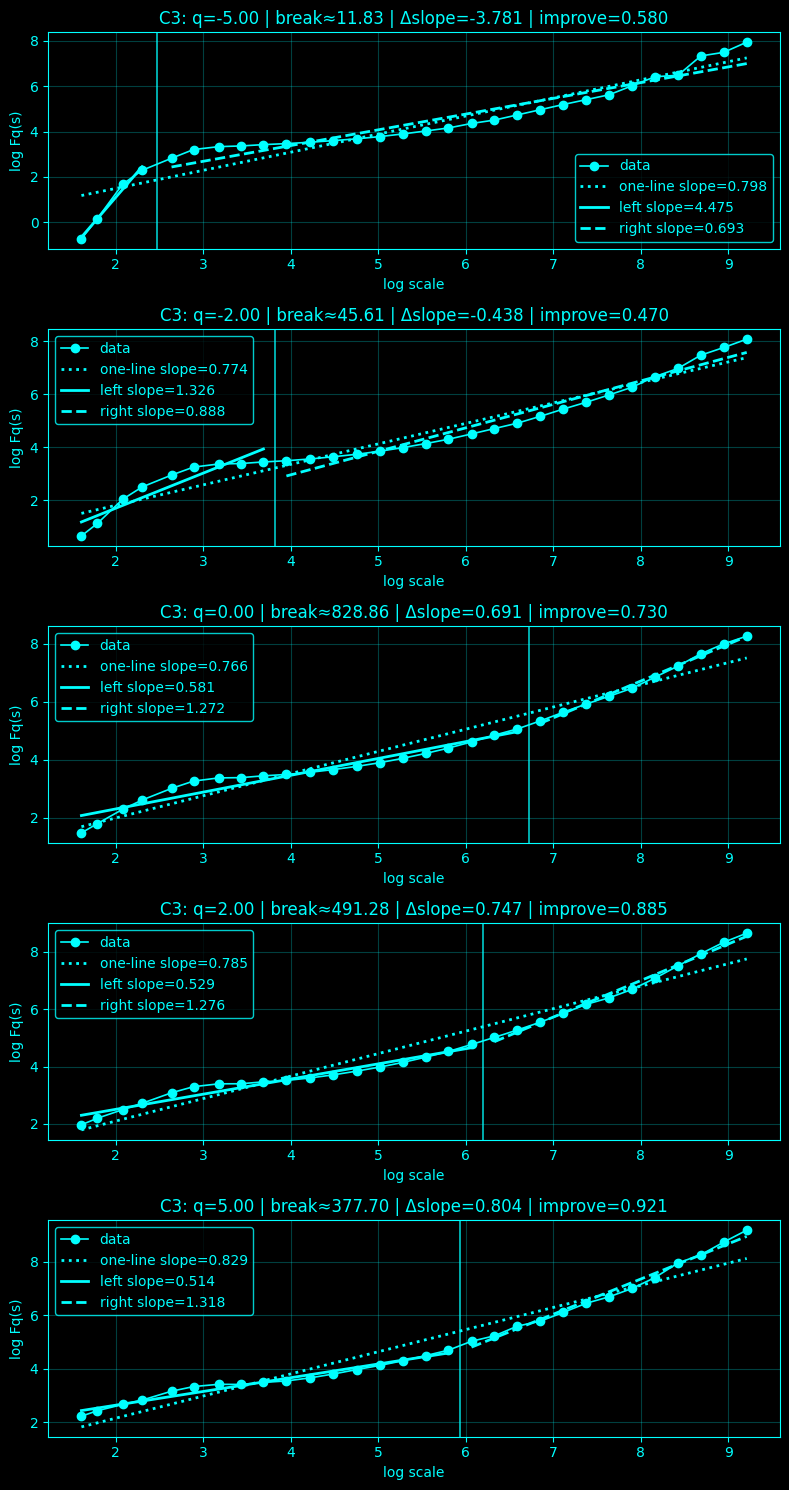

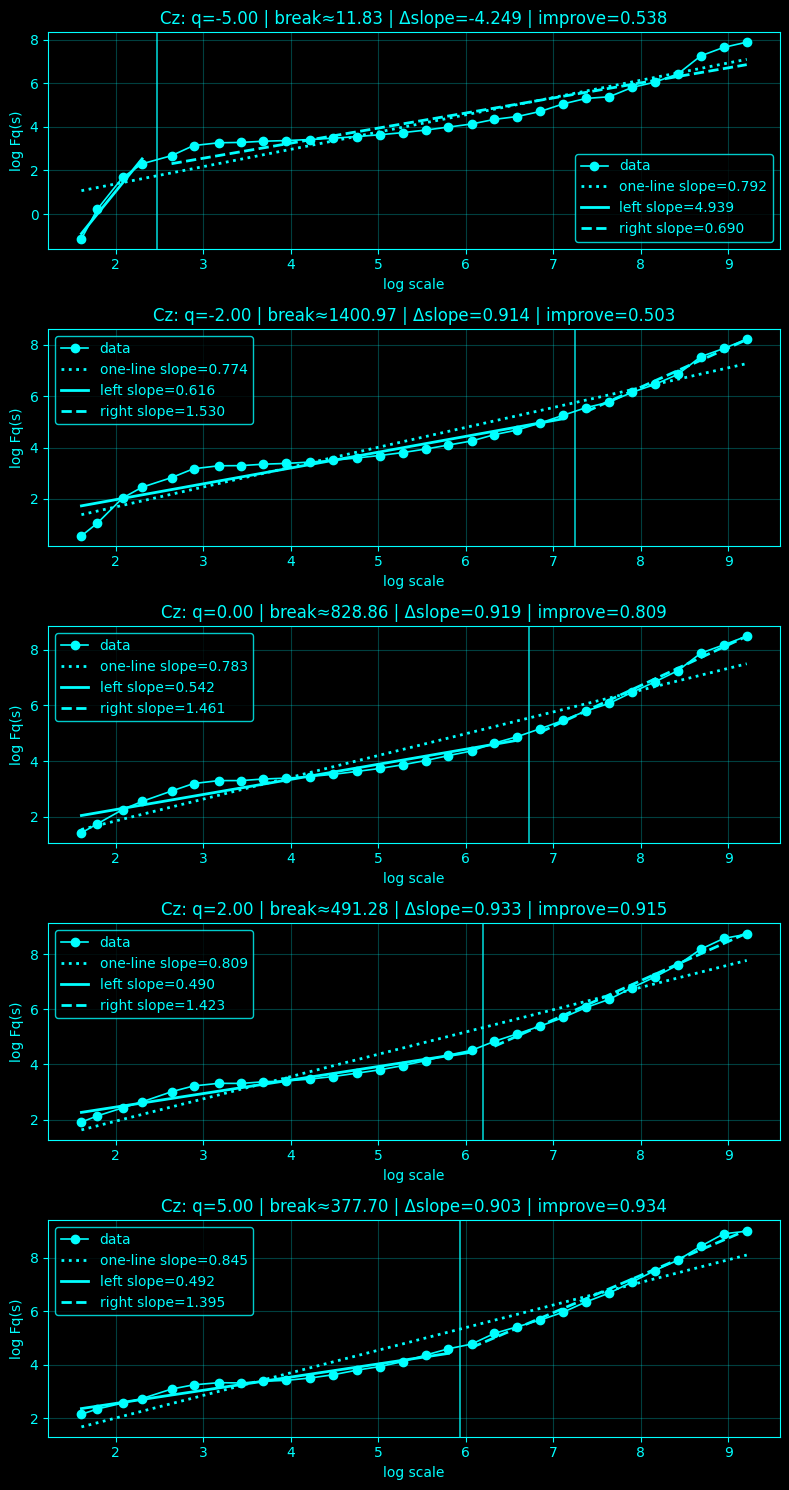

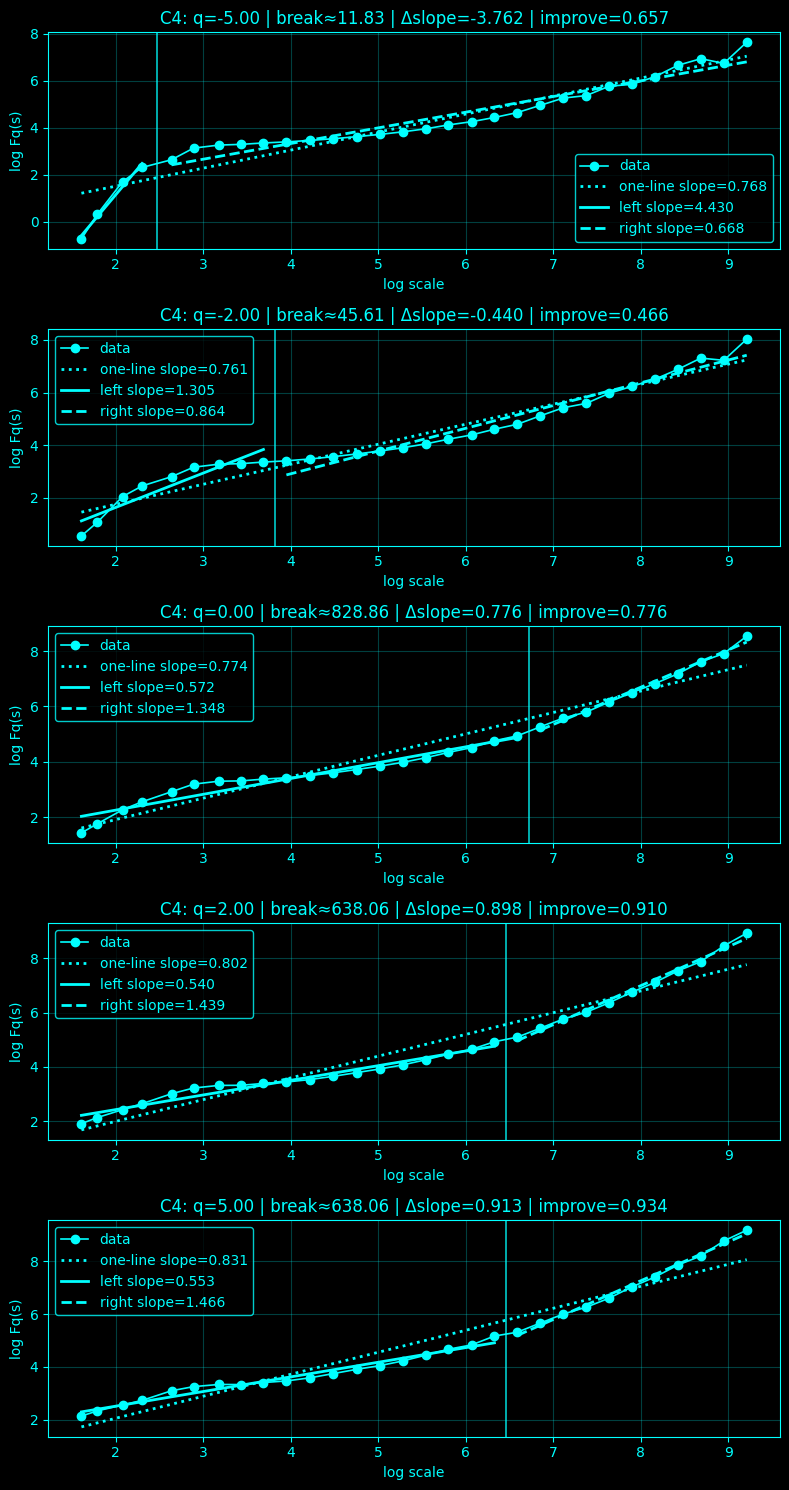

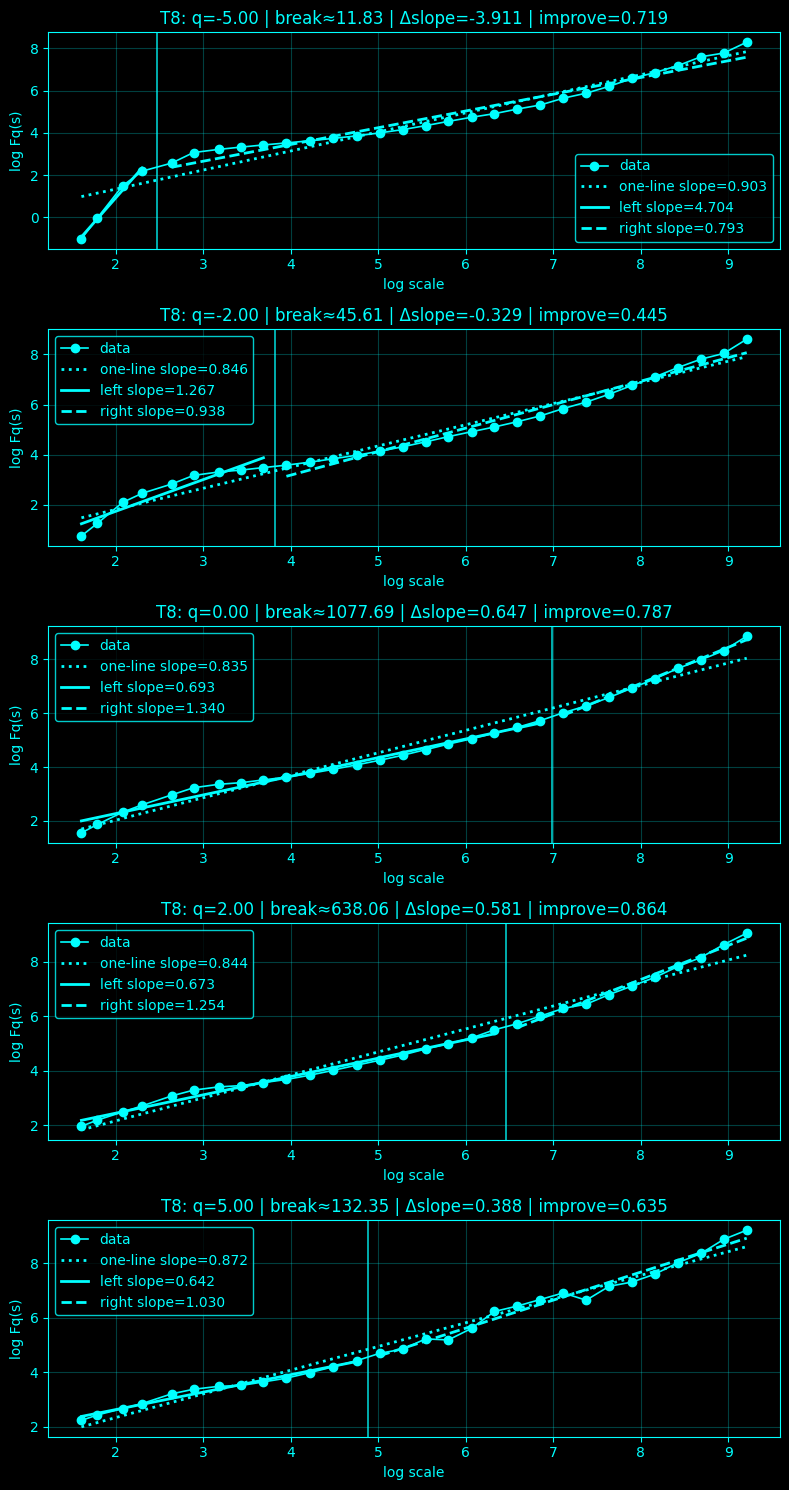

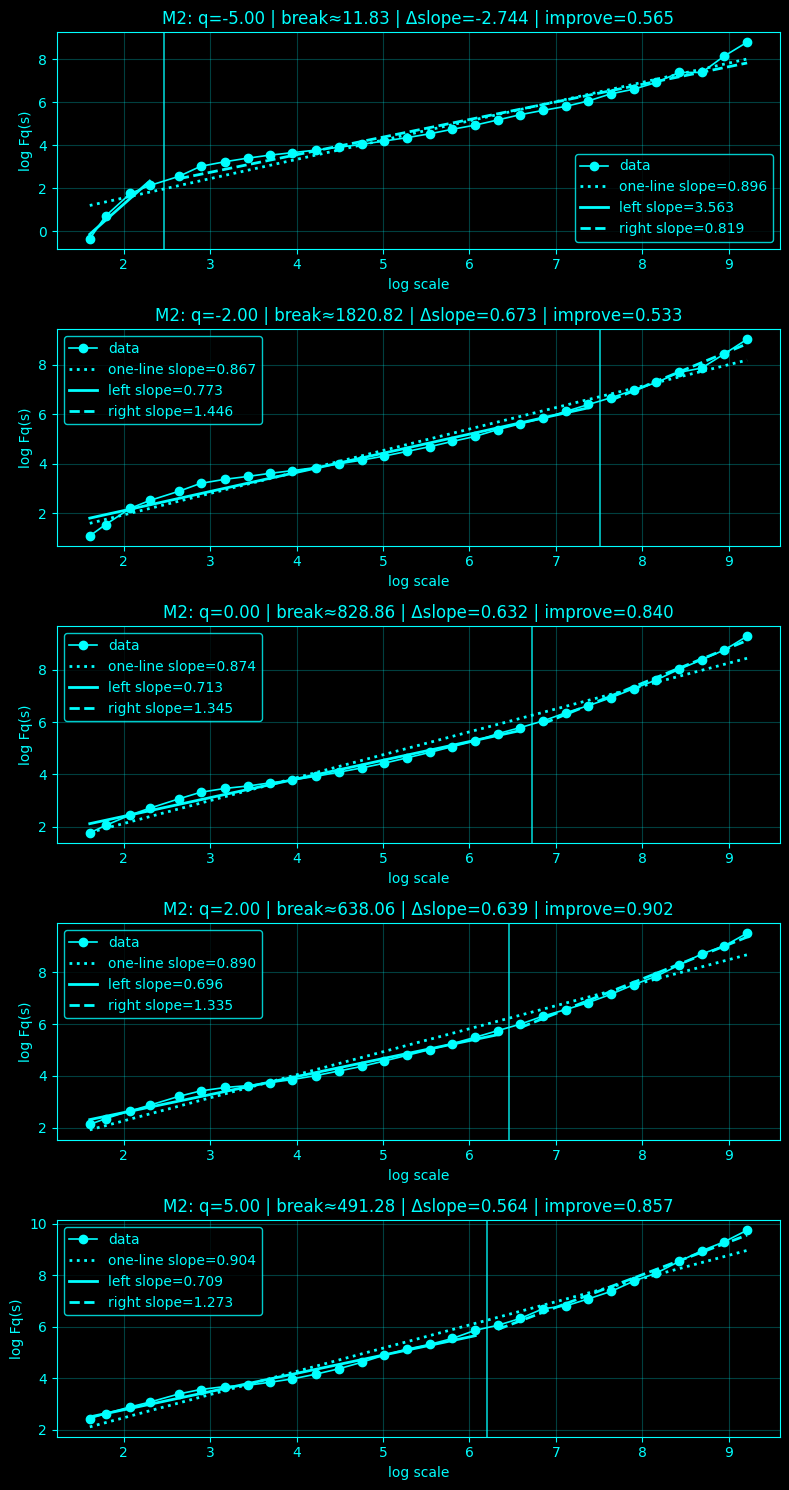

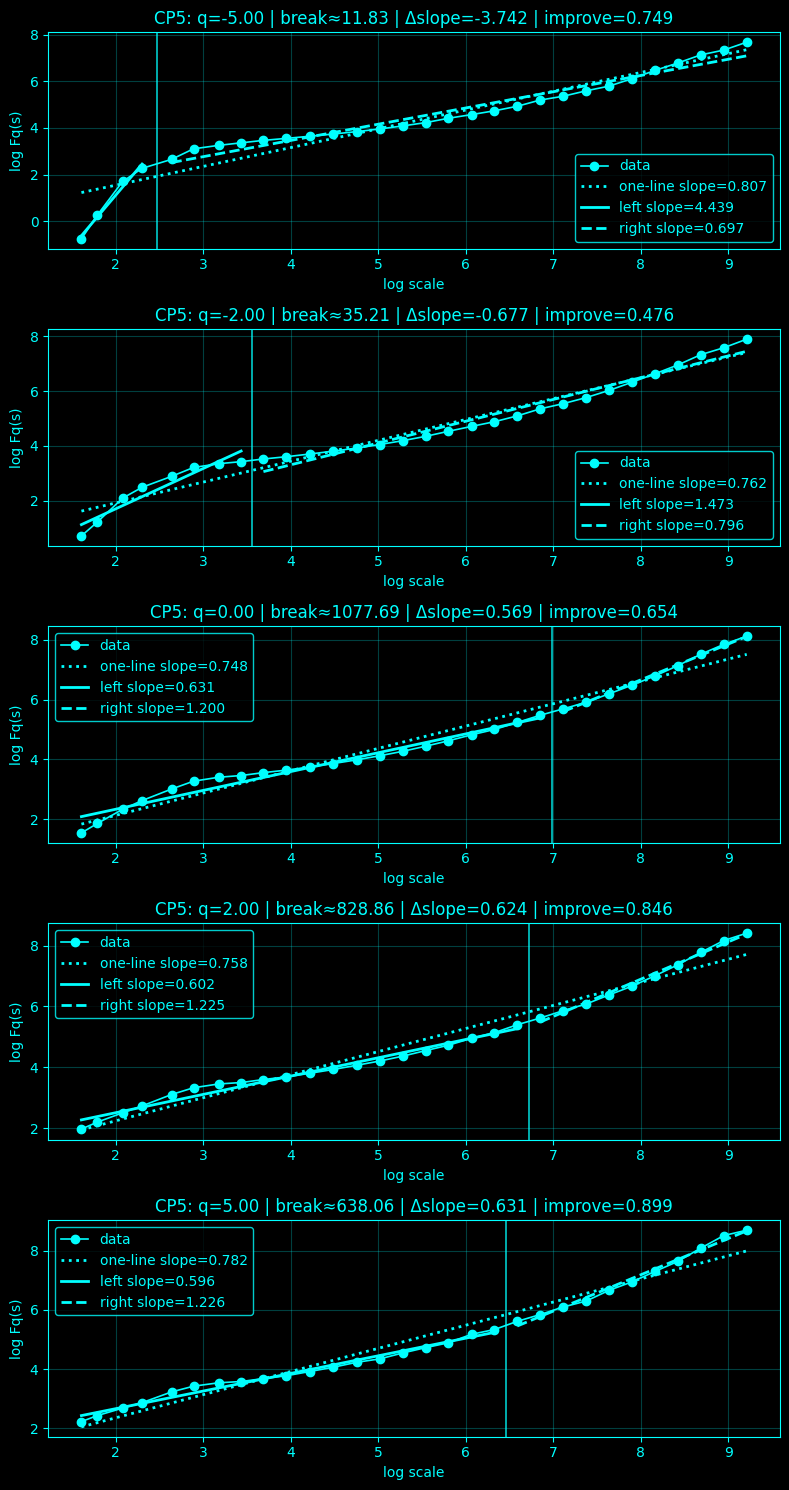

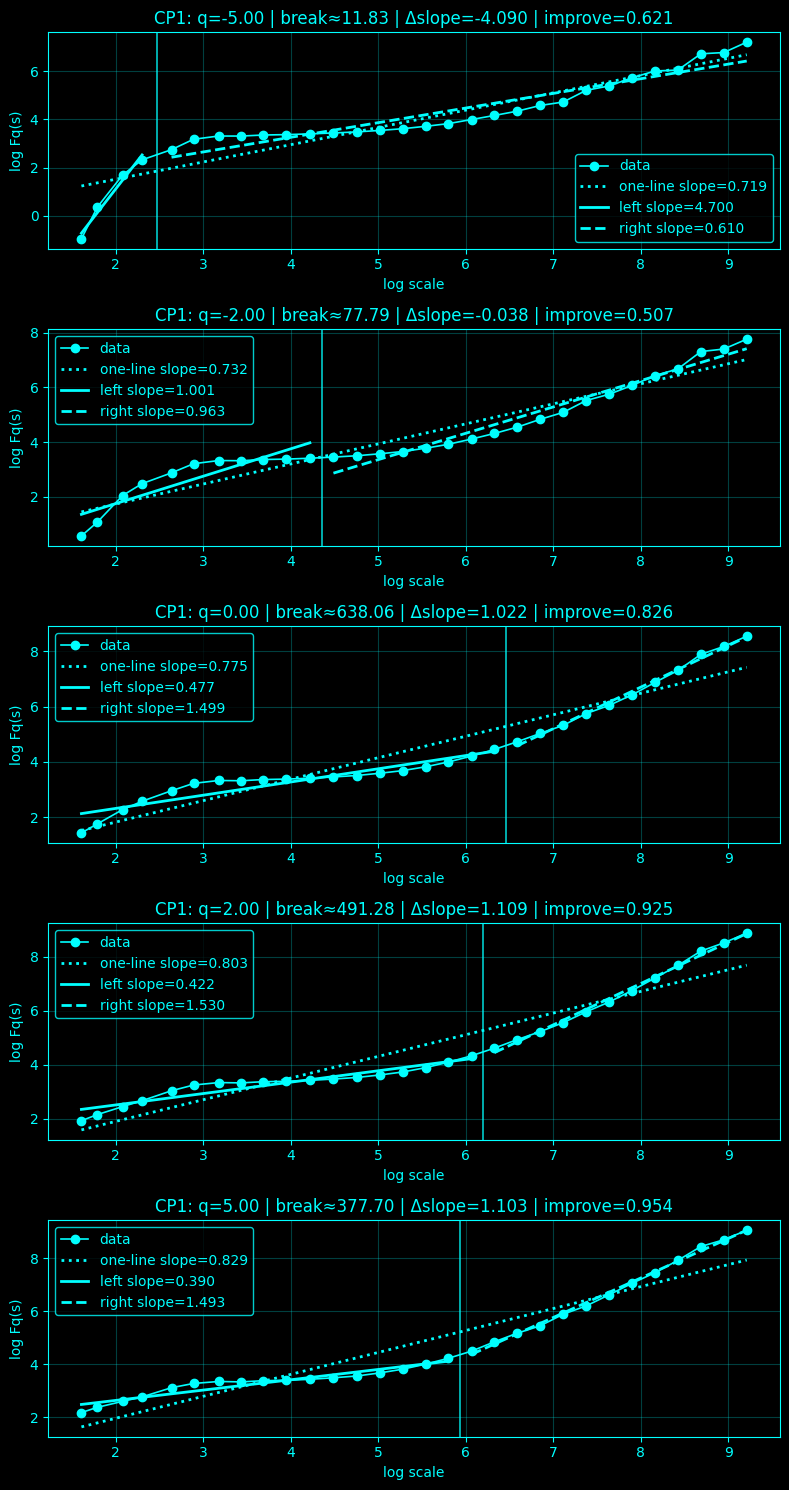

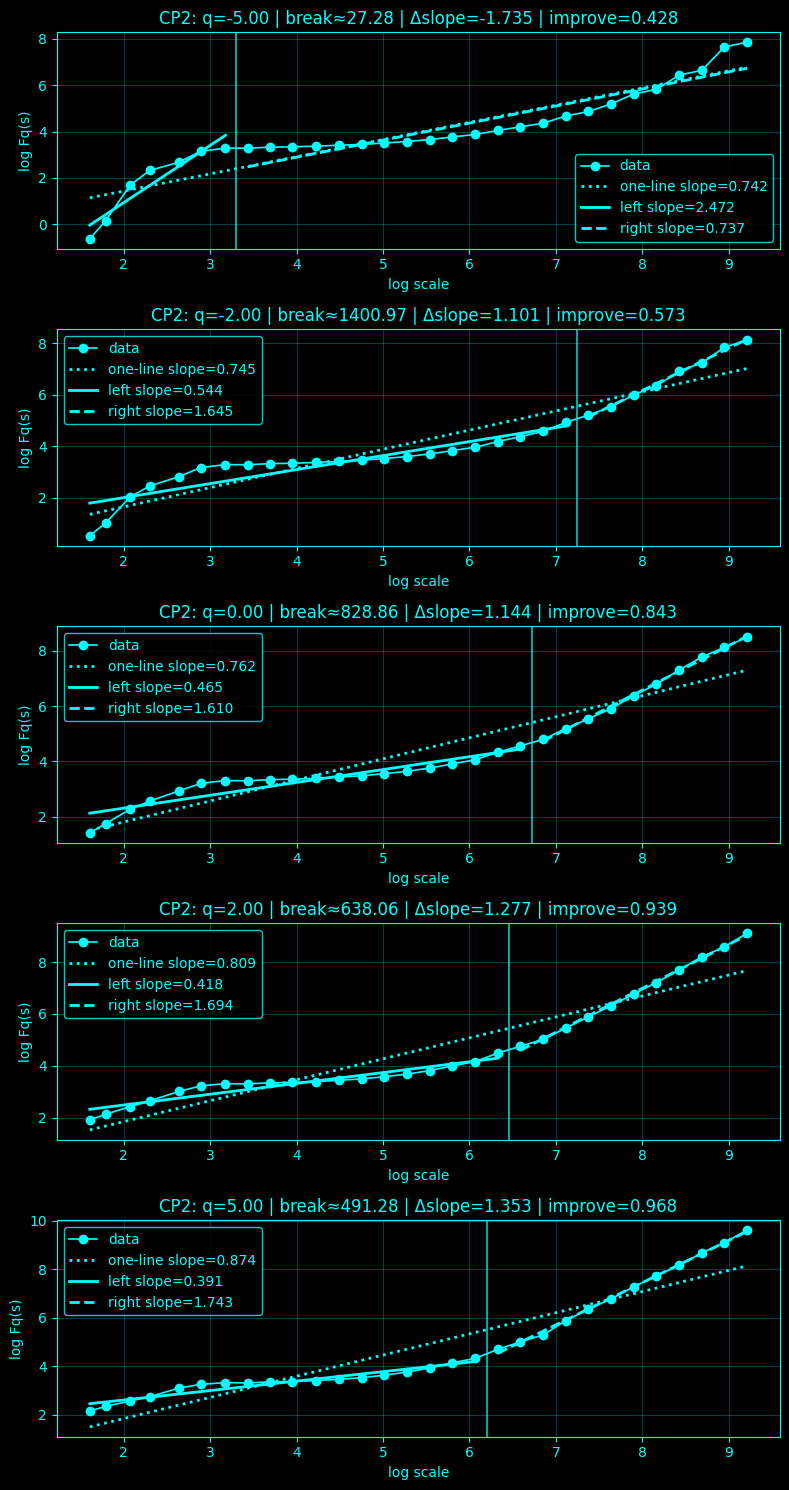

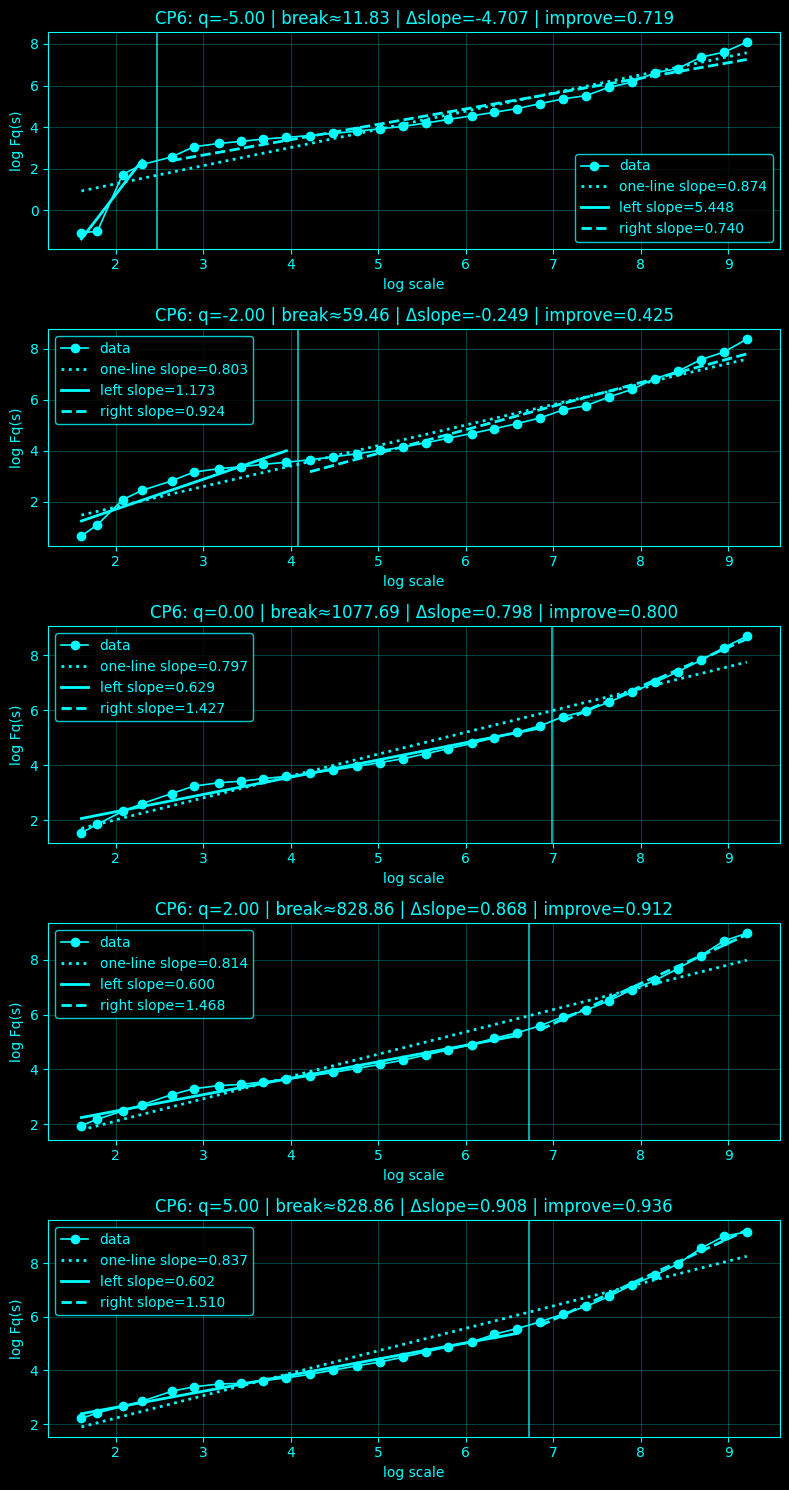

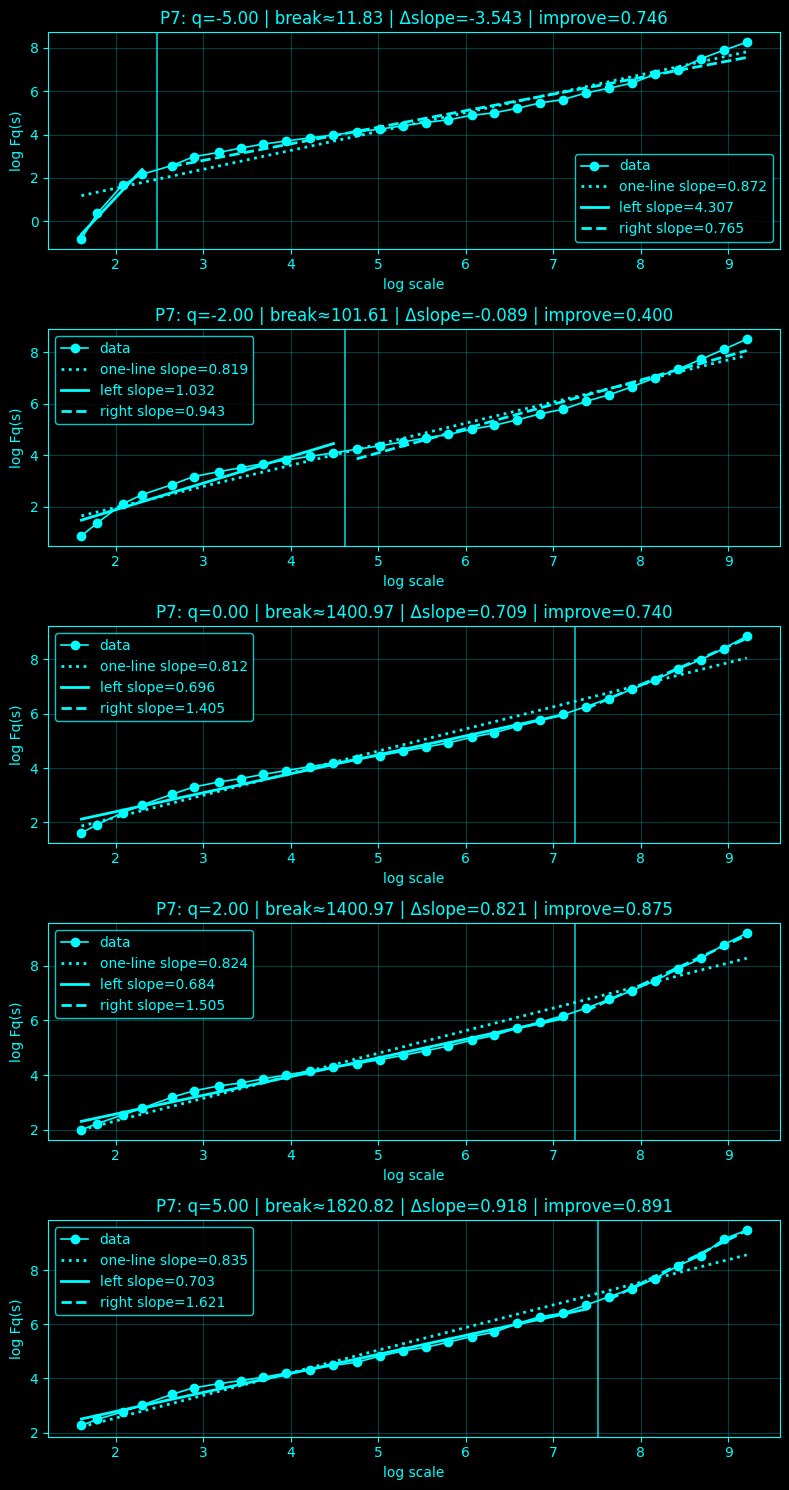

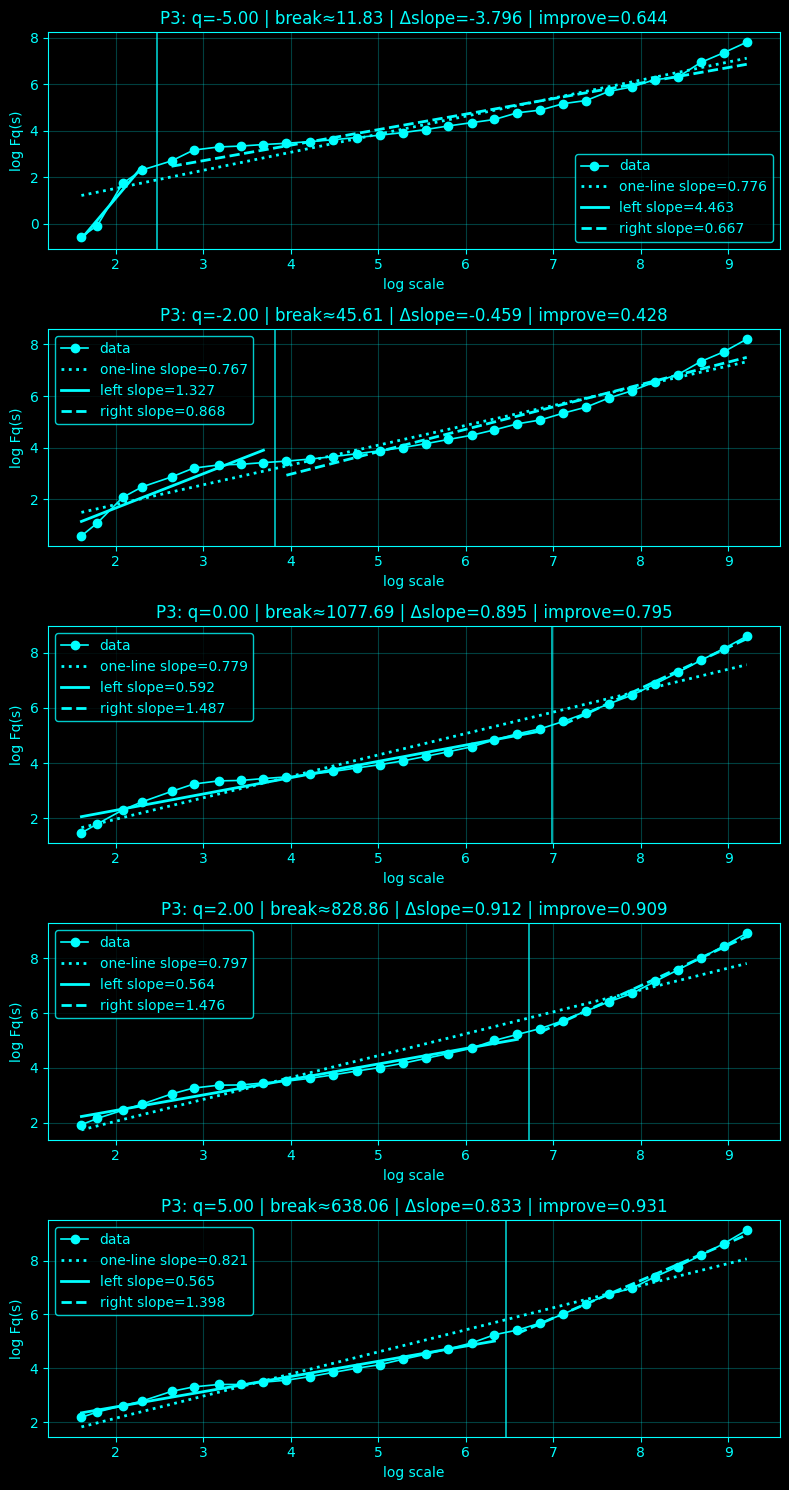

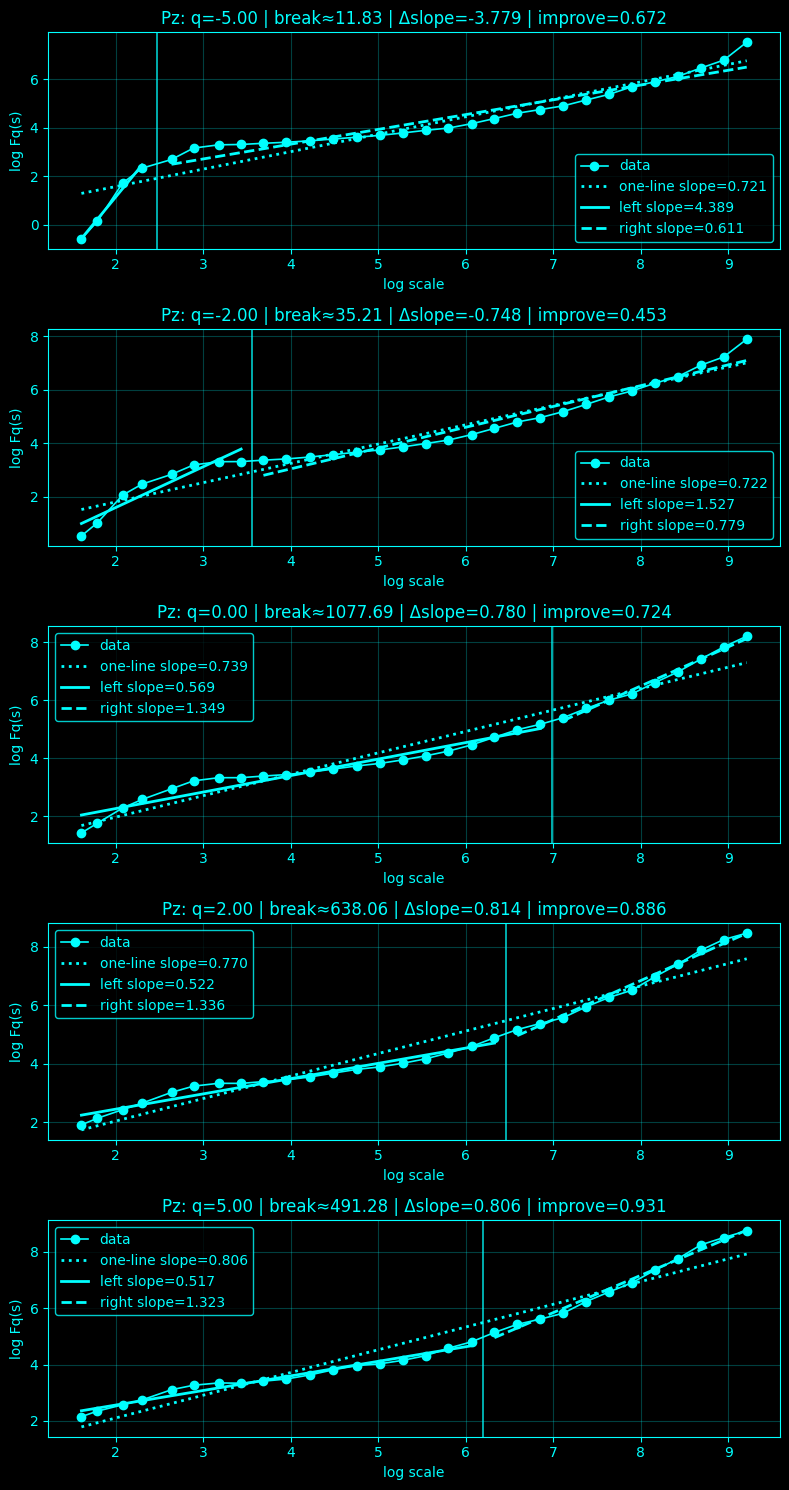

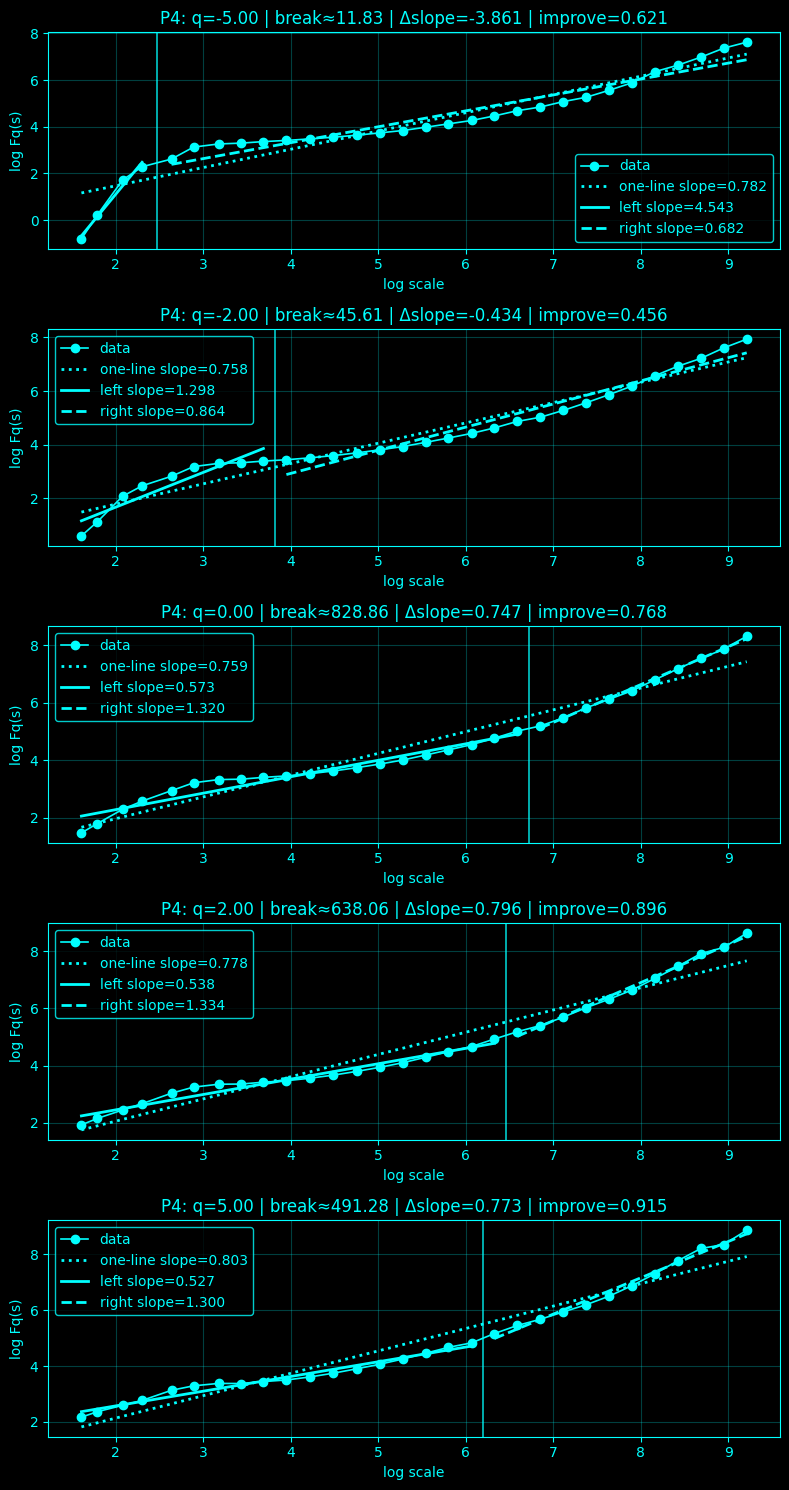

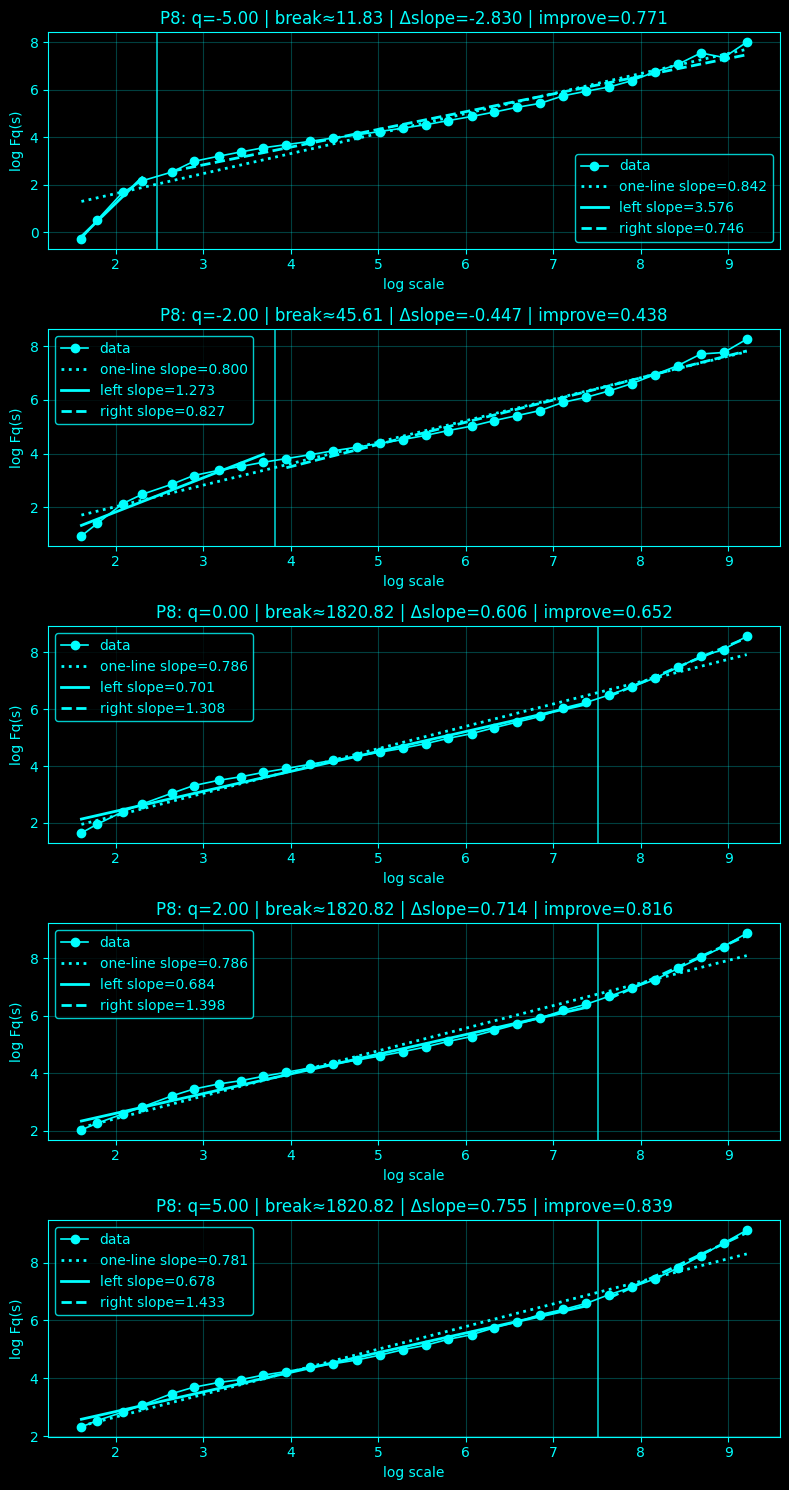

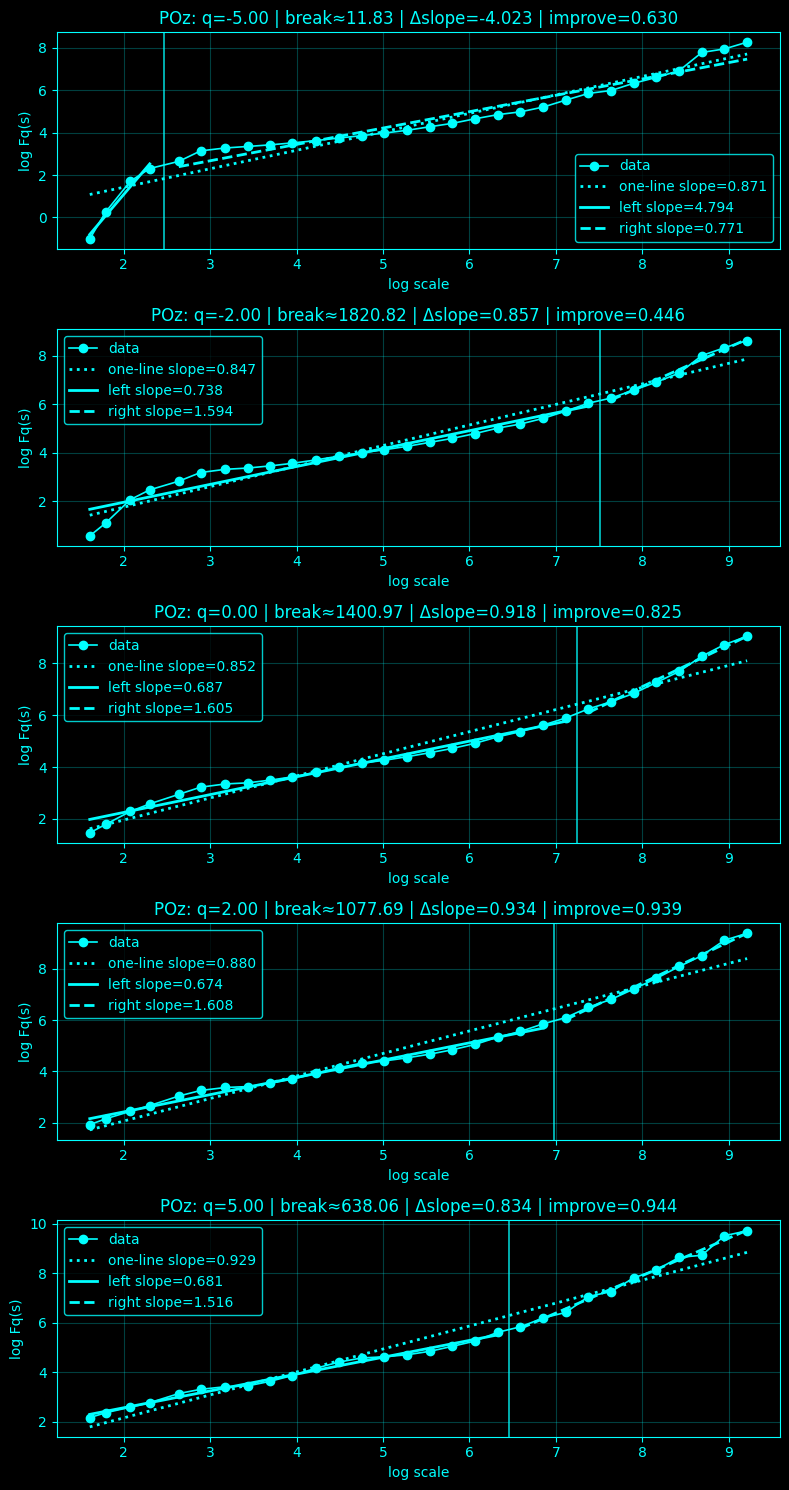

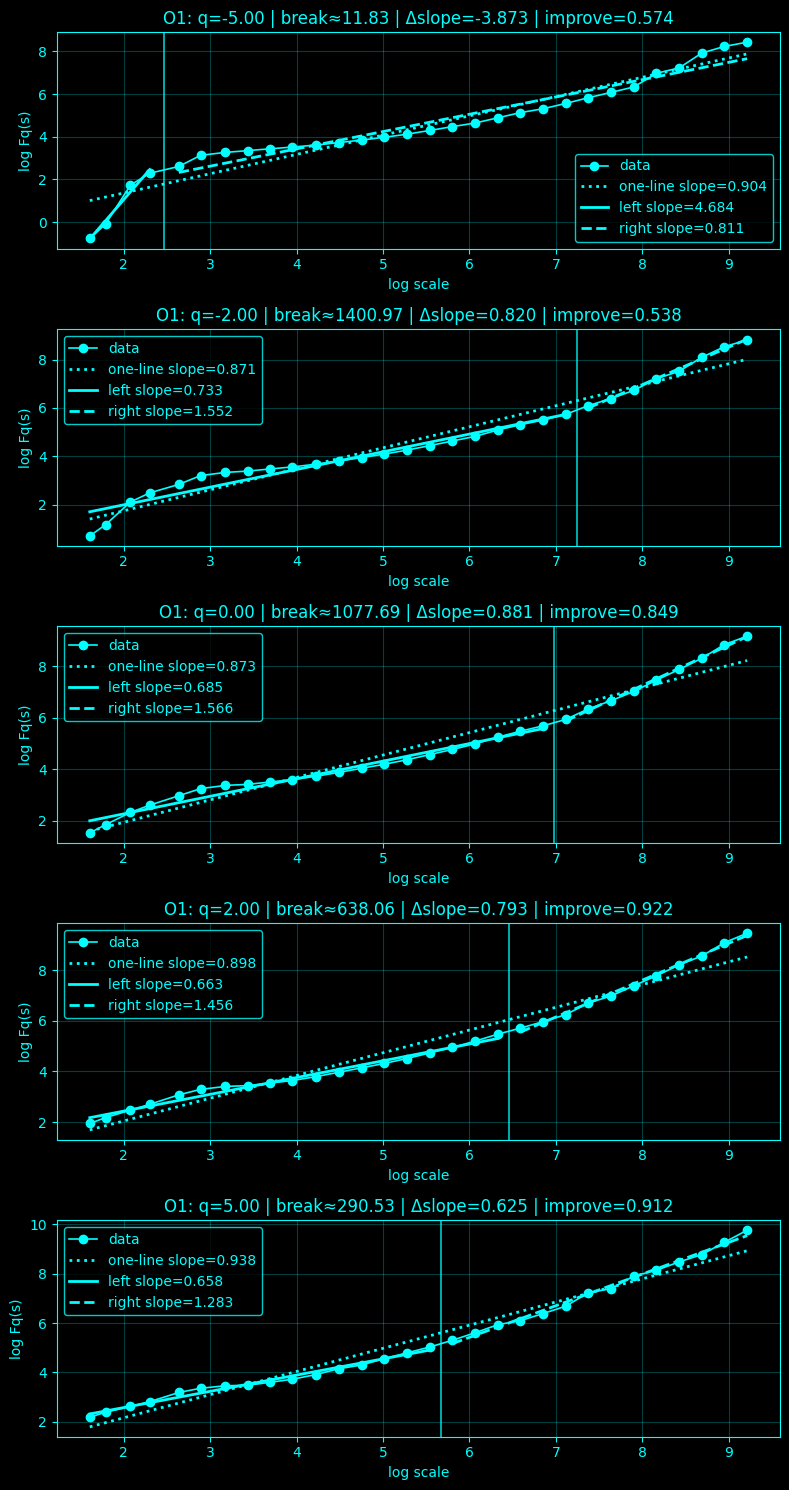

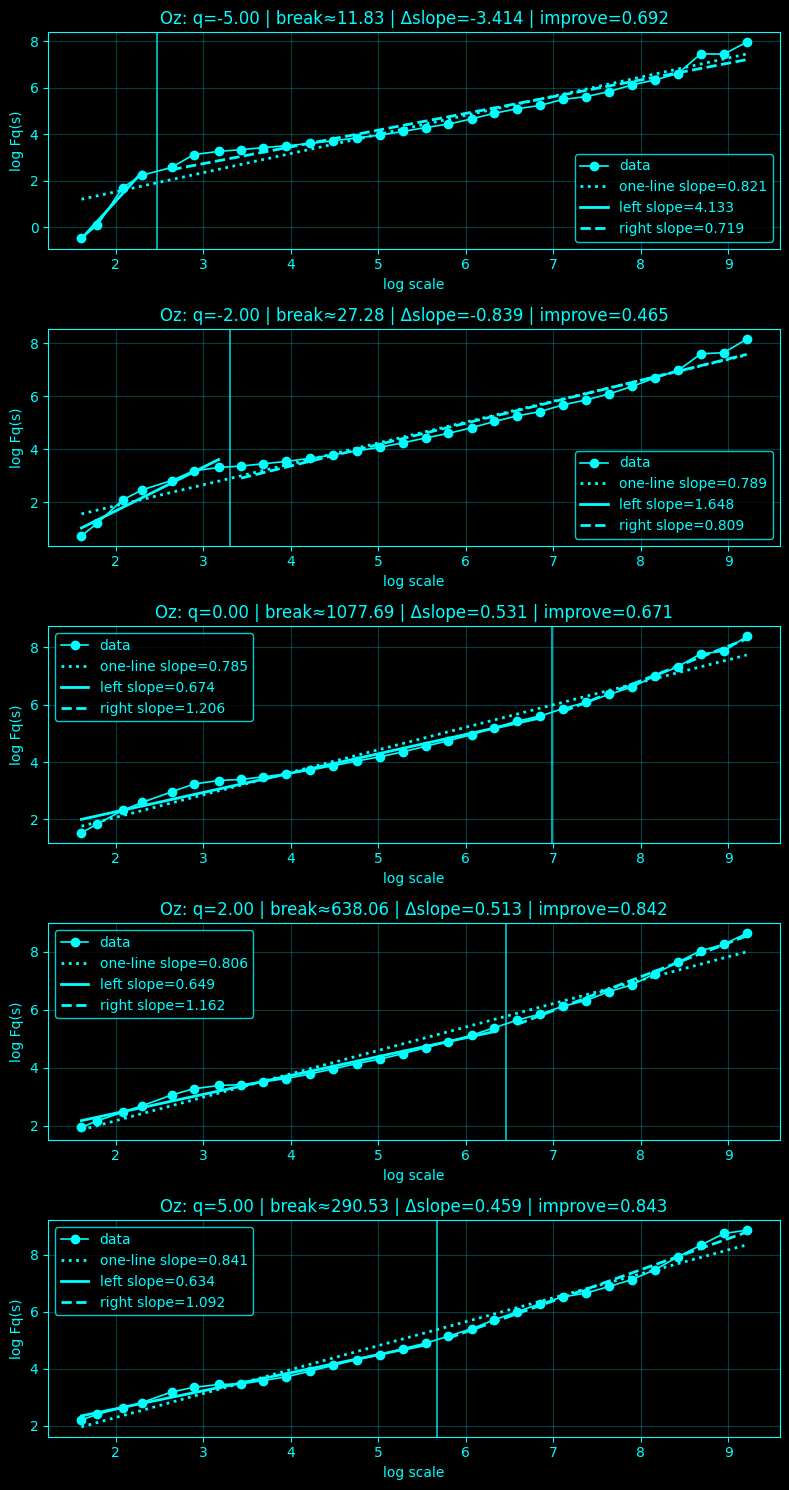

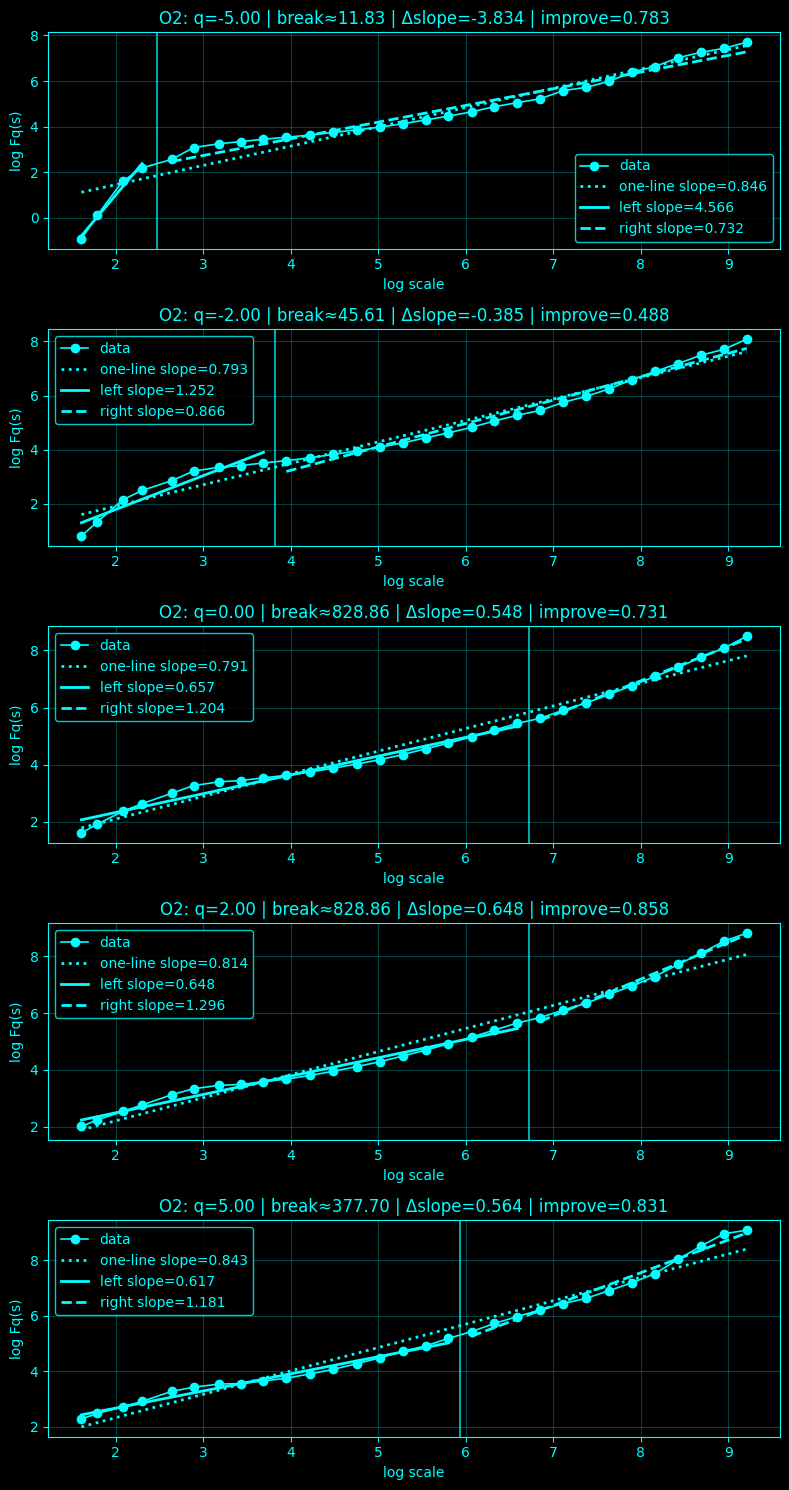


Crossover summary:
     channel     q  one_slope  left_slope  right_slope  delta_slope  \
0        Fp1 -5.00   0.952581    2.166044     0.948449    -1.217596   
1        Fp1 -4.75   0.950490    2.117535     0.952073    -1.165462   
2        Fp1 -4.50   0.948435    2.065922     0.956007    -1.109915   
3        Fp1 -4.25   0.946446    1.768427     0.987844    -0.780583   
4        Fp1 -4.00   0.944563    1.719302     0.992528    -0.726774   
...      ...   ...        ...         ...          ...          ...   
1307      O2  4.00   0.836048    0.628335     1.220646     0.592312   
1308      O2  4.25   0.837970    0.629671     1.218668     0.588997   
1309      O2  4.50   0.839696    0.615760     1.186504     0.570745   
1310      O2  4.75   0.841226    0.616594     1.184136     0.567543   
1311      O2  5.00   0.842559    0.617394     1.181478     0.564084   

      abs_delta_slope  break_scale_mid  break_log_scale_mid   sse_one  \
0            1.217596        27.276363             3.3

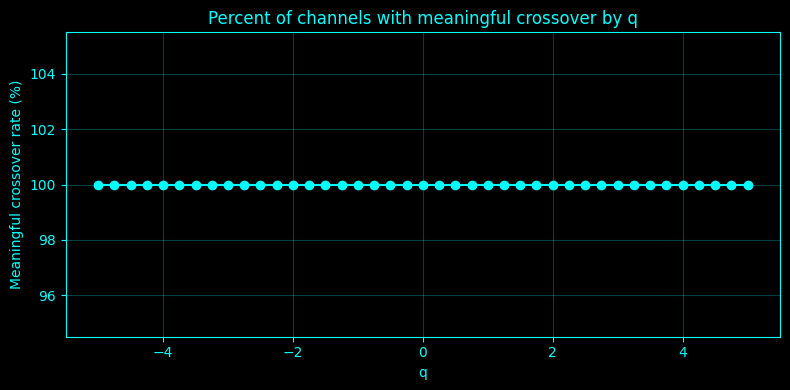

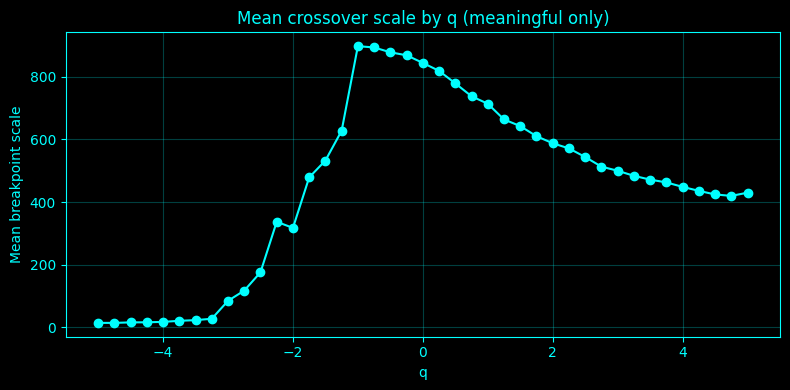

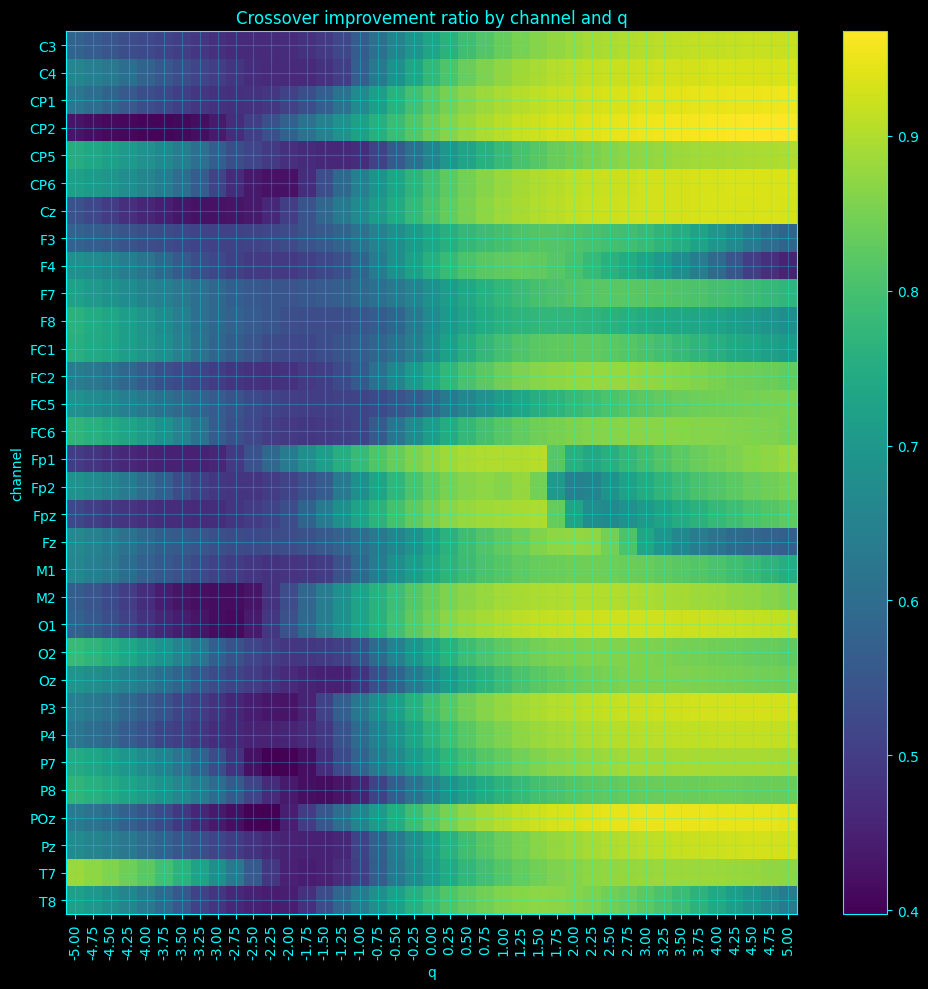

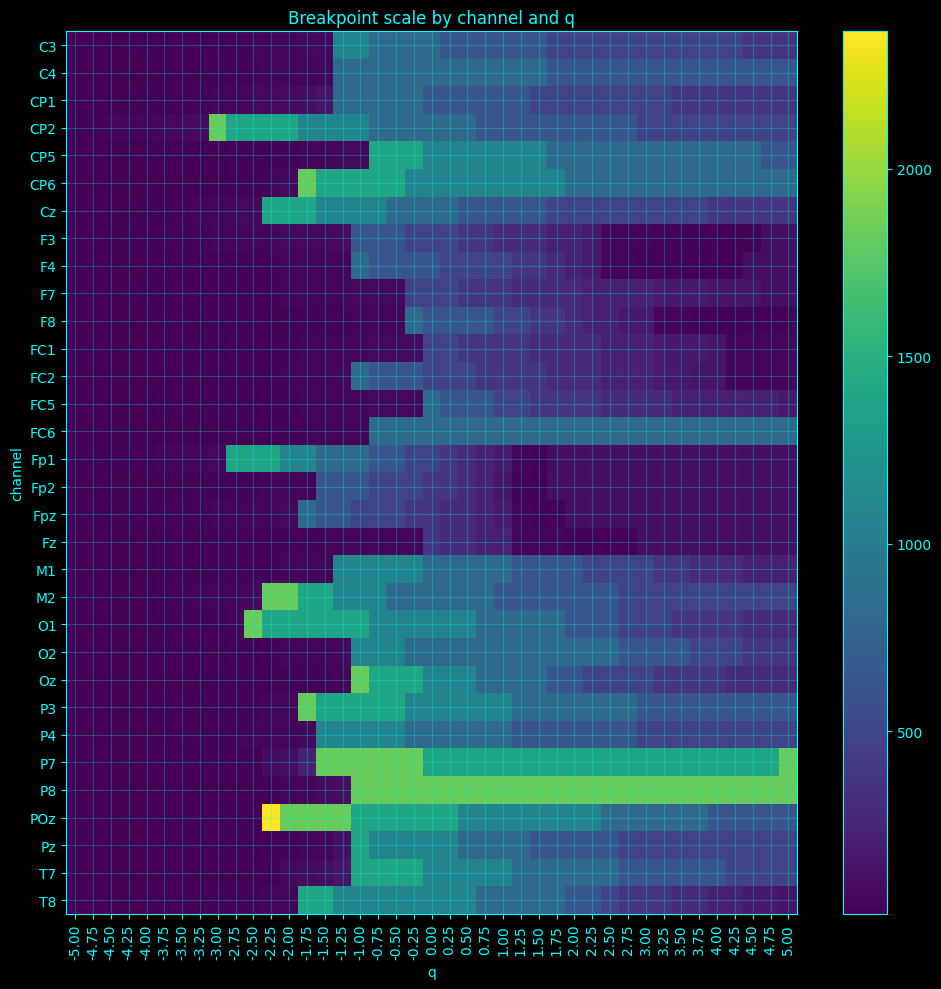


Top channels by crossover improvement near q=2.00:
     channel    q  one_slope  left_slope  right_slope  delta_slope  \
1176     POz  2.0   0.879623    0.674056     1.608361     0.934305   
889      CP2  2.0   0.808981    0.417858     1.694491     1.276633   
848      CP1  2.0   0.802539    0.421923     1.530462     1.108539   
1217      O1  2.0   0.898035    0.662522     1.455690     0.793168   
643       Cz  2.0   0.808693    0.490262     1.423446     0.933184   
930      CP6  2.0   0.813850    0.599635     1.467696     0.868061   
684       C4  2.0   0.801864    0.540276     1.438502     0.898226   
1012      P3  2.0   0.796963    0.563719     1.475594     0.911875   
766       M2  2.0   0.890355    0.695718     1.334715     0.638997   
1094      P4  2.0   0.778127    0.537964     1.333945     0.795982   

      abs_delta_slope  break_scale_mid  break_log_scale_mid    sse_one  \
1176         0.934305      1077.685019             6.982571   5.477256   
889          1.276633       6

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
source_dir = os.path.join(base_dir, "mfdfa_local_slope_results")
out_dir = os.path.join(base_dir, "mfdfa_crossover_detection")
os.makedirs(out_dir, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

channels_to_run = eeg_channels.copy()

# q values to inspect closely
q_plot_vals = [-5, -2, 0, 2, 5]

# piecewise fit settings
min_seg_points = 4
min_total_points = 8
improvement_threshold = 0.10

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# FIT HELPERS
# -------------------------------------------------------
def linear_fit(x, y):
    coef = np.polyfit(x, y, 1)
    yhat = np.polyval(coef, x)
    sse = float(np.sum((y - yhat) ** 2))
    return float(coef[0]), float(coef[1]), yhat, sse

def best_piecewise_break(x, y, min_seg_points=4):
    n = len(x)
    best = None

    for b in range(min_seg_points - 1, n - min_seg_points):
        x1, y1 = x[:b+1], y[:b+1]
        x2, y2 = x[b+1:], y[b+1:]

        m1, c1, yhat1, sse1 = linear_fit(x1, y1)
        m2, c2, yhat2, sse2 = linear_fit(x2, y2)

        sse_total = sse1 + sse2
        if best is None or sse_total < best["sse_piecewise"]:
            best = {
                "break_idx": b,
                "break_x": float(x[b]),
                "break_x_next": float(x[b+1]),
                "break_x_mid": float(0.5 * (x[b] + x[b+1])),
                "left_slope": m1,
                "left_intercept": c1,
                "right_slope": m2,
                "right_intercept": c2,
                "yhat_left": yhat1,
                "yhat_right": yhat2,
                "sse_piecewise": sse_total,
            }

    return best

def detect_crossover_for_curve(scales, Fq_curve, min_seg_points=4, min_total_points=8):
    scales = np.asarray(scales, dtype=float)
    Fq_curve = np.asarray(Fq_curve, dtype=float)

    mask = np.isfinite(Fq_curve) & (Fq_curve > 0)
    x = np.log(scales[mask])
    y = np.log(Fq_curve[mask])

    if len(x) < min_total_points:
        return None

    slope1, intercept1, yhat1, sse1 = linear_fit(x, y)

    piece = best_piecewise_break(x, y, min_seg_points=min_seg_points)
    if piece is None:
        return None

    improvement = (sse1 - piece["sse_piecewise"]) / max(sse1, 1e-12)

    result = {
        "x": x,
        "y": y,
        "one_slope": slope1,
        "one_intercept": intercept1,
        "yhat_one": yhat1,
        "sse_one": sse1,
        "break_idx": piece["break_idx"],
        "break_log_scale_left": piece["break_x"],
        "break_log_scale_right": piece["break_x_next"],
        "break_log_scale_mid": piece["break_x_mid"],
        "break_scale_mid": float(np.exp(piece["break_x_mid"])),
        "left_slope": piece["left_slope"],
        "right_slope": piece["right_slope"],
        "left_intercept": piece["left_intercept"],
        "right_intercept": piece["right_intercept"],
        "yhat_left": piece["yhat_left"],
        "yhat_right": piece["yhat_right"],
        "sse_piecewise": piece["sse_piecewise"],
        "improvement_ratio": improvement,
        "delta_slope": piece["right_slope"] - piece["left_slope"],
        "abs_delta_slope": abs(piece["right_slope"] - piece["left_slope"]),
        "is_meaningful": improvement >= improvement_threshold,
    }
    return result

# -------------------------------------------------------
# LOAD ONE FILE TO GET REFERENCE Q GRID
# -------------------------------------------------------
q_ref = None
for ch in channels_to_run:
    npz_path = os.path.join(source_dir, f"{ch}_local_slope_mfdfa.npz")
    if os.path.exists(npz_path):
        dat = np.load(npz_path, allow_pickle=True)
        q_ref = np.asarray(dat["q_vals"], dtype=float)
        break

if q_ref is None:
    raise FileNotFoundError(f"No local-slope NPZ files found in {source_dir}")

q_plot_idx = [int(np.argmin(np.abs(q_ref - q))) for q in q_plot_vals]

# -------------------------------------------------------
# RUN CROSSOVER DETECTION
# -------------------------------------------------------
summary_rows = []

for ch in channels_to_run:
    npz_path = os.path.join(source_dir, f"{ch}_local_slope_mfdfa.npz")
    if not os.path.exists(npz_path):
        print(f"Missing file for {ch}: {npz_path}")
        continue

    dat = np.load(npz_path, allow_pickle=True)

    scales = np.asarray(dat["scales"], dtype=float)
    q_vals = np.asarray(dat["q_vals"], dtype=float)
    Fq = np.asarray(dat["Fq"], dtype=float)

    if Fq.shape != (len(scales), len(q_vals)):
        raise ValueError(f"Unexpected Fq shape for {ch}: {Fq.shape}")

    channel_results = []
    for qi, q in enumerate(q_vals):
        res = detect_crossover_for_curve(
            scales,
            Fq[:, qi],
            min_seg_points=min_seg_points,
            min_total_points=min_total_points
        )

        if res is None:
            summary_rows.append({
                "channel": ch,
                "q": q,
                "one_slope": np.nan,
                "left_slope": np.nan,
                "right_slope": np.nan,
                "delta_slope": np.nan,
                "abs_delta_slope": np.nan,
                "break_scale_mid": np.nan,
                "break_log_scale_mid": np.nan,
                "sse_one": np.nan,
                "sse_piecewise": np.nan,
                "improvement_ratio": np.nan,
                "is_meaningful": False,
            })
            channel_results.append(None)
            continue

        summary_rows.append({
            "channel": ch,
            "q": q,
            "one_slope": res["one_slope"],
            "left_slope": res["left_slope"],
            "right_slope": res["right_slope"],
            "delta_slope": res["delta_slope"],
            "abs_delta_slope": res["abs_delta_slope"],
            "break_scale_mid": res["break_scale_mid"],
            "break_log_scale_mid": res["break_log_scale_mid"],
            "sse_one": res["sse_one"],
            "sse_piecewise": res["sse_piecewise"],
            "improvement_ratio": res["improvement_ratio"],
            "is_meaningful": bool(res["is_meaningful"]),
        })
        channel_results.append(res)

    # ---------------------------------------------------
    # PER-CHANNEL PLOTS FOR SELECTED q
    # ---------------------------------------------------
    fig, axes = plt.subplots(len(q_plot_idx), 1, figsize=(8, 3 * len(q_plot_idx)), facecolor=BG)
    if len(q_plot_idx) == 1:
        axes = [axes]

    for ax, qi in zip(axes, q_plot_idx):
        style_ax(ax)
        q = q_vals[qi]
        res = channel_results[qi]

        if res is None:
            ax.set_title(f"{ch}: q={q:.2f} | insufficient data")
            continue

        x = res["x"]
        y = res["y"]

        ax.plot(
            x, y,
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            linewidth=1.2,
            label="data"
        )

        ax.plot(
            x, res["yhat_one"],
            color=ACCENT,
            linestyle=":",
            linewidth=2,
            label=f"one-line slope={res['one_slope']:.3f}"
        )

        b = res["break_idx"]
        ax.plot(
            x[:b+1], res["yhat_left"],
            color=ACCENT,
            linestyle="-",
            linewidth=2,
            label=f"left slope={res['left_slope']:.3f}"
        )
        ax.plot(
            x[b+1:], res["yhat_right"],
            color=ACCENT,
            linestyle="--",
            linewidth=2,
            label=f"right slope={res['right_slope']:.3f}"
        )

        ax.axvline(res["break_log_scale_mid"], color=ACCENT, linewidth=1.2, alpha=0.8)

        ax.set_title(
            f"{ch}: q={q:.2f} | break≈{res['break_scale_mid']:.2f} | "
            f"Δslope={res['delta_slope']:.3f} | improve={res['improvement_ratio']:.3f}"
        )
        ax.set_xlabel("log scale")
        ax.set_ylabel("log Fq(s)")
        ax.legend()

    plt.tight_layout()
    plot_path = os.path.join(out_dir, f"{ch}_selected_q_crossover_fits.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE GLOBAL SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "crossover_detection_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nCrossover summary:")
print(summary_df)

# -------------------------------------------------------
# GLOBAL SUMMARY PLOTS
# -------------------------------------------------------

# 1) meaningful crossover rate by q
rate_df = summary_df.groupby("q")["is_meaningful"].mean().reset_index()
rate_df["is_meaningful"] *= 100.0

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
ax.plot(
    rate_df["q"], rate_df["is_meaningful"],
    marker='o',
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT
)
ax.set_title("Percent of channels with meaningful crossover by q")
ax.set_xlabel("q")
ax.set_ylabel("Meaningful crossover rate (%)")

fig1_path = os.path.join(out_dir, "meaningful_crossover_rate_by_q.png")
plt.tight_layout()
plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 2) mean breakpoint scale by q (only meaningful)
bp_df = summary_df[summary_df["is_meaningful"]].groupby("q")["break_scale_mid"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
ax.plot(
    bp_df["q"], bp_df["break_scale_mid"],
    marker='o',
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT
)
ax.set_title("Mean crossover scale by q (meaningful only)")
ax.set_xlabel("q")
ax.set_ylabel("Mean breakpoint scale")

fig2_path = os.path.join(out_dir, "mean_breakpoint_scale_by_q.png")
plt.tight_layout()
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 3) heatmap of improvement ratio by channel x q
pivot_improve = summary_df.pivot_table(
    index="channel",
    columns="q",
    values="improvement_ratio",
    aggfunc="mean"
).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(pivot_improve.values, aspect="auto")
ax.set_title("Crossover improvement ratio by channel and q")
ax.set_xlabel("q")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(pivot_improve.columns)))
ax.set_xticklabels([f"{c:.2f}" for c in pivot_improve.columns], rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(pivot_improve.index)))
ax.set_yticklabels(list(pivot_improve.index), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

fig3_path = os.path.join(out_dir, "crossover_improvement_heatmap.png")
plt.tight_layout()
plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 4) heatmap of breakpoint scale by channel x q
pivot_break = summary_df.pivot_table(
    index="channel",
    columns="q",
    values="break_scale_mid",
    aggfunc="mean"
).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(pivot_break.values, aspect="auto")
ax.set_title("Breakpoint scale by channel and q")
ax.set_xlabel("q")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(pivot_break.columns)))
ax.set_xticklabels([f"{c:.2f}" for c in pivot_break.columns], rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(pivot_break.index)))
ax.set_yticklabels(list(pivot_break.index), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

fig4_path = os.path.join(out_dir, "breakpoint_scale_heatmap.png")
plt.tight_layout()
plt.savefig(fig4_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 5) per-channel summary at q=2
q_target = 2.0
q_unique = np.sort(summary_df["q"].dropna().unique())
q_actual = q_unique[np.argmin(np.abs(q_unique - q_target))]

q2_df = summary_df[np.isclose(summary_df["q"], q_actual)].copy()
q2_df = q2_df.sort_values("improvement_ratio", ascending=False)

q2_csv = os.path.join(out_dir, "crossover_summary_q2.csv")
q2_df.to_csv(q2_csv, index=False)

print(f"\nTop channels by crossover improvement near q={q_actual:.2f}:")
print(q2_df.head(10))

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

Loaded EEG: 4227788 samples x 32 channels
Record duration: 4227.788 sec

Segments to analyze:
('seg_01', 0.0, 106.94399999999996)
('seg_02', 588.6919999999999, 695.6359999999999)
('seg_03', 1177.3839999999998, 1284.3279999999997)
('seg_04', 1766.0759999999996, 1873.0199999999995)
('seg_05', 2354.7679999999996, 2461.7119999999995)
('seg_06', 2943.4599999999996, 3050.4039999999995)
('seg_07', 3532.151999999999, 3639.095999999999)
('seg_08', 4120.843999999999, 4227.787999999999)

Using scales: [    5     6     8    10    14    18    24    31    40    52    68    89
   116   151   196   255   331   431   560   727   945  1229  1597  2076
  2697  3506  4556  5921  7694 10000]

Channel-level fingerprint table:
  segment  start_time  end_time channel  alpha_width  alpha_at_peak  \
0  seg_01         0.0   106.944     Fp1     0.206082       1.163547   
1  seg_01         0.0   106.944     Fpz     0.134549       1.172698   
2  seg_01         0.0   106.944     Fp2     0.142455       1.172776   
3 

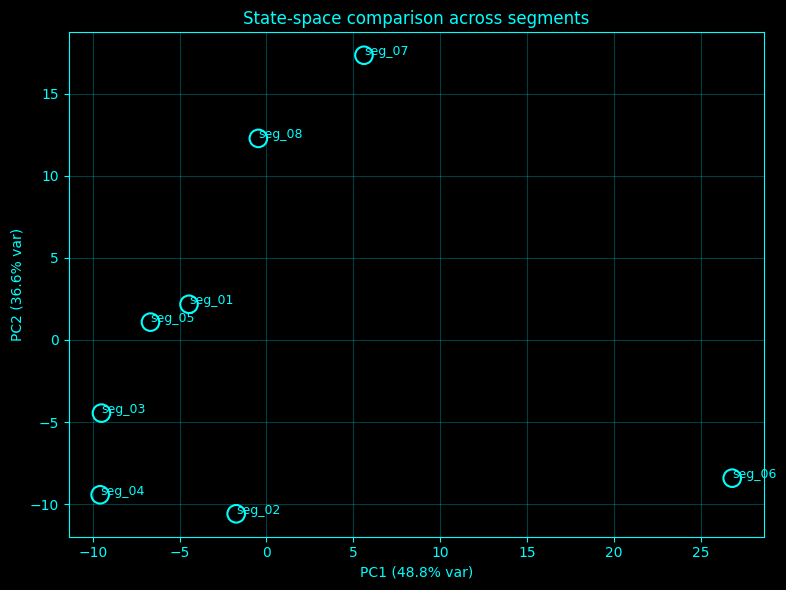

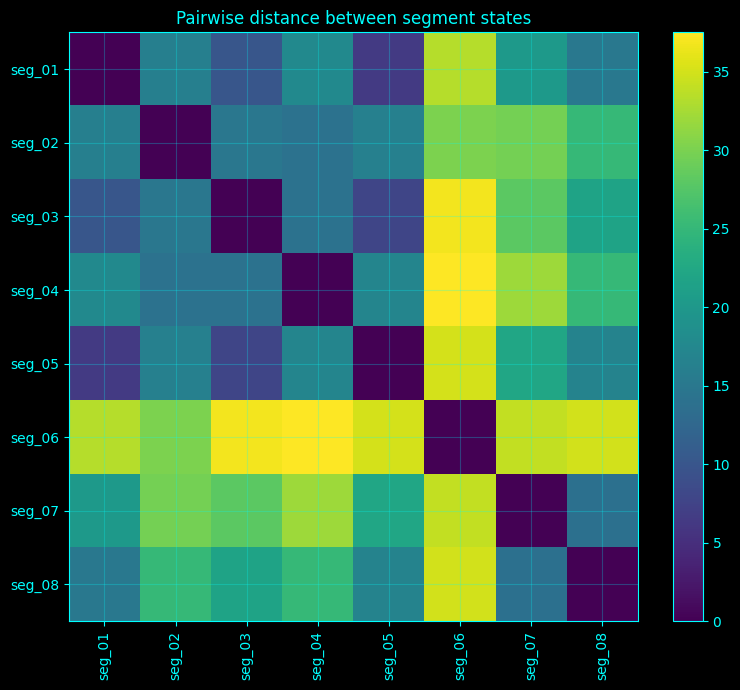

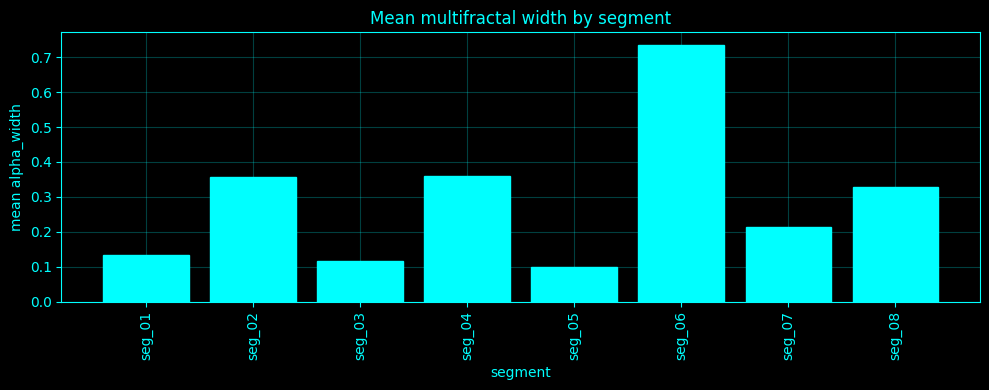

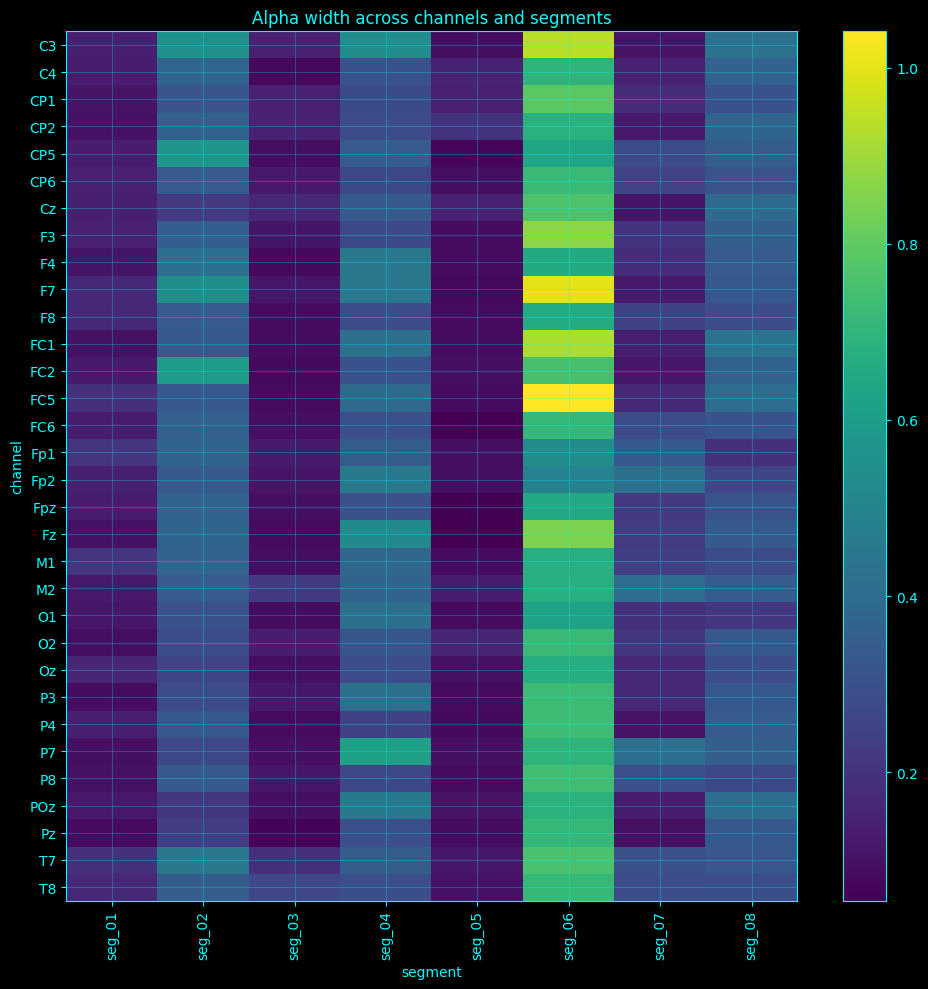

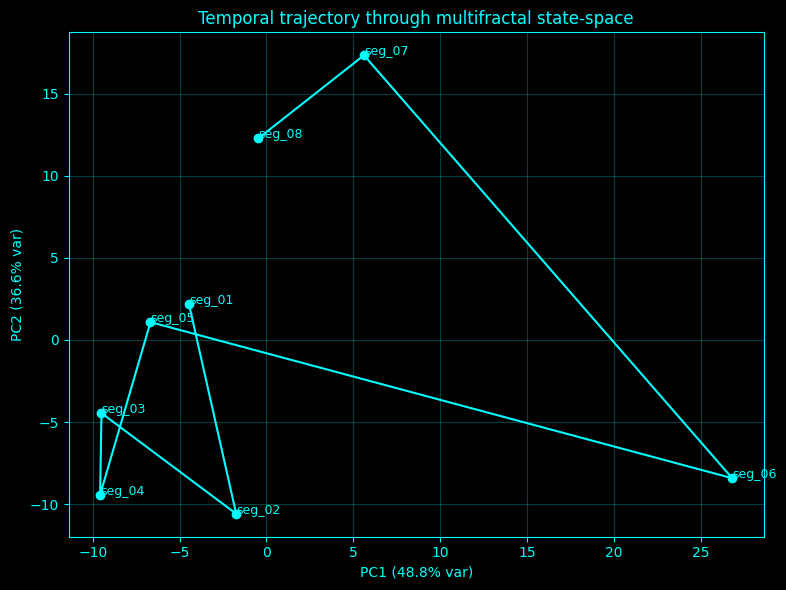


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_state_space_across_segments
Fingerprints: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_state_space_across_segments/segment_channel_fingerprints.csv
State coordinates: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_state_space_across_segments/segment_state_space_coordinates.csv
State vectors: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_state_space_across_segments/segment_state_vectors.csv
Distances: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_state_space_across_segments/segment_pairwise_distances.csv
Segment summary: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_state_space_across_segments/segment_summary_features.csv
PCA plot: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_state_space_across_segments/segment_state_space_pca.png
Distance heatmap: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_state_space_across_segments/segment_state_distance_matrix.

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_state_space_across_segments")
os.makedirs(out_dir, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

sampling_rate = 1000

# same segment duration as the one you used before
reference_start = 814.571
reference_end   = 921.515
segment_duration_sec = reference_end - reference_start

# -------------------------------------------------------
# SEGMENT SELECTION
# -------------------------------------------------------
# Option A: manually specify segments here if you want exact control
manual_segments = None
# Example:
# manual_segments = [
#     ("seg_01", 600.000, 706.944),
#     ("seg_02", 814.571, 921.515),
#     ("seg_03", 1800.000, 1906.944),
#     ("seg_04", 3000.000, 3106.944),
# ]

# Option B: automatically generate evenly spaced segments across the whole recording
n_auto_segments = 8

# -------------------------------------------------------
# MFDFA SETTINGS
# -------------------------------------------------------
q_vals = np.linspace(-5, 5, 41)
poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# fingerprint q-values
q_fingerprint_targets = [-5, -2, 0, 2, 5]

# -------------------------------------------------------
# PLOT STYLE
# -------------------------------------------------------
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# MANUAL MFDFA
# -------------------------------------------------------
def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)

    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {"tau": tau, "alpha": alpha, "f_alpha": f_alpha}

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

def nearest_q_idx(q_vals, q_target):
    return int(np.argmin(np.abs(np.asarray(q_vals, dtype=float) - q_target)))

# -------------------------------------------------------
# STATE-SPACE HELPERS
# -------------------------------------------------------
def zscore_features(X, eps=1e-12):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd)
    return (X - mu) / sd, mu, sd

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = Xc @ Vt[:2].T
    var = (S ** 2) / max(X.shape[0] - 1, 1)
    frac = var / np.sum(var)
    return scores, Vt[:2], frac[:2]

def pairwise_distance_matrix(X):
    X = np.asarray(X, dtype=float)
    sq = np.sum(X**2, axis=1, keepdims=True)
    D2 = np.maximum(sq + sq.T - 2.0 * (X @ X.T), 0.0)
    return np.sqrt(D2)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    # shape = (time, channels)
    EEG_time_major = EEG_data
elif EEG_data.shape[0] == len(eeg_channels):
    # shape = (channels, time)
    EEG_time_major = EEG_data.T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

n_samples_total, n_channels_total = EEG_time_major.shape
record_duration_sec = n_samples_total / sampling_rate
print(f"Loaded EEG: {n_samples_total} samples x {n_channels_total} channels")
print(f"Record duration: {record_duration_sec:.3f} sec")

# -------------------------------------------------------
# BUILD SEGMENT LIST
# -------------------------------------------------------
if manual_segments is not None:
    segments = manual_segments
else:
    latest_start = record_duration_sec - segment_duration_sec
    if latest_start <= 0:
        raise RuntimeError("Recording shorter than requested segment duration.")

    auto_starts = np.linspace(0, latest_start, n_auto_segments)
    segments = []
    for i, t0 in enumerate(auto_starts, start=1):
        t1 = t0 + segment_duration_sec
        label = f"seg_{i:02d}"
        if np.isclose(t0, reference_start, atol=segment_duration_sec / 4):
            label = f"seg_{i:02d}_near_reference"
        segments.append((label, float(t0), float(t1)))

print("\nSegments to analyze:")
for seg in segments:
    print(seg)

# -------------------------------------------------------
# VALID SCALES
# -------------------------------------------------------
segment_length_samples = int(round(segment_duration_sec * sampling_rate))
lag = lag[(lag > poly_order + 2) & (lag < segment_length_samples // 4)]
print("\nUsing scales:", lag)

# -------------------------------------------------------
# RUN PER SEGMENT / PER CHANNEL
# -------------------------------------------------------
channel_fingerprint_rows = []
segment_vectors = []
segment_meta_rows = []

for seg_label, t0, t1 in segments:
    i0 = int(round(t0 * sampling_rate))
    i1 = int(round(t1 * sampling_rate))

    if i0 < 0 or i1 > n_samples_total or i1 <= i0:
        print(f"Skipping invalid segment {seg_label}: [{t0}, {t1}]")
        continue

    seg = EEG_time_major[i0:i1, :]
    if seg.shape[0] < 1000:
        print(f"Skipping too-short segment {seg_label}: {seg.shape[0]} samples")
        continue

    this_vector = []

    for ch_idx, ch_name in enumerate(eeg_channels):
        x = seg[:, ch_idx].astype(float)

        scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
        hq = estimate_hq(scales_out, Fq)
        spec = compute_multifractal_spectrum(q_vals, hq)
        summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])

        h_feats = {}
        for q_target in q_fingerprint_targets:
            qi = nearest_q_idx(q_vals, q_target)
            h_feats[f"h_{str(q_target).replace('-', 'm').replace('.', 'p')}"] = hq[qi]

        row = {
            "segment": seg_label,
            "start_time": t0,
            "end_time": t1,
            "channel": ch_name,
            "alpha_width": summary["alpha_width"],
            "alpha_at_peak": summary["alpha_at_peak"],
            "asymmetry": summary["asymmetry"],
            "f_peak": summary["f_peak"],
        }
        row.update(h_feats)
        channel_fingerprint_rows.append(row)

        # fixed-order channel fingerprint for segment state vector
        feat_order = [
            row["h_m5"], row["h_m2"], row["h_0"], row["h_2"], row["h_5"],
            row["alpha_width"], row["alpha_at_peak"], row["asymmetry"]
        ]
        this_vector.extend(feat_order)

    this_vector = np.asarray(this_vector, dtype=float)
    segment_vectors.append(this_vector)

    segment_meta_rows.append({
        "segment": seg_label,
        "start_time": t0,
        "end_time": t1,
        "duration_sec": t1 - t0
    })

# -------------------------------------------------------
# SAVE CHANNEL-LEVEL FINGERPRINTS
# -------------------------------------------------------
fingerprint_df = pd.DataFrame(channel_fingerprint_rows)
fingerprint_csv = os.path.join(out_dir, "segment_channel_fingerprints.csv")
fingerprint_df.to_csv(fingerprint_csv, index=False)

print("\nChannel-level fingerprint table:")
print(fingerprint_df.head())

# -------------------------------------------------------
# BUILD SEGMENT STATE SPACE
# -------------------------------------------------------
segment_meta_df = pd.DataFrame(segment_meta_rows)
segment_matrix = np.vstack(segment_vectors)

segment_matrix_z, mu, sd = zscore_features(segment_matrix)

scores, pcs, explained = pca_2d(segment_matrix_z)
dist_mat = pairwise_distance_matrix(segment_matrix_z)

state_df = segment_meta_df.copy()
state_df["pc1"] = scores[:, 0]
state_df["pc2"] = scores[:, 1]

state_csv = os.path.join(out_dir, "segment_state_space_coordinates.csv")
state_df.to_csv(state_csv, index=False)

matrix_csv = os.path.join(out_dir, "segment_state_vectors.csv")
pd.DataFrame(segment_matrix_z, index=state_df["segment"]).to_csv(matrix_csv)

dist_csv = os.path.join(out_dir, "segment_pairwise_distances.csv")
pd.DataFrame(dist_mat, index=state_df["segment"], columns=state_df["segment"]).to_csv(dist_csv)

print("\nSegment state-space coordinates:")
print(state_df)
print("\nExplained variance (PC1, PC2):", explained)

# -------------------------------------------------------
# SEGMENT-LEVEL SUMMARY FEATURES
# -------------------------------------------------------
segment_summary_df = (
    fingerprint_df.groupby("segment")
    .agg(
        mean_alpha_width=("alpha_width", "mean"),
        std_alpha_width=("alpha_width", "std"),
        mean_asymmetry=("asymmetry", "mean"),
        std_asymmetry=("asymmetry", "std"),
        mean_h_m5=("h_m5", "mean"),
        mean_h_m2=("h_m2", "mean"),
        mean_h_0=("h_0", "mean"),
        mean_h_2=("h_2", "mean"),
        mean_h_5=("h_5", "mean"),
    )
    .reset_index()
)

segment_summary_df = segment_summary_df.merge(
    state_df[["segment", "pc1", "pc2"]],
    on="segment",
    how="left"
)

segment_summary_csv = os.path.join(out_dir, "segment_summary_features.csv")
segment_summary_df.to_csv(segment_summary_csv, index=False)

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) PCA state-space
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.scatter(
    state_df["pc1"],
    state_df["pc2"],
    s=160,
    facecolors="none",
    edgecolors=ACCENT,
    linewidths=1.5
)

for _, row in state_df.iterrows():
    ax.text(row["pc1"], row["pc2"], row["segment"], fontsize=9, color=ACCENT)

ax.set_title("State-space comparison across segments")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")

pca_path = os.path.join(out_dir, "segment_state_space_pca.png")
plt.tight_layout()
plt.savefig(pca_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 2) Pairwise distance matrix
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(dist_mat, aspect="auto")
ax.set_title("Pairwise distance between segment states")
ax.set_xticks(np.arange(len(state_df)))
ax.set_xticklabels(state_df["segment"], rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(state_df)))
ax.set_yticklabels(state_df["segment"], color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

dist_path = os.path.join(out_dir, "segment_state_distance_matrix.png")
plt.tight_layout()
plt.savefig(dist_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 3) Mean alpha width by segment
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    segment_summary_df["segment"],
    segment_summary_df["mean_alpha_width"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Mean multifractal width by segment")
ax.set_xlabel("segment")
ax.set_ylabel("mean alpha_width")
ax.tick_params(axis='x', rotation=90)

mean_width_path = os.path.join(out_dir, "mean_alpha_width_by_segment.png")
plt.tight_layout()
plt.savefig(mean_width_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 4) Channel x segment heatmap for alpha width
width_pivot = fingerprint_df.pivot_table(
    index="channel",
    columns="segment",
    values="alpha_width",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(width_pivot.values, aspect="auto")
ax.set_title("Alpha width across channels and segments")
ax.set_xlabel("segment")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(width_pivot.columns)))
ax.set_xticklabels(width_pivot.columns, rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(width_pivot.index)))
ax.set_yticklabels(width_pivot.index, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

width_heatmap_path = os.path.join(out_dir, "alpha_width_channel_segment_heatmap.png")
plt.tight_layout()
plt.savefig(width_heatmap_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 5) Segment trajectories ordered by time
state_df_sorted = state_df.sort_values("start_time").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.plot(
    state_df_sorted["pc1"],
    state_df_sorted["pc2"],
    marker='o',
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT,
    linewidth=1.5
)

for _, row in state_df_sorted.iterrows():
    ax.text(row["pc1"], row["pc2"], row["segment"], fontsize=9, color=ACCENT)

ax.set_title("Temporal trajectory through multifractal state-space")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")

traj_path = os.path.join(out_dir, "segment_state_space_trajectory.png")
plt.tight_layout()
plt.savefig(traj_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "state_space_summary.txt")
with open(txt_path, "w") as f:
    f.write("State-space comparison across segments\n")
    f.write("====================================\n\n")
    f.write(f"Segment duration (sec): {segment_duration_sec:.6f}\n")
    f.write(f"Number of segments analyzed: {len(state_df)}\n")
    f.write(f"Explained variance PC1: {explained[0]:.6f}\n")
    f.write(f"Explained variance PC2: {explained[1]:.6f}\n\n")

    f.write("Segments:\n")
    for _, row in state_df.sort_values('start_time').iterrows():
        f.write(
            f"{row['segment']}: [{row['start_time']:.3f}, {row['end_time']:.3f}] "
            f"-> PC1={row['pc1']:.6f}, PC2={row['pc2']:.6f}\n"
        )

print("\nSaved outputs to:", out_dir)
print("Fingerprints:", fingerprint_csv)
print("State coordinates:", state_csv)
print("State vectors:", matrix_csv)
print("Distances:", dist_csv)
print("Segment summary:", segment_summary_csv)
print("PCA plot:", pca_path)
print("Distance heatmap:", dist_path)
print("Width heatmap:", width_heatmap_path)
print("Trajectory plot:", traj_path)
print("Summary text:", txt_path)

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [    5     6     8    10    14    18    24    31    40    52    68    89
   116   151   196   255   331   431   560   727   945  1229  1597  2076
  2697  3506  4556  5921  7694 10000]

Bandwise summary:
  channel       band  f_lo  f_hi  alpha_min  alpha_max  alpha_width  \
0     Fp1      delta   1.0   4.0   1.017071   2.229292     1.212222   
1     Fp1      theta   4.0   8.0   0.635381   2.017994     1.382613   
2     Fp1      alpha   8.0  13.0   0.434691   1.629618     1.194927   
3     Fp1       beta  13.0  30.0   0.163660   1.312979     1.149319   
4     Fp1  low_gamma  30.0  80.0   0.050448   0.585019     0.534571   

   alpha_at_peak  f_peak  asymmetry      h_m5       h_0      h_p5  
0       1.391106     1.0   0.464150  1.983861  1.389266  1.109829  
1       1.005493     1.0   0.642388  1.723648  1.003950  0.740895  
2       0.753762     1.0   0.556785  1.347958  0.752448  0.552329  
3  

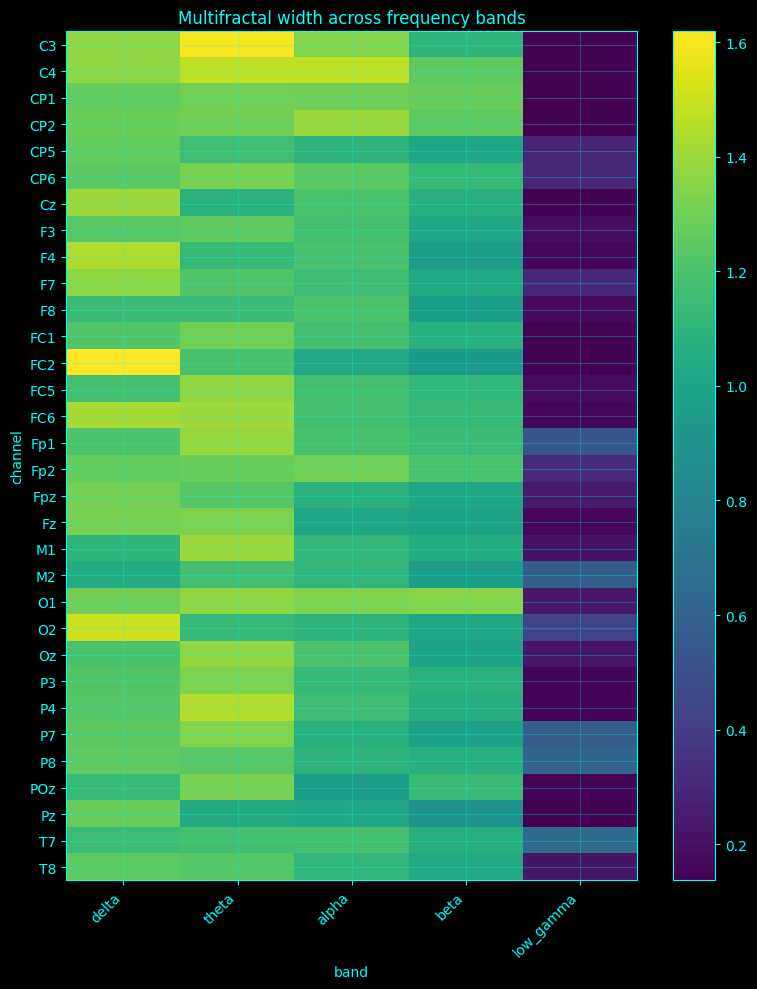

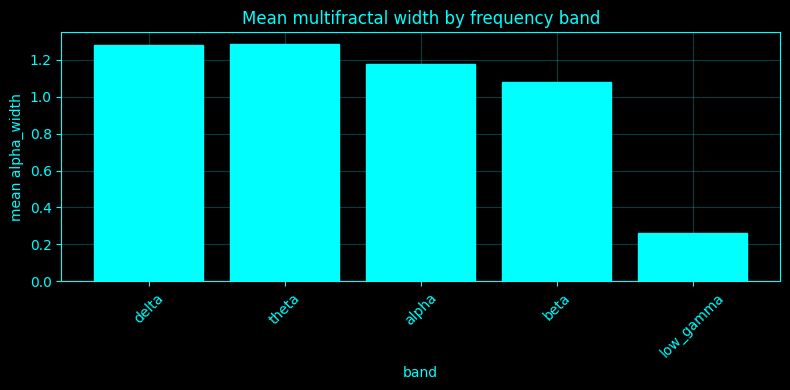

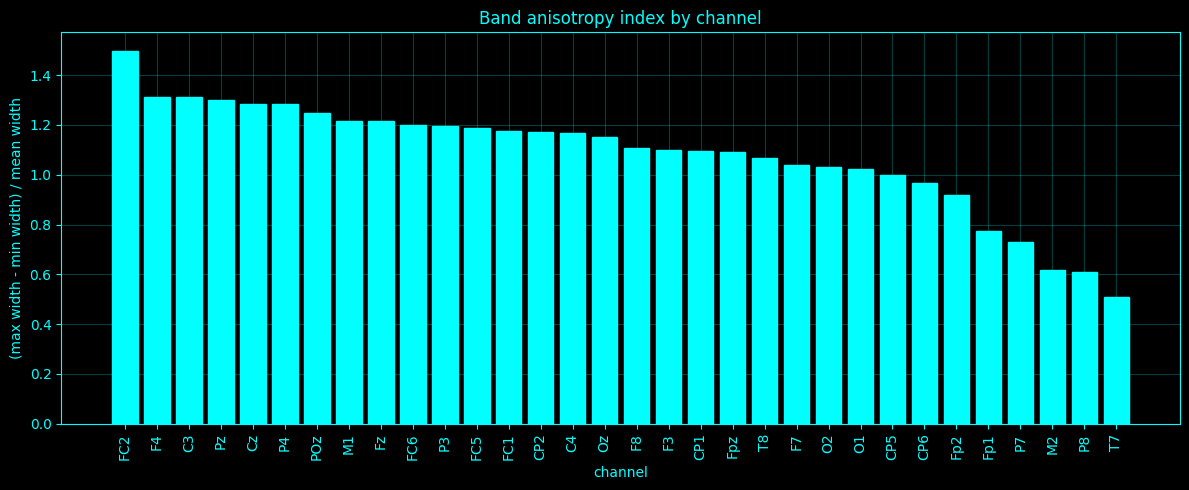

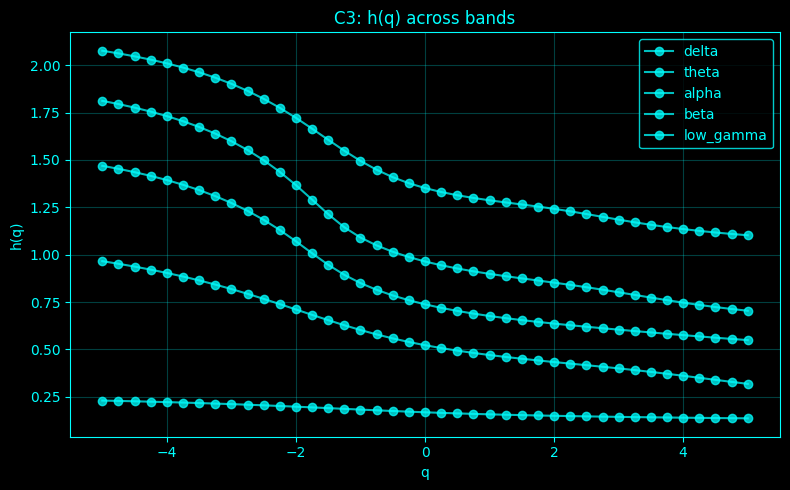

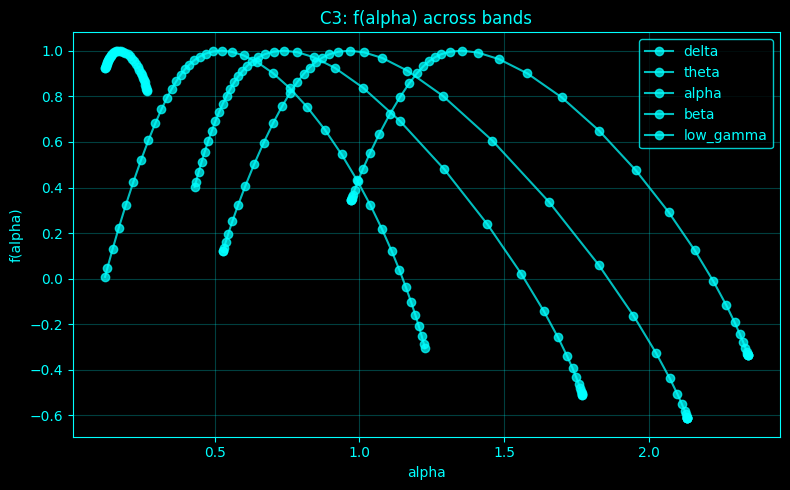


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_frequency_band_anisotropy
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_frequency_band_anisotropy/bandwise_mfdfa_summary.csv
Saved anisotropy CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_frequency_band_anisotropy/band_anisotropy_summary.csv
Saved summary text: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_frequency_band_anisotropy/frequency_band_anisotropy_summary.txt


In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_frequency_band_anisotropy")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Frequency bands
bands = {
    "delta":     (1.0, 4.0),
    "theta":     (4.0, 8.0),
    "alpha":     (8.0, 13.0),
    "beta":      (13.0, 30.0),
    "low_gamma": (30.0, 80.0),
}

# MFDFA settings
q_vals = np.linspace(-5, 5, 41)
poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# For one example channel, save extra detailed band plots
example_channel = "C3"

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# SIGNAL HELPERS
# -------------------------------------------------------
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def fft_bandpass(x, fs, f_lo, f_hi):
    """
    Zero-phase FFT-domain bandpass without external filtering libraries.
    Keeps only frequencies in [f_lo, f_hi).
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    x0 = x - np.mean(x)

    X = np.fft.rfft(x0)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)

    mask = (freqs >= f_lo) & (freqs < f_hi)
    Y = np.zeros_like(X)
    Y[mask] = X[mask]

    y = np.fft.irfft(Y, n=n)
    return y

# -------------------------------------------------------
# MANUAL MFDFA
# -------------------------------------------------------
def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)

    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {
        "tau": tau,
        "alpha": alpha,
        "f_alpha": f_alpha,
    }

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

# -------------------------------------------------------
# RUN MFDFA PER BAND PER CHANNEL
# -------------------------------------------------------
summary_rows = []
example_band_curves = {}

for ch_idx, ch_name in enumerate(eeg_channels):
    x_raw = EEG_segment[:, ch_idx].astype(float)

    for band_name, (f_lo, f_hi) in bands.items():
        x_band = fft_bandpass(x_raw, sampling_rate, f_lo, f_hi)
        x_band = standardize_1d(x_band)

        scales_out, Fq = mfdfa_manual(x_band, lag, q_vals, order=poly_order)
        hq = estimate_hq(scales_out, Fq)
        spec = compute_multifractal_spectrum(q_vals, hq)
        summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])

        qi_m5 = int(np.argmin(np.abs(q_vals - (-5))))
        qi_0  = int(np.argmin(np.abs(q_vals - 0)))
        qi_p5 = int(np.argmin(np.abs(q_vals - 5)))

        row = {
            "channel": ch_name,
            "band": band_name,
            "f_lo": f_lo,
            "f_hi": f_hi,
            "alpha_min": summary["alpha_min"],
            "alpha_max": summary["alpha_max"],
            "alpha_width": summary["alpha_width"],
            "alpha_at_peak": summary["alpha_at_peak"],
            "f_peak": summary["f_peak"],
            "asymmetry": summary["asymmetry"],
            "h_m5": hq[qi_m5],
            "h_0": hq[qi_0],
            "h_p5": hq[qi_p5],
        }
        summary_rows.append(row)

        if ch_name == example_channel:
            example_band_curves[band_name] = {
                "q_vals": q_vals.copy(),
                "hq": hq.copy(),
                "alpha": spec["alpha"].copy(),
                "f_alpha": spec["f_alpha"].copy(),
            }

        # save per-channel-per-band numerical output
        npz_path = os.path.join(out_dir, f"{ch_name}_{band_name}_mfdfa_band.npz")
        np.savez(
            npz_path,
            channel=ch_name,
            band=band_name,
            f_lo=f_lo,
            f_hi=f_hi,
            start_time=start_time,
            end_time=end_time,
            sampling_rate=sampling_rate,
            scales=scales_out,
            q_vals=q_vals,
            Fq=Fq,
            hq=hq,
            alpha=spec["alpha"],
            f_alpha=spec["f_alpha"],
            alpha_min=summary["alpha_min"],
            alpha_max=summary["alpha_max"],
            alpha_width=summary["alpha_width"],
            alpha_at_peak=summary["alpha_at_peak"],
            f_peak=summary["f_peak"],
            asymmetry=summary["asymmetry"],
        )

# -------------------------------------------------------
# SAVE MAIN SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "bandwise_mfdfa_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nBandwise summary:")
print(summary_df.head())

# -------------------------------------------------------
# ANISOTROPY SUMMARY PER CHANNEL
# -------------------------------------------------------
anisotropy_rows = []

for ch_name in eeg_channels:
    sub = summary_df[summary_df["channel"] == ch_name].copy()
    if len(sub) == 0:
        continue

    sub = sub.sort_values("band")
    widths = sub["alpha_width"].to_numpy(dtype=float)

    max_idx = int(np.nanargmax(widths))
    min_idx = int(np.nanargmin(widths))

    max_band = sub.iloc[max_idx]["band"]
    min_band = sub.iloc[min_idx]["band"]

    width_max = float(np.nanmax(widths))
    width_min = float(np.nanmin(widths))
    width_mean = float(np.nanmean(widths))
    width_std = float(np.nanstd(widths))
    width_range = width_max - width_min
    anisotropy_index = width_range / max(width_mean, 1e-12)

    asym_vals = sub["asymmetry"].to_numpy(dtype=float)

    anisotropy_rows.append({
        "channel": ch_name,
        "preferred_band_max_width": max_band,
        "weakest_band_min_width": min_band,
        "width_max": width_max,
        "width_min": width_min,
        "width_mean": width_mean,
        "width_std": width_std,
        "width_range": width_range,
        "anisotropy_index": anisotropy_index,
        "mean_asymmetry_across_bands": float(np.nanmean(asym_vals)),
        "std_asymmetry_across_bands": float(np.nanstd(asym_vals)),
    })

anisotropy_df = pd.DataFrame(anisotropy_rows).sort_values("anisotropy_index", ascending=False)
anisotropy_csv = os.path.join(out_dir, "band_anisotropy_summary.csv")
anisotropy_df.to_csv(anisotropy_csv, index=False)

print("\nBand anisotropy summary:")
print(anisotropy_df)

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Heatmap of alpha width across channels and bands
width_pivot = summary_df.pivot_table(
    index="channel",
    columns="band",
    values="alpha_width",
    aggfunc="mean"
)

band_order = list(bands.keys())
width_pivot = width_pivot.reindex(columns=band_order)

fig, ax = plt.subplots(figsize=(8, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(width_pivot.values, aspect="auto")
ax.set_title("Multifractal width across frequency bands")
ax.set_xlabel("band")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(width_pivot.columns)))
ax.set_xticklabels(width_pivot.columns, rotation=45, ha="right", color=ACCENT)
ax.set_yticks(np.arange(len(width_pivot.index)))
ax.set_yticklabels(width_pivot.index, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

heatmap_path = os.path.join(out_dir, "alpha_width_band_heatmap.png")
plt.tight_layout()
plt.savefig(heatmap_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 2) Mean alpha width by band
band_mean_df = summary_df.groupby("band")["alpha_width"].mean().reindex(band_order).reset_index()

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    band_mean_df["band"],
    band_mean_df["alpha_width"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Mean multifractal width by frequency band")
ax.set_xlabel("band")
ax.set_ylabel("mean alpha_width")
ax.tick_params(axis='x', rotation=45)

band_mean_path = os.path.join(out_dir, "mean_alpha_width_by_band.png")
plt.tight_layout()
plt.savefig(band_mean_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 3) Channel anisotropy index
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    anisotropy_df["channel"],
    anisotropy_df["anisotropy_index"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Band anisotropy index by channel")
ax.set_xlabel("channel")
ax.set_ylabel("(max width - min width) / mean width")
ax.tick_params(axis='x', rotation=90)

anisotropy_bar_path = os.path.join(out_dir, "band_anisotropy_index_by_channel.png")
plt.tight_layout()
plt.savefig(anisotropy_bar_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 4) Example channel: h(q) across bands
if example_channel in eeg_channels and len(example_band_curves) > 0:
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
    style_ax(ax)

    for band_name in band_order:
        if band_name not in example_band_curves:
            continue
        ax.plot(
            example_band_curves[band_name]["q_vals"],
            example_band_curves[band_name]["hq"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.75,
            label=band_name
        )

    ax.set_title(f"{example_channel}: h(q) across bands")
    ax.set_xlabel("q")
    ax.set_ylabel("h(q)")
    ax.legend()

    hq_example_path = os.path.join(out_dir, f"{example_channel}_hq_across_bands.png")
    plt.tight_layout()
    plt.savefig(hq_example_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    # 5) Example channel: f(alpha) across bands
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
    style_ax(ax)

    for band_name in band_order:
        if band_name not in example_band_curves:
            continue
        alpha = example_band_curves[band_name]["alpha"]
        f_alpha = example_band_curves[band_name]["f_alpha"]
        mask = np.isfinite(alpha) & np.isfinite(f_alpha)

        ax.plot(
            alpha[mask],
            f_alpha[mask],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.75,
            label=band_name
        )

    ax.set_title(f"{example_channel}: f(alpha) across bands")
    ax.set_xlabel("alpha")
    ax.set_ylabel("f(alpha)")
    ax.legend()

    falpha_example_path = os.path.join(out_dir, f"{example_channel}_falpha_across_bands.png")
    plt.tight_layout()
    plt.savefig(falpha_example_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "frequency_band_anisotropy_summary.txt")
with open(txt_path, "w") as f:
    f.write("Multifractal anisotropy across frequency bands\n")
    f.write("=============================================\n\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write("Bands:\n")
    for name, (lo, hi) in bands.items():
        f.write(f"  {name}: {lo}-{hi} Hz\n")

    f.write("\nTop anisotropic channels:\n")
    for _, row in anisotropy_df.head(10).iterrows():
        f.write(
            f"{row['channel']}: index={row['anisotropy_index']:.6f}, "
            f"max_band={row['preferred_band_max_width']}, "
            f"min_band={row['weakest_band_min_width']}\n"
        )

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved anisotropy CSV: {anisotropy_csv}")
print(f"Saved summary text: {txt_path}")

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [    5     6     8    10    14    18    24    31    40    52    68    89
   116   151   196   255   331   431   560   727   945  1229  1597  2076
  2697  3506  4556  5921  7694 10000]

Residual-MFDFA summary:
   channel  n_detected_peaks        peak_freqs_hz  raw_alpha_width  \
0      Fp1                 3   60.003,2.441,4.601         0.152990   
1      Fpz                 3   60.003,2.441,4.601         0.136676   
2      Fp2                 3   60.003,1.926,4.096         0.146259   
3       F7                 3  60.003,1.216,38.815         0.071342   
4       F3                 3  60.003,16.784,1.253         0.071160   
5       Fz                 3  60.003,1.113,10.323         0.103202   
6       F4                 3  60.003,1.113,10.323         0.113358   
7       F8                 3  60.003,1.664,10.894         0.074105   
8      FC5                 3  60.003,1.206,38.815         0.078799

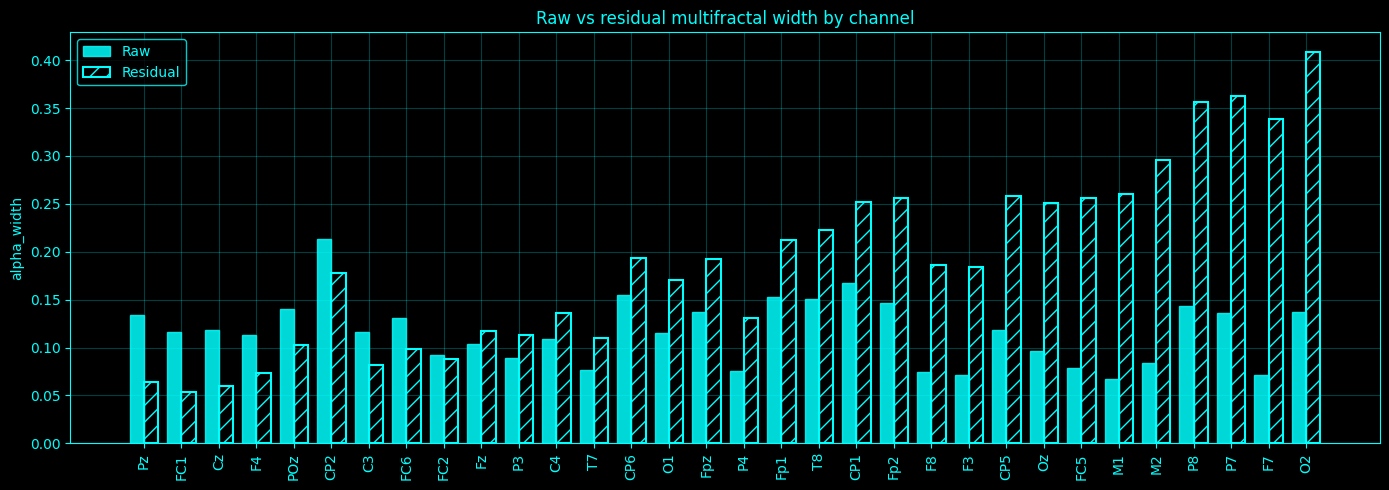

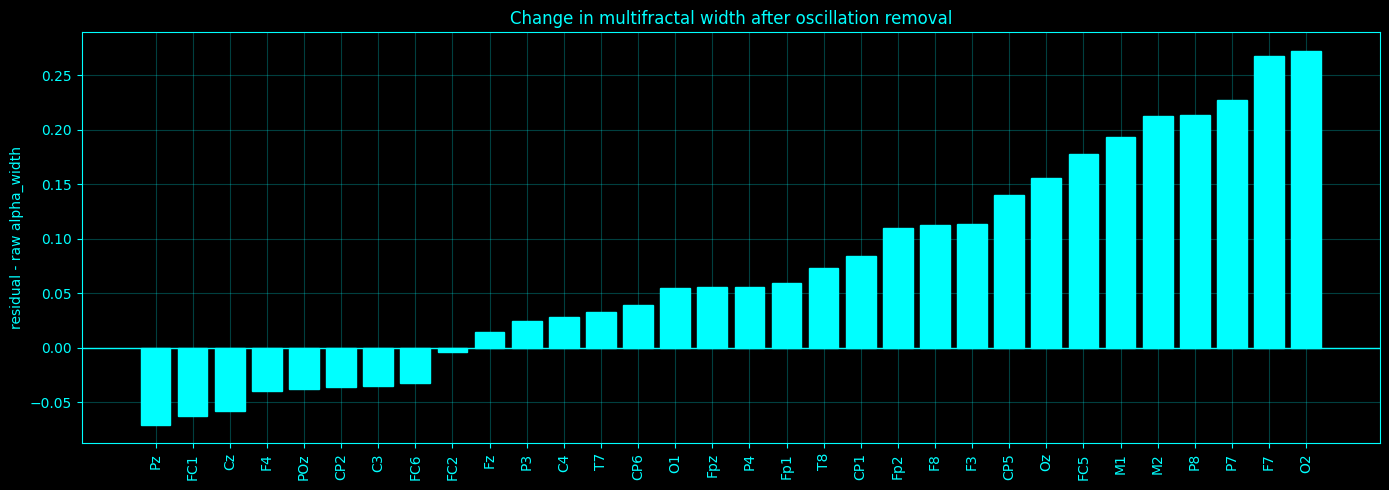

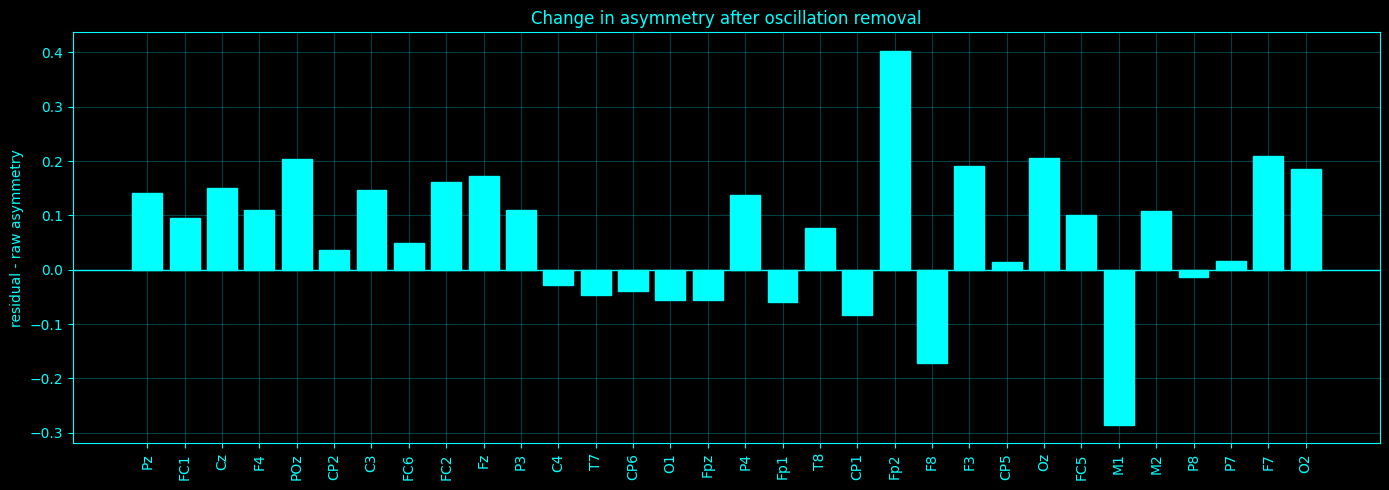

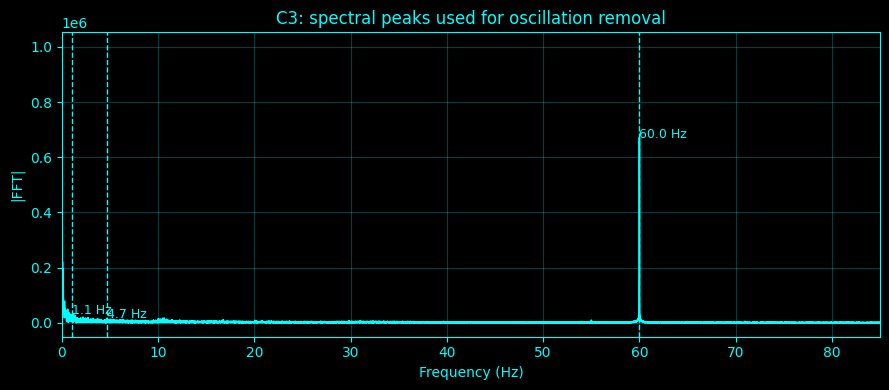

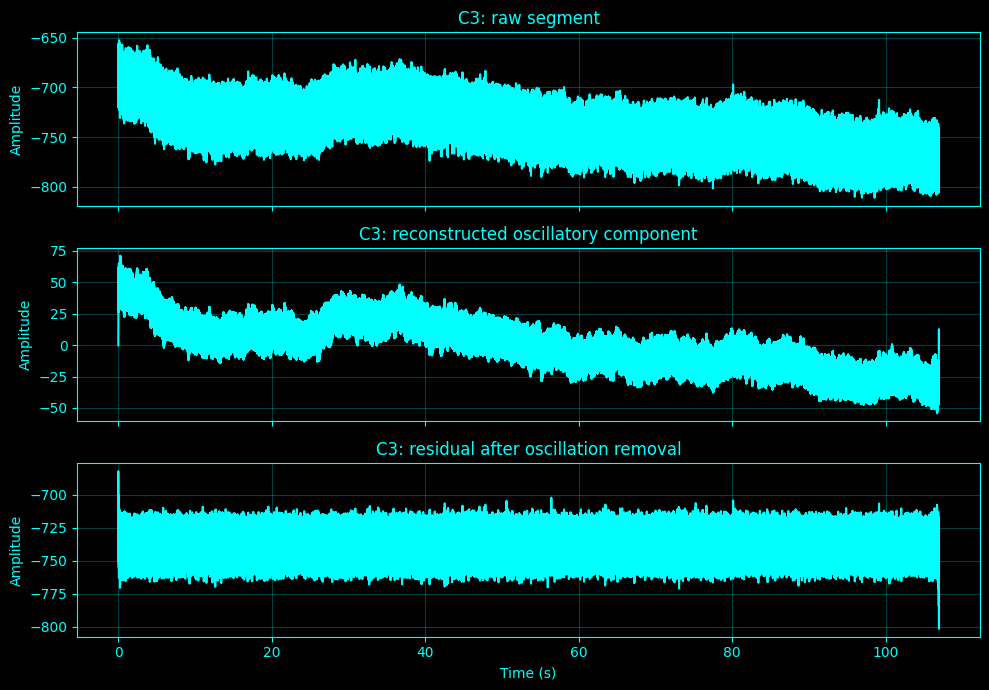

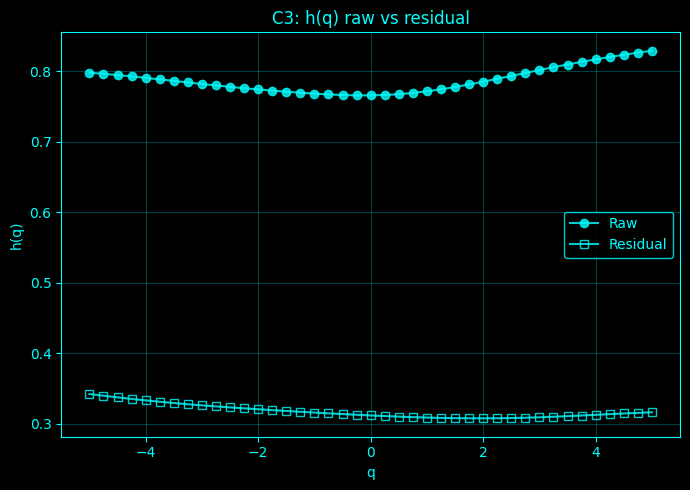

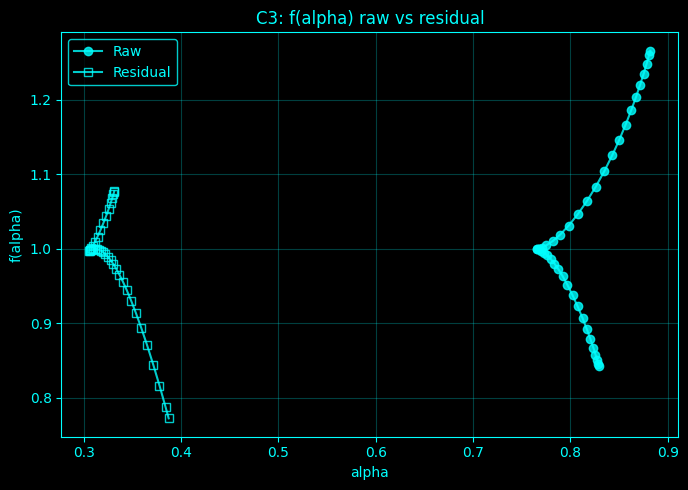


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_residual_after_oscillation_removal
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_residual_after_oscillation_removal/raw_vs_residual_mfdfa_summary.csv
Saved summary text: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_residual_after_oscillation_removal/residual_mfdfa_summary.txt


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_residual_after_oscillation_removal")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# MFDFA settings
q_vals = np.linspace(-5, 5, 41)
poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# Oscillation-removal settings
peak_search_fmin = 1.0
peak_search_fmax = 80.0
n_osc_peaks = 3
peak_half_width_hz = 1.5
min_peak_separation_hz = 2.0

# Example channel for detailed figures
example_channel = "C3"

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# BASIC HELPERS
# -------------------------------------------------------
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    k = np.ones(w, dtype=float) / w
    return np.convolve(x, k, mode="same")

# -------------------------------------------------------
# MANUAL SPECTRAL PEAK DETECTION
# -------------------------------------------------------
def find_spectral_peaks(x, fs, fmin=1.0, fmax=80.0, n_peaks=3, min_sep_hz=2.0):
    """
    Find strongest local maxima in the magnitude spectrum after removing a smooth baseline.
    """
    x = np.asarray(x, dtype=float)
    x0 = x - np.mean(x)

    X = np.fft.rfft(x0)
    freqs = np.fft.rfftfreq(len(x0), d=1.0/fs)
    mag = np.abs(X)

    # restrict search region
    valid = (freqs >= fmin) & (freqs <= fmax)
    idx_valid = np.where(valid)[0]
    if len(idx_valid) < 5:
        return freqs, mag, []

    mag_valid = mag.copy()
    baseline = moving_average(mag_valid, 21)
    peak_score = np.maximum(mag_valid - baseline, 0.0)

    # simple local maxima
    local_max_idx = []
    for i in idx_valid[1:-1]:
        if peak_score[i] > peak_score[i-1] and peak_score[i] >= peak_score[i+1]:
            local_max_idx.append(i)

    if len(local_max_idx) == 0:
        return freqs, mag, []

    local_max_idx = np.array(local_max_idx, dtype=int)

    # sort by peak score descending
    order = np.argsort(peak_score[local_max_idx])[::-1]

    selected = []
    selected_freqs = []

    for oi in order:
        idx = local_max_idx[oi]
        f = freqs[idx]

        too_close = any(abs(f - sf) < min_sep_hz for sf in selected_freqs)
        if too_close:
            continue

        selected.append({
            "idx": int(idx),
            "freq": float(f),
            "magnitude": float(mag[idx]),
            "score": float(peak_score[idx]),
        })
        selected_freqs.append(float(f))

        if len(selected) >= n_peaks:
            break

    return freqs, mag, selected

def reconstruct_oscillatory_component(x, fs, peaks, half_width_hz=1.5):
    """
    Reconstruct oscillatory component by keeping only narrow spectral neighborhoods
    around detected peaks.
    """
    x = np.asarray(x, dtype=float)
    x_mean = np.mean(x)
    x0 = x - x_mean

    X = np.fft.rfft(x0)
    freqs = np.fft.rfftfreq(len(x0), d=1.0/fs)

    Y = np.zeros_like(X)

    for pk in peaks:
        f0 = pk["freq"]
        band_mask = np.abs(freqs - f0) <= half_width_hz
        Y[band_mask] = X[band_mask]

    y = np.fft.irfft(Y, n=len(x0))
    return y

# -------------------------------------------------------
# MANUAL MFDFA
# -------------------------------------------------------
def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)

    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {"tau": tau, "alpha": alpha, "f_alpha": f_alpha}

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

# -------------------------------------------------------
# RUN RAW VS RESIDUAL MFDFA
# -------------------------------------------------------
summary_rows = []
example_store = {}

for ch_idx, ch_name in enumerate(eeg_channels):
    x_raw = EEG_segment[:, ch_idx].astype(float)

    # detect oscillatory peaks
    freqs, mag, peaks = find_spectral_peaks(
        x_raw,
        sampling_rate,
        fmin=peak_search_fmin,
        fmax=peak_search_fmax,
        n_peaks=n_osc_peaks,
        min_sep_hz=min_peak_separation_hz
    )

    # reconstruct oscillatory component
    x_osc = reconstruct_oscillatory_component(
        x_raw,
        sampling_rate,
        peaks,
        half_width_hz=peak_half_width_hz
    )

    # residual after removing oscillatory component
    x_resid = x_raw - x_osc

    # standardized versions for MFDFA comparison
    x_raw_z = standardize_1d(x_raw)
    x_resid_z = standardize_1d(x_resid)

    # raw MFDFA
    scales_raw, Fq_raw = mfdfa_manual(x_raw_z, lag, q_vals, order=poly_order)
    hq_raw = estimate_hq(scales_raw, Fq_raw)
    spec_raw = compute_multifractal_spectrum(q_vals, hq_raw)
    sum_raw = summarize_spectrum(spec_raw["alpha"], spec_raw["f_alpha"])

    # residual MFDFA
    scales_res, Fq_res = mfdfa_manual(x_resid_z, lag, q_vals, order=poly_order)
    hq_res = estimate_hq(scales_res, Fq_res)
    spec_res = compute_multifractal_spectrum(q_vals, hq_res)
    sum_res = summarize_spectrum(spec_res["alpha"], spec_res["f_alpha"])

    row = {
        "channel": ch_name,
        "n_detected_peaks": len(peaks),
        "peak_freqs_hz": ",".join([f"{p['freq']:.3f}" for p in peaks]) if len(peaks) > 0 else "",
        "raw_alpha_width": sum_raw["alpha_width"],
        "resid_alpha_width": sum_res["alpha_width"],
        "delta_alpha_width": sum_res["alpha_width"] - sum_raw["alpha_width"],
        "raw_alpha_at_peak": sum_raw["alpha_at_peak"],
        "resid_alpha_at_peak": sum_res["alpha_at_peak"],
        "delta_alpha_at_peak": sum_res["alpha_at_peak"] - sum_raw["alpha_at_peak"],
        "raw_asymmetry": sum_raw["asymmetry"],
        "resid_asymmetry": sum_res["asymmetry"],
        "delta_asymmetry": sum_res["asymmetry"] - sum_raw["asymmetry"],
        "raw_f_peak": sum_raw["f_peak"],
        "resid_f_peak": sum_res["f_peak"],
    }
    summary_rows.append(row)

    # save numerical outputs
    npz_path = os.path.join(out_dir, f"{ch_name}_raw_vs_residual_mfdfa.npz")
    np.savez(
        npz_path,
        channel=ch_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        peak_search_fmin=peak_search_fmin,
        peak_search_fmax=peak_search_fmax,
        n_osc_peaks=n_osc_peaks,
        peak_half_width_hz=peak_half_width_hz,
        peak_freqs=np.array([p["freq"] for p in peaks], dtype=float),
        x_raw=x_raw,
        x_osc=x_osc,
        x_resid=x_resid,
        q_vals=q_vals,
        scales=scales_raw,
        hq_raw=hq_raw,
        hq_resid=hq_res,
        alpha_raw=spec_raw["alpha"],
        f_alpha_raw=spec_raw["f_alpha"],
        alpha_resid=spec_res["alpha"],
        f_alpha_resid=spec_res["f_alpha"],
        raw_alpha_width=sum_raw["alpha_width"],
        resid_alpha_width=sum_res["alpha_width"],
        raw_asymmetry=sum_raw["asymmetry"],
        resid_asymmetry=sum_res["asymmetry"],
    )

    if ch_name == example_channel:
        example_store = {
            "freqs": freqs,
            "mag": mag,
            "peaks": peaks,
            "x_raw": x_raw,
            "x_osc": x_osc,
            "x_resid": x_resid,
            "hq_raw": hq_raw,
            "hq_res": hq_res,
            "alpha_raw": spec_raw["alpha"],
            "f_alpha_raw": spec_raw["f_alpha"],
            "alpha_res": spec_res["alpha"],
            "f_alpha_res": spec_res["f_alpha"],
        }

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "raw_vs_residual_mfdfa_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nResidual-MFDFA summary:")
print(summary_df)

# -------------------------------------------------------
# ACROSS-CHANNEL PLOTS
# -------------------------------------------------------

# 1) raw vs residual alpha width
plot_df = summary_df.sort_values("delta_alpha_width")
x = np.arange(len(plot_df))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    x - w/2,
    plot_df["raw_alpha_width"],
    width=w,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85,
    label="Raw"
)
ax.bar(
    x + w/2,
    plot_df["resid_alpha_width"],
    width=w,
    color="none",
    edgecolor=ACCENT,
    hatch="//",
    linewidth=1.5,
    label="Residual"
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["channel"], rotation=90)
ax.set_ylabel("alpha_width")
ax.set_title("Raw vs residual multifractal width by channel")
ax.legend()

bar_path = os.path.join(out_dir, "raw_vs_residual_alpha_width.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 2) delta alpha width by channel
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    plot_df["channel"],
    plot_df["delta_alpha_width"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(0, color=ACCENT, linewidth=1.0)
ax.set_ylabel("residual - raw alpha_width")
ax.set_title("Change in multifractal width after oscillation removal")
ax.tick_params(axis='x', rotation=90)

delta_path = os.path.join(out_dir, "delta_alpha_width_after_oscillation_removal.png")
plt.tight_layout()
plt.savefig(delta_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 3) delta asymmetry by channel
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    plot_df["channel"],
    plot_df["delta_asymmetry"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(0, color=ACCENT, linewidth=1.0)
ax.set_ylabel("residual - raw asymmetry")
ax.set_title("Change in asymmetry after oscillation removal")
ax.tick_params(axis='x', rotation=90)

delta_asym_path = os.path.join(out_dir, "delta_asymmetry_after_oscillation_removal.png")
plt.tight_layout()
plt.savefig(delta_asym_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# EXAMPLE CHANNEL PLOTS
# -------------------------------------------------------
if len(example_store) > 0:
    # 1) spectrum with marked peaks
    fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)
    style_ax(ax)

    ax.plot(example_store["freqs"], example_store["mag"], color=ACCENT, linewidth=1.2)

    for pk in example_store["peaks"]:
        ax.axvline(pk["freq"], color=ACCENT, linestyle="--", linewidth=1.0)
        ax.text(pk["freq"], pk["magnitude"], f"{pk['freq']:.1f} Hz", color=ACCENT, fontsize=9)

    ax.set_xlim(0, peak_search_fmax + 5)
    ax.set_title(f"{example_channel}: spectral peaks used for oscillation removal")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("|FFT|")

    spec_path = os.path.join(out_dir, f"{example_channel}_spectral_peaks.png")
    plt.tight_layout()
    plt.savefig(spec_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    # 2) raw / oscillatory / residual traces
    t = np.arange(len(example_store["x_raw"])) / sampling_rate

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), facecolor=BG, sharex=True)
    for ax in axes:
        style_ax(ax)

    axes[0].plot(t, example_store["x_raw"], color=ACCENT)
    axes[0].set_title(f"{example_channel}: raw segment")
    axes[0].set_ylabel("Amplitude")

    axes[1].plot(t, example_store["x_osc"], color=ACCENT)
    axes[1].set_title(f"{example_channel}: reconstructed oscillatory component")
    axes[1].set_ylabel("Amplitude")

    axes[2].plot(t, example_store["x_resid"], color=ACCENT)
    axes[2].set_title(f"{example_channel}: residual after oscillation removal")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("Amplitude")

    traces_path = os.path.join(out_dir, f"{example_channel}_raw_osc_residual_traces.png")
    plt.tight_layout()
    plt.savefig(traces_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    # 3) h(q): raw vs residual
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    ax.plot(
        q_vals, example_store["hq_raw"],
        marker='o',
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.8,
        label="Raw"
    )
    ax.plot(
        q_vals, example_store["hq_res"],
        marker='s',
        color=ACCENT,
        markerfacecolor="none",
        markeredgecolor=ACCENT,
        alpha=0.8,
        label="Residual"
    )

    ax.set_title(f"{example_channel}: h(q) raw vs residual")
    ax.set_xlabel("q")
    ax.set_ylabel("h(q)")
    ax.legend()

    hq_path = os.path.join(out_dir, f"{example_channel}_hq_raw_vs_residual.png")
    plt.tight_layout()
    plt.savefig(hq_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    # 4) f(alpha): raw vs residual
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    mask_raw = np.isfinite(example_store["alpha_raw"]) & np.isfinite(example_store["f_alpha_raw"])
    mask_res = np.isfinite(example_store["alpha_res"]) & np.isfinite(example_store["f_alpha_res"])

    ax.plot(
        example_store["alpha_raw"][mask_raw],
        example_store["f_alpha_raw"][mask_raw],
        marker='o',
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.8,
        label="Raw"
    )
    ax.plot(
        example_store["alpha_res"][mask_res],
        example_store["f_alpha_res"][mask_res],
        marker='s',
        color=ACCENT,
        markerfacecolor="none",
        markeredgecolor=ACCENT,
        alpha=0.8,
        label="Residual"
    )

    ax.set_title(f"{example_channel}: f(alpha) raw vs residual")
    ax.set_xlabel("alpha")
    ax.set_ylabel("f(alpha)")
    ax.legend()

    falpha_path = os.path.join(out_dir, f"{example_channel}_falpha_raw_vs_residual.png")
    plt.tight_layout()
    plt.savefig(falpha_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "residual_mfdfa_summary.txt")
with open(txt_path, "w") as f:
    f.write("Residual-MFDFA after removing oscillatory structure\n")
    f.write("==================================================\n\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Peak search range: {peak_search_fmin}-{peak_search_fmax} Hz\n")
    f.write(f"Number of oscillatory peaks removed: {n_osc_peaks}\n")
    f.write(f"Half-width per removed peak: {peak_half_width_hz} Hz\n\n")

    f.write("Top channels with largest alpha-width decrease after oscillation removal:\n")
    tmp = summary_df.sort_values("delta_alpha_width").head(10)
    for _, row in tmp.iterrows():
        f.write(
            f"{row['channel']}: raw={row['raw_alpha_width']:.6f}, "
            f"resid={row['resid_alpha_width']:.6f}, "
            f"delta={row['delta_alpha_width']:.6f}, "
            f"peaks=[{row['peak_freqs_hz']}]\n"
        )

    f.write("\nTop channels with largest alpha-width increase after oscillation removal:\n")
    tmp = summary_df.sort_values("delta_alpha_width", ascending=False).head(10)
    for _, row in tmp.iterrows():
        f.write(
            f"{row['channel']}: raw={row['raw_alpha_width']:.6f}, "
            f"resid={row['resid_alpha_width']:.6f}, "
            f"delta={row['delta_alpha_width']:.6f}, "
            f"peaks=[{row['peak_freqs_hz']}]\n"
        )

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved summary text: {txt_path}")

Loaded baseline: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_manual_spectrum_results/mfdfa_manual_spectrum_summary.csv
Loaded qrange: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_qrange_sensitivity/qrange_sensitivity_summary.csv
Loaded negative-q: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_negative_q_stability/negative_q_stability_summary.csv
Loaded positive-q: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_positive_q_dominance/positive_q_dominance_summary.csv
Loaded asymmetry: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_asymmetry_decomposition/asymmetry_decomposition_table.csv
Loaded peaklock: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_peak_locking_analysis/channel_peak_lock_rates_across_studies.csv
Loaded crossover: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_crossover_detection/crossover_detection_summary.csv
Loaded band anisotropy: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_frequency_band_anisotr

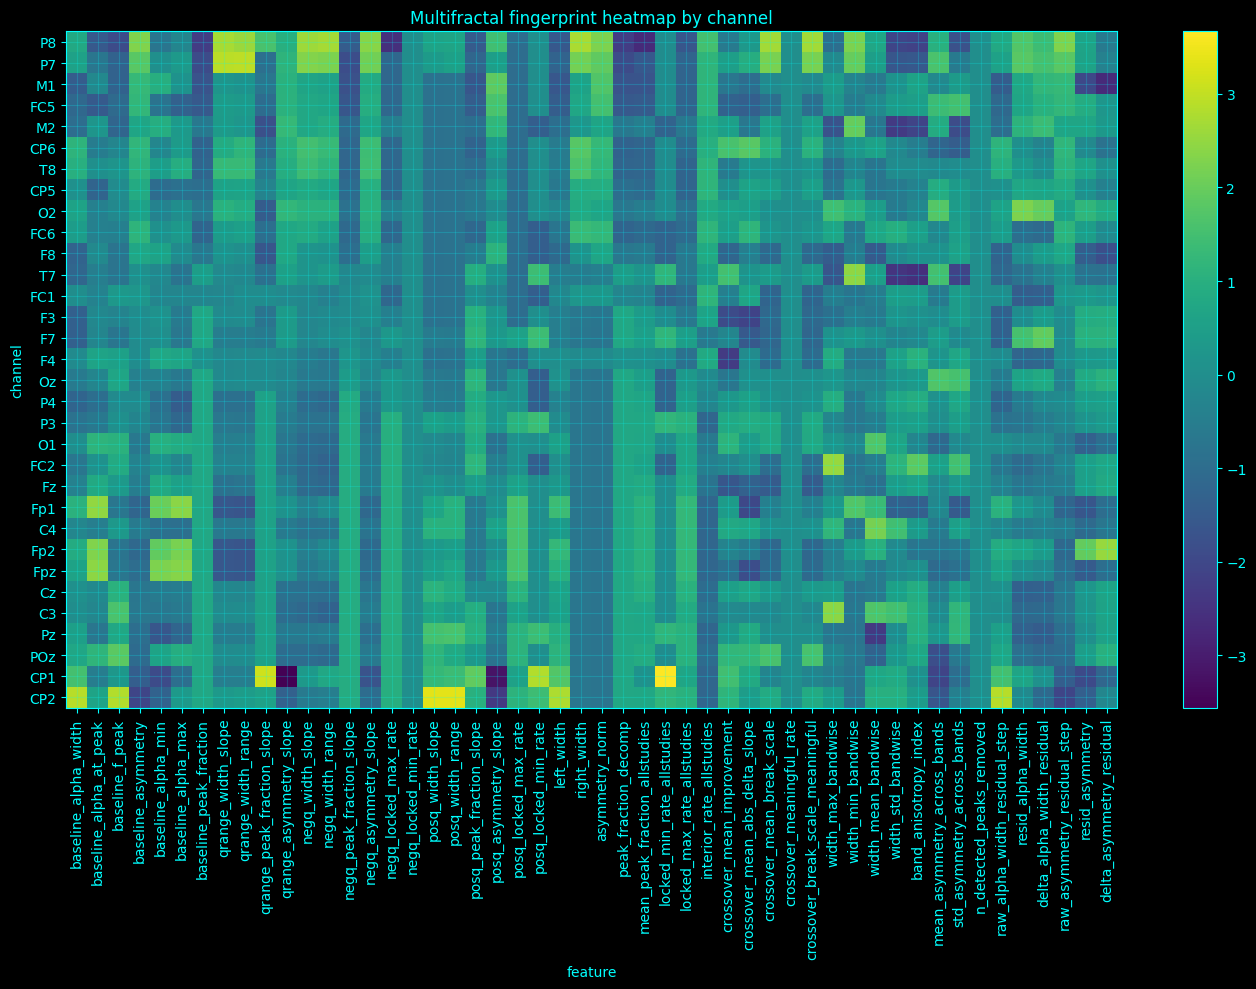

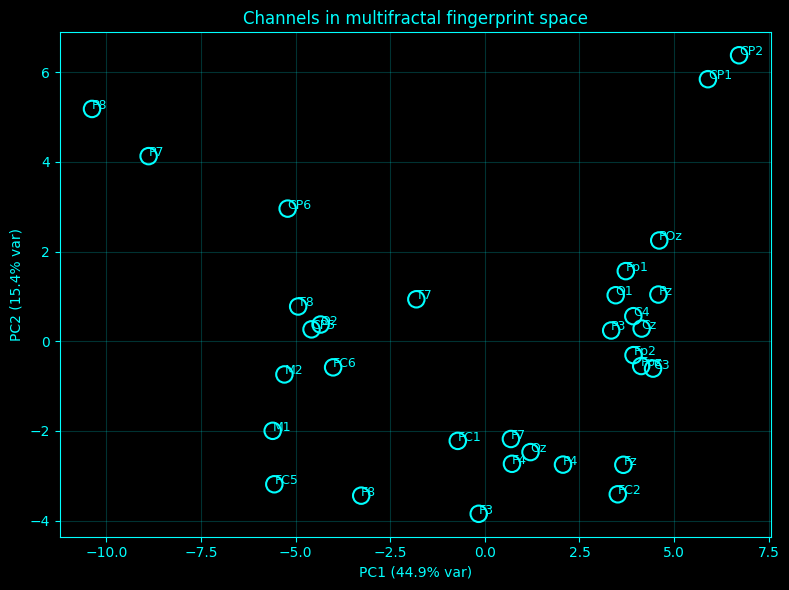

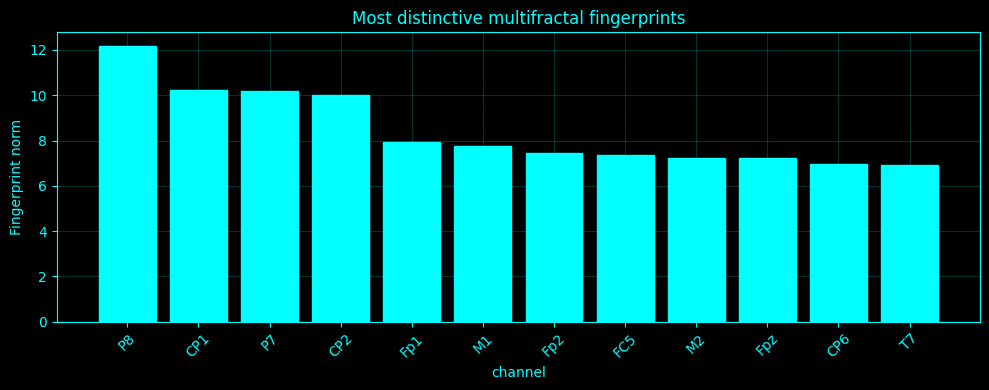


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_channel_fingerprints
Fingerprint table: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_channel_fingerprints/multifractal_channel_fingerprint_table.csv
Z-score matrix: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_channel_fingerprints/multifractal_channel_fingerprint_zscores.csv
PCA table: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_channel_fingerprints/multifractal_channel_fingerprint_pca.csv
Distinctive channels CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_channel_fingerprints/most_distinctive_channels.csv
Summary text: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_channel_fingerprints/multifractal_fingerprint_summary.txt


In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
out_dir = os.path.join(base_dir, "mfdfa_channel_fingerprints")
os.makedirs(out_dir, exist_ok=True)

paths = {
    "baseline": os.path.join(base_dir, "mfdfa_manual_spectrum_results", "mfdfa_manual_spectrum_summary.csv"),
    "qrange": os.path.join(base_dir, "mfdfa_qrange_sensitivity", "qrange_sensitivity_summary.csv"),
    "negq": os.path.join(base_dir, "mfdfa_negative_q_stability", "negative_q_stability_summary.csv"),
    "posq": os.path.join(base_dir, "mfdfa_positive_q_dominance", "positive_q_dominance_summary.csv"),
    "asym": os.path.join(base_dir, "mfdfa_asymmetry_decomposition", "asymmetry_decomposition_table.csv"),
    "peaklock": os.path.join(base_dir, "mfdfa_peak_locking_analysis", "channel_peak_lock_rates_across_studies.csv"),
    "crossover": os.path.join(base_dir, "mfdfa_crossover_detection", "crossover_detection_summary.csv"),
    "band": os.path.join(base_dir, "mfdfa_frequency_band_anisotropy", "band_anisotropy_summary.csv"),
    "residual": os.path.join(base_dir, "mfdfa_residual_after_oscillation_removal", "raw_vs_residual_mfdfa_summary.csv"),
    "cluster": os.path.join(base_dir, "mfdfa_cross_channel_clustering", "cross_channel_cluster_assignments.csv"),
}

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.20, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def load_csv_safe(path, name):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded {name}: {path}")
        return df
    print(f"Missing {name}: {path}")
    return None

def safe_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan
    coef = np.polyfit(x[mask], y[mask], 1)
    return float(coef[0])

def safe_range(y):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if len(y) == 0:
        return np.nan
    return float(np.max(y) - np.min(y))

def add_peak_metrics(df):
    df = df.copy()
    needed = {"alpha_min", "alpha_max", "alpha_at_peak"}
    if not needed.issubset(df.columns):
        return df
    width = np.maximum(df["alpha_max"] - df["alpha_min"], 1e-12)
    df["peak_fraction"] = (df["alpha_at_peak"] - df["alpha_min"]) / width
    df["peak_locked_min_tmp"] = np.isclose(df["alpha_at_peak"], df["alpha_min"])
    df["peak_locked_max_tmp"] = np.isclose(df["alpha_at_peak"], df["alpha_max"])
    return df

def zscore_matrix(X, eps=1e-12):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd)
    Z = (X - mu) / sd
    return Z, mu, sd

def fill_nan_with_col_mean(X):
    X = np.asarray(X, dtype=float)
    col_mean = np.nanmean(X, axis=0)
    inds = np.where(~np.isfinite(X))
    X2 = X.copy()
    X2[inds] = np.take(col_mean, inds[1])
    return X2

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = Xc @ Vt[:2].T
    var = (S ** 2) / max(X.shape[0] - 1, 1)
    frac = var / np.sum(var)
    return scores, frac[:2]

# -------------------------------------------------------
# LOAD DATASETS
# -------------------------------------------------------
baseline_df  = load_csv_safe(paths["baseline"],  "baseline")
qrange_df    = load_csv_safe(paths["qrange"],    "qrange")
negq_df      = load_csv_safe(paths["negq"],      "negative-q")
posq_df      = load_csv_safe(paths["posq"],      "positive-q")
asym_df      = load_csv_safe(paths["asym"],      "asymmetry")
peaklock_df  = load_csv_safe(paths["peaklock"],  "peaklock")
crossover_df = load_csv_safe(paths["crossover"], "crossover")
band_df      = load_csv_safe(paths["band"],      "band anisotropy")
residual_df  = load_csv_safe(paths["residual"],  "residual")
cluster_df   = load_csv_safe(paths["cluster"],   "cluster")

if baseline_df is not None:
    baseline_df = add_peak_metrics(baseline_df)
if qrange_df is not None:
    qrange_df = add_peak_metrics(qrange_df)
if negq_df is not None:
    negq_df = add_peak_metrics(negq_df)
if posq_df is not None:
    posq_df = add_peak_metrics(posq_df)

# -------------------------------------------------------
# BUILD FINGERPRINTS
# -------------------------------------------------------
fingerprint_rows = []

for ch in eeg_channels:
    row = {"channel": ch}

    # ---------------------------
    # BASELINE FEATURES
    # ---------------------------
    if baseline_df is not None:
        sub = baseline_df[baseline_df["channel"] == ch]
        if len(sub) > 0:
            r = sub.iloc[0]
            row["baseline_alpha_width"] = r.get("alpha_width", np.nan)
            row["baseline_alpha_at_peak"] = r.get("alpha_at_peak", np.nan)
            row["baseline_f_peak"] = r.get("f_peak", np.nan)
            row["baseline_asymmetry"] = r.get("asymmetry", np.nan)
            row["baseline_alpha_min"] = r.get("alpha_min", np.nan)
            row["baseline_alpha_max"] = r.get("alpha_max", np.nan)
            row["baseline_peak_fraction"] = r.get("peak_fraction", np.nan)
        else:
            row["baseline_alpha_width"] = np.nan
            row["baseline_alpha_at_peak"] = np.nan
            row["baseline_f_peak"] = np.nan
            row["baseline_asymmetry"] = np.nan
            row["baseline_alpha_min"] = np.nan
            row["baseline_alpha_max"] = np.nan
            row["baseline_peak_fraction"] = np.nan

    # ---------------------------
    # Q-RANGE SENSITIVITY
    # ---------------------------
    if qrange_df is not None:
        sub = qrange_df[qrange_df["channel"] == ch].sort_values("q_max")
        if len(sub) > 0:
            row["qrange_width_slope"] = safe_slope(sub["q_max"], sub["alpha_width"])
            row["qrange_width_range"] = safe_range(sub["alpha_width"])
            row["qrange_peak_fraction_slope"] = safe_slope(sub["q_max"], sub["peak_fraction"])
            row["qrange_asymmetry_slope"] = safe_slope(sub["q_max"], sub["asymmetry"])
        else:
            row["qrange_width_slope"] = np.nan
            row["qrange_width_range"] = np.nan
            row["qrange_peak_fraction_slope"] = np.nan
            row["qrange_asymmetry_slope"] = np.nan

    # ---------------------------
    # NEGATIVE-Q SENSITIVITY
    # ---------------------------
    if negq_df is not None:
        sub = negq_df[negq_df["channel"] == ch].copy()
        if len(sub) > 0:
            x = np.abs(sub["q_min"].to_numpy(dtype=float))
            row["negq_width_slope"] = safe_slope(x, sub["alpha_width"])
            row["negq_width_range"] = safe_range(sub["alpha_width"])
            row["negq_peak_fraction_slope"] = safe_slope(x, sub["peak_fraction"])
            row["negq_asymmetry_slope"] = safe_slope(x, sub["asymmetry"])
            row["negq_locked_max_rate"] = float(np.mean(sub["peak_locked_max_tmp"])) * 100.0
            row["negq_locked_min_rate"] = float(np.mean(sub["peak_locked_min_tmp"])) * 100.0
        else:
            row["negq_width_slope"] = np.nan
            row["negq_width_range"] = np.nan
            row["negq_peak_fraction_slope"] = np.nan
            row["negq_asymmetry_slope"] = np.nan
            row["negq_locked_max_rate"] = np.nan
            row["negq_locked_min_rate"] = np.nan

    # ---------------------------
    # POSITIVE-Q SENSITIVITY
    # ---------------------------
    if posq_df is not None:
        sub = posq_df[posq_df["channel"] == ch].sort_values("q_max")
        if len(sub) > 0:
            row["posq_width_slope"] = safe_slope(sub["q_max"], sub["alpha_width"])
            row["posq_width_range"] = safe_range(sub["alpha_width"])
            row["posq_peak_fraction_slope"] = safe_slope(sub["q_max"], sub["peak_fraction"])
            row["posq_asymmetry_slope"] = safe_slope(sub["q_max"], sub["asymmetry"])
            row["posq_locked_max_rate"] = float(np.mean(sub["peak_locked_max_tmp"])) * 100.0
            row["posq_locked_min_rate"] = float(np.mean(sub["peak_locked_min_tmp"])) * 100.0
        else:
            row["posq_width_slope"] = np.nan
            row["posq_width_range"] = np.nan
            row["posq_peak_fraction_slope"] = np.nan
            row["posq_asymmetry_slope"] = np.nan
            row["posq_locked_max_rate"] = np.nan
            row["posq_locked_min_rate"] = np.nan

    # ---------------------------
    # ASYMMETRY DECOMPOSITION
    # ---------------------------
    if asym_df is not None:
        sub = asym_df[asym_df["channel"] == ch]
        if len(sub) > 0:
            r = sub.iloc[0]
            row["left_width"] = r.get("left_width", np.nan)
            row["right_width"] = r.get("right_width", np.nan)
            row["asymmetry_norm"] = r.get("asymmetry_norm", np.nan)
            row["peak_fraction_decomp"] = r.get("peak_fraction", np.nan)
        else:
            row["left_width"] = np.nan
            row["right_width"] = np.nan
            row["asymmetry_norm"] = np.nan
            row["peak_fraction_decomp"] = np.nan

    # ---------------------------
    # PEAK-LOCKING SUMMARY
    # ---------------------------
    if peaklock_df is not None:
        sub = peaklock_df[peaklock_df["channel"] == ch]
        if len(sub) > 0:
            r = sub.iloc[0]
            row["mean_peak_fraction_allstudies"] = r.get("mean_peak_fraction", np.nan)
            row["locked_min_rate_allstudies"] = r.get("locked_min_rate", np.nan)
            row["locked_max_rate_allstudies"] = r.get("locked_max_rate", np.nan)
            row["interior_rate_allstudies"] = r.get("interior_rate", np.nan)
        else:
            row["mean_peak_fraction_allstudies"] = np.nan
            row["locked_min_rate_allstudies"] = np.nan
            row["locked_max_rate_allstudies"] = np.nan
            row["interior_rate_allstudies"] = np.nan

    # ---------------------------
    # CROSSOVER FEATURES
    # ---------------------------
    if crossover_df is not None:
        sub = crossover_df[crossover_df["channel"] == ch]
        if len(sub) > 0:
            row["crossover_mean_improvement"] = float(np.nanmean(sub["improvement_ratio"]))
            row["crossover_mean_abs_delta_slope"] = float(np.nanmean(sub["abs_delta_slope"]))
            row["crossover_mean_break_scale"] = float(np.nanmean(sub["break_scale_mid"]))
            row["crossover_meaningful_rate"] = float(np.mean(sub["is_meaningful"])) * 100.0

            sub_meaningful = sub[sub["is_meaningful"] == True]
            row["crossover_break_scale_meaningful"] = float(np.nanmean(sub_meaningful["break_scale_mid"])) if len(sub_meaningful) > 0 else np.nan
        else:
            row["crossover_mean_improvement"] = np.nan
            row["crossover_mean_abs_delta_slope"] = np.nan
            row["crossover_mean_break_scale"] = np.nan
            row["crossover_meaningful_rate"] = np.nan
            row["crossover_break_scale_meaningful"] = np.nan

    # ---------------------------
    # BAND ANISOTROPY
    # ---------------------------
    if band_df is not None:
        sub = band_df[band_df["channel"] == ch]
        if len(sub) > 0:
            r = sub.iloc[0]
            row["preferred_band_max_width"] = r.get("preferred_band_max_width", "")
            row["weakest_band_min_width"] = r.get("weakest_band_min_width", "")
            row["width_max_bandwise"] = r.get("width_max", np.nan)
            row["width_min_bandwise"] = r.get("width_min", np.nan)
            row["width_mean_bandwise"] = r.get("width_mean", np.nan)
            row["width_std_bandwise"] = r.get("width_std", np.nan)
            row["band_anisotropy_index"] = r.get("anisotropy_index", np.nan)
            row["mean_asymmetry_across_bands"] = r.get("mean_asymmetry_across_bands", np.nan)
            row["std_asymmetry_across_bands"] = r.get("std_asymmetry_across_bands", np.nan)
        else:
            row["preferred_band_max_width"] = ""
            row["weakest_band_min_width"] = ""
            row["width_max_bandwise"] = np.nan
            row["width_min_bandwise"] = np.nan
            row["width_mean_bandwise"] = np.nan
            row["width_std_bandwise"] = np.nan
            row["band_anisotropy_index"] = np.nan
            row["mean_asymmetry_across_bands"] = np.nan
            row["std_asymmetry_across_bands"] = np.nan

    # ---------------------------
    # RESIDUAL-MFDFA
    # ---------------------------
    if residual_df is not None:
        sub = residual_df[residual_df["channel"] == ch]
        if len(sub) > 0:
            r = sub.iloc[0]
            row["n_detected_peaks_removed"] = r.get("n_detected_peaks", np.nan)
            row["raw_alpha_width_residual_step"] = r.get("raw_alpha_width", np.nan)
            row["resid_alpha_width"] = r.get("resid_alpha_width", np.nan)
            row["delta_alpha_width_residual"] = r.get("delta_alpha_width", np.nan)
            row["raw_asymmetry_residual_step"] = r.get("raw_asymmetry", np.nan)
            row["resid_asymmetry"] = r.get("resid_asymmetry", np.nan)
            row["delta_asymmetry_residual"] = r.get("delta_asymmetry", np.nan)
        else:
            row["n_detected_peaks_removed"] = np.nan
            row["raw_alpha_width_residual_step"] = np.nan
            row["resid_alpha_width"] = np.nan
            row["delta_alpha_width_residual"] = np.nan
            row["raw_asymmetry_residual_step"] = np.nan
            row["resid_asymmetry"] = np.nan
            row["delta_asymmetry_residual"] = np.nan

    # ---------------------------
    # OPTIONAL CLUSTER LABEL
    # ---------------------------
    if cluster_df is not None:
        sub = cluster_df[cluster_df["channel"] == ch]
        if len(sub) > 0:
            row["cluster"] = sub.iloc[0].get("cluster", np.nan)
        else:
            row["cluster"] = np.nan

    fingerprint_rows.append(row)

fingerprint_df = pd.DataFrame(fingerprint_rows)

# -------------------------------------------------------
# SAVE RAW FINGERPRINT TABLE
# -------------------------------------------------------
fingerprint_csv = os.path.join(out_dir, "multifractal_channel_fingerprint_table.csv")
fingerprint_df.to_csv(fingerprint_csv, index=False)

print("\nFingerprint table:")
print(fingerprint_df)

# -------------------------------------------------------
# NUMERIC FEATURE MATRIX
# -------------------------------------------------------
non_numeric_keep = ["channel", "preferred_band_max_width", "weakest_band_min_width", "cluster"]
numeric_cols = [c for c in fingerprint_df.columns if c not in non_numeric_keep]

X = fingerprint_df[numeric_cols].to_numpy(dtype=float)
Z, mu, sd = zscore_matrix(X)
Z_filled = fill_nan_with_col_mean(Z)

z_df = pd.DataFrame(Z, columns=numeric_cols)
z_df.insert(0, "channel", fingerprint_df["channel"])
z_csv = os.path.join(out_dir, "multifractal_channel_fingerprint_zscores.csv")
z_df.to_csv(z_csv, index=False)

# -------------------------------------------------------
# PCA OF FINGERPRINT SPACE
# -------------------------------------------------------
scores, explained = pca_2d(Z_filled)
fingerprint_df["pc1"] = scores[:, 0]
fingerprint_df["pc2"] = scores[:, 1]

pca_csv = os.path.join(out_dir, "multifractal_channel_fingerprint_pca.csv")
fingerprint_df.to_csv(pca_csv, index=False)

# Distinctiveness score = norm of z-scored fingerprint
fingerprint_df["fingerprint_norm"] = np.linalg.norm(Z_filled, axis=1)

distinctive_df = fingerprint_df.sort_values("fingerprint_norm", ascending=False)[
    ["channel", "fingerprint_norm"]
]
distinctive_csv = os.path.join(out_dir, "most_distinctive_channels.csv")
distinctive_df.to_csv(distinctive_csv, index=False)

# -------------------------------------------------------
# SORT CHANNELS FOR VISUALIZATION
# -------------------------------------------------------
sort_idx = np.argsort(fingerprint_df["pc1"].to_numpy())
fingerprint_df_sorted = fingerprint_df.iloc[sort_idx].reset_index(drop=True)
Z_sorted = Z_filled[sort_idx, :]

# -------------------------------------------------------
# PLOT 1: FINGERPRINT HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(Z_sorted, aspect="auto")
ax.set_title("Multifractal fingerprint heatmap by channel")
ax.set_xlabel("feature")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(fingerprint_df_sorted)))
ax.set_yticklabels(fingerprint_df_sorted["channel"], color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

heatmap_path = os.path.join(out_dir, "multifractal_fingerprint_heatmap.png")
plt.tight_layout()
plt.savefig(heatmap_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: PCA MAP OF CHANNELS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.scatter(
    fingerprint_df["pc1"],
    fingerprint_df["pc2"],
    s=140,
    facecolors="none",
    edgecolors=ACCENT,
    linewidths=1.5
)

for _, row in fingerprint_df.iterrows():
    ax.text(row["pc1"], row["pc2"], row["channel"], fontsize=9, color=ACCENT)

ax.set_title("Channels in multifractal fingerprint space")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")

pca_path = os.path.join(out_dir, "multifractal_fingerprint_pca.png")
plt.tight_layout()
plt.savefig(pca_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: MOST DISTINCTIVE CHANNELS
# -------------------------------------------------------
top_df = distinctive_df.head(12)

fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    top_df["channel"],
    top_df["fingerprint_norm"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Most distinctive multifractal fingerprints")
ax.set_xlabel("channel")
ax.set_ylabel("Fingerprint norm")
ax.tick_params(axis='x', rotation=45)

distinctive_path = os.path.join(out_dir, "most_distinctive_channels.png")
plt.tight_layout()
plt.savefig(distinctive_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "multifractal_fingerprint_summary.txt")
with open(txt_path, "w") as f:
    f.write("Multifractal fingerprint per channel\n")
    f.write("===================================\n\n")
    f.write(f"Number of channels: {len(fingerprint_df)}\n")
    f.write(f"Number of numeric fingerprint features: {len(numeric_cols)}\n")
    f.write(f"Explained variance PC1: {explained[0]:.6f}\n")
    f.write(f"Explained variance PC2: {explained[1]:.6f}\n\n")

    f.write("Top distinctive channels:\n")
    for _, row in top_df.iterrows():
        f.write(f"{row['channel']}: {row['fingerprint_norm']:.6f}\n")

print(f"\nSaved outputs to: {out_dir}")
print(f"Fingerprint table: {fingerprint_csv}")
print(f"Z-score matrix: {z_csv}")
print(f"PCA table: {pca_csv}")
print(f"Distinctive channels CSV: {distinctive_csv}")
print(f"Summary text: {txt_path}")